# Unified CKII Place-Cell Pipeline

Single entrypoint notebook to:
1. Validate/rebuild per-animal cached analysis artifacts.
2. Run pooled CKII figures with unchanged style (using `PooledFigure_CKII_Stats_V2.ipynb` execution).

In [429]:
%load_ext autoreload
%autoreload 2


force_recompute = False  # Set to True to force recomputation of all results, even if cached results are available

import os
import sys
import json
from pathlib import Path

current_dir = Path(os.getcwd()).resolve()
parent_dir = current_dir.parent
if str(parent_dir) not in sys.path:
    sys.path.insert(0, str(parent_dir))

import matplotlib.pyplot as plt
plt.rcParams["svg.fonttype"] = "none"
plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 6,
    "axes.labelsize": 6,
    "axes.titlesize": 6,
    "xtick.labelsize": 5,
    "ytick.labelsize": 5,
    "xtick.major.size": 1.75,
    "ytick.major.size": 1.75,
    "xtick.minor.size": 1.0,
    "ytick.minor.size": 1.0,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "legend.fontsize": 5,
    "axes.linewidth": 0.5,
})

from utils.placecell_pipeline import (
    AnalysisParams,
    PlaceCellParams,
    PFTraversalParams,
    PFDistanceCenteredParams,
    PooledParams,
    CachePolicy,
    PipelineConfig,
    ensure_cache_for_all_animals,
    summarize_statuses,
    summarize_snr_removed_frames,
    generate_trial_by_trial_plc_plots,
    generate_distance_defined_trial_by_trial_plc_plots,
    generate_distance_defined_trials_and_dataset,
    build_pf_centered_component_dataset,
    build_pf_distance_centered_component_dataset,
    generate_pf_centered_component_heatmaps,
    generate_pf_distance_centered_component_heatmaps,
    generate_pf_distance_centered_component_heatmaps_2sessions,
    generate_pf_distance_centered_component_heatmaps_2directions,
    plot_pf_centered_category_primary_secondary_from_dataset,
    plot_pf_distance_centered_category_primary_secondary_from_dataset,
    plot_pf_distance_centered_category_primary_secondary_from_dataset_2sessions,
    plot_pf_distance_centered_category_primary_secondary_from_dataset_2directions,
    compute_pf_distance_centered_pref_nonpref_stats,
    plot_pf_distance_centered_pref_nonpref_stats,
    compute_pf_centered_selectivity_summary,
    plot_pf_centered_selectivity_summary,
    compute_csplus_two_pf_session_delta,
    plot_csplus_two_pf_session_delta,
    compute_csplus_vs_csminus_primary_pf_session_delta,
    plot_csplus_vs_csminus_primary_pf_session_delta,
    compute_pf_distance_centered_session_stability,
    plot_pf_distance_centered_session_stability,
    GLMParams,
    run_pooled_placecell_glm_analysis,
    LNModelParams,
    run_pooled_placecell_ln_model_analysis,
    generate_bin_by_bin_directionality_plots,
    EgocentricTuningParams,
    EgocentricSummaryPlotParams,
    run_pooled_egocentric_tuning_analysis,
    generate_egocentric_valid_spatial_bin_diagnostic_plots,
    generate_egocentric_per_cell_summary_plots,
)

from utils.spatial_heatmaps import (
    classify_spatial_cells,
    compute_global_theta_slow_vlims,
    plot_celltype_distribution_pie,
    plot_selected_cells_figure,
    render_spatial_heatmap_chunks,
)

from utils.pooled_figures_core import (
    prepare_pooled_stats_tables,
    plot_combined_cs_plus_minus_4panels,
    plot_cs_plus_plc_correlations_overlay_cs_ss,
    plot_complex_burst_metrics_allbursts_csplus,
    plot_complex_burst_metrics_csplus,
    plot_cbrate_correlations_csplus_inout_alt,
    plot_theta_inout_loco_csplus_vs_csminus,
    plot_slow_vm_inout_loco_csplus_vs_csminus,
)

from utils.session_compare_heatmaps import (
    SessionCompareParams,
    build_session_compare_payloads,
    assemble_session_compare_groups,
    render_session_compare_heatmaps,
    run_session_compare_heatmaps,
)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Parameter Blocks

In [430]:
# Ensure latest pipeline dataclasses are bound in this kernel
import importlib
import utils.placecell_pipeline as _pcp
importlib.reload(_pcp)
AnalysisParams = _pcp.AnalysisParams
PlaceCellParams = _pcp.PlaceCellParams
PFTraversalParams = _pcp.PFTraversalParams
PFDistanceCenteredParams = _pcp.PFDistanceCenteredParams
PooledParams = _pcp.PooledParams
CachePolicy = _pcp.CachePolicy
PipelineConfig = _pcp.PipelineConfig
print(f"Using placecell_pipeline: {_pcp.__file__}")

# Block 1: Dataset and paths
project_root = parent_dir

data_root = project_root / 'data'
figures_root = project_root / 'figures'
notebooks_root = project_root / 'notebooks_PCs'

animals = [
    'CKII_pAce21_PR_20250806',
    'CKII_pAce38_PX_20251126',
    'CKII_pAce45_PX_20260118',
    'CKII_pAce47_PX_20260128',
    'CKII_pAce46_PR_20260222',
    'CKII_pAce50_PRL_20260317',
]

# Block 2: Core analysis parameters
analysis_params = AnalysisParams(
    speed_threshold=3.,
    speed_threshold_quiet=0.5,
    min_duration_s=0.25, # minimum duration of a candidate event (in seconds), default 0.25s
    merge_gap_s=0.0, 
    kernel_size=51,
    snr_threshold=3.0,
    min_good_minutes=5.0, # only include cells with 
    theta_freqs=(4.0, 8.0),
    slow_freqs=2.0,
)

# Block 3: Place cell + traversal parameters
place_cell_params = PlaceCellParams(
    bin_size=1.5, # default 1.5 cm
    place_field_threshold=0.35, # Threshold for place field detection relative to maximum peak rate, default 0.4
    min_component_peak_ratio=0.45, # each PF component peak must be at least this fraction of the map max peak
    split_multi_peak_fields=True, # enable peak-based PF splitting using the criteria below
    split_secondary_peak_ratio=0.6, # split a PF if a secondary local peak is at least this fraction of the primary peak
    split_secondary_peak_min_separation_cm=6.0, # split only if primary and secondary peaks are at least this far apart
    min_peak_rate=0.5, # Minimum peak firing rate (in Hz) for a valid place field, default 0.4
    max_field_area_ratio=0.5, 
    min_field_bins=10, # Minimum number of contiguous bins for a valid place field, default 10
    min_pf_reliability=0.2, # percentage of traversals in which there is spike firing in the place field, default 0.20 
    min_pf_traversals=5,
    pf_reliability_dilation_bins=3, # Dilation size in bins for place field reliability calculation, default 3 (to prevent small PF being rejected)
    pf_reliability_dilation_shape='disk',
    smooth_sigma=1.5, # for smoothing spatial firing rate maps (in bins), default 2.0
    min_occupancy_s=0.001,
    occ_smooth_sigma=1.5, # for smoothing occupancy maps (in bins), default 2.0
    num_shuffles=1000,
    random_seed=42,
    ss_shape_min_separation_ms=14.0,
    trim_sparse_top_row_for_analysis=True, 
    trim_sparse_top_row_for_plotting=True,
    sparse_top_row_nonocc_frac_threshold=0.8,
)

traversal_params = PFTraversalParams(
    center_by_pf_position=True,
    pf_component_selection='peak_rate',
    min_duration_ms=100.0,
    min_distance_cm=5.0,
    traversal_merge_gap_s=2.0, # merge nearby PF traversals separated by brief rest
    clear_traversal=False,
    session_indices=(0, 1),
    pf_center_window_sec=10.0, # seconds before and after PF entry and exit to include in PF-centered traversal analysis
    min_traversals=10,
    firing_rate_bin_ms=100.0,
    firing_rate_smooth_ms=50.0,
    subtract_pre_traversal_baseline=False, # subtract pre-traversal baseline from theta amp and slow Vm
    mask_non_traversal_pf=True, 
    max_pf_distance_cm=8.0, # maximum allowed distance between a traversal and the PF peak
    plateau_min_duration_ms=100.0,
)

# Block 4: Pooled classification + PSD parameters
pooled_params = PooledParams(
    cb_num_threshold=5, # minimum number of complex bursts in PF required for classification as CS+ place cell
    cs_peak_rate_threshold=0.5, # CS+ also requires CS spatial-map peak firing rate > this threshold (Hz)
    run_psd_sections=True,
    cs_plc_only=True,
    psd_speed_threshold=3,
    psd_chunk_s=2.0,
    psd_nperseg_s=1.0,
    psd_noverlap_frac=0.5,
    simple_event_window_ms=80.0,
    simple_event_min_gap_ms=50.0,
    min_chunk_valid_fraction=1.0,
    max_freq=100.0,
    normalize_psd=True,
    norm_freq_range=(20.0, 100.0),
)

# Block 5: Figure style
# (Style remains the same because pooled figure generation executes
#  PooledFigure_CKII_Stats_V2.ipynb with patched parameters only.)

# Block 6: Cache policy controls
cache_policy = CachePolicy(
    force_recompute=force_recompute,
    validate_only=False,
    save_executed_notebooks=False,
)

config = PipelineConfig(
    project_root=project_root,
    data_root=data_root,
    figures_root=figures_root,
    notebooks_root=notebooks_root,
    animals=animals,
    analysis=analysis_params,
    place_cell=place_cell_params,
    traversal=traversal_params,
    pooled=pooled_params,
    cache=cache_policy,
)

print('Pipeline Config:')
print(json.dumps({
    'project_root': str(config.project_root),
    'data_root': str(config.data_root),
    'figures_root': str(config.figures_root),
    'notebooks_root': str(config.notebooks_root),
    'animals': config.animals,
    'analysis': config.analysis.__dict__,
    'place_cell': config.place_cell.__dict__,
    'traversal': config.traversal.__dict__,
    'pooled': config.pooled.__dict__,
    'cache': config.cache.__dict__,
}, indent=2))


Using placecell_pipeline: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/utils/placecell_pipeline.py
Pipeline Config:
{
  "project_root": "/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4",
  "data_root": "/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/data",
  "figures_root": "/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures",
  "notebooks_root": "/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/notebooks_PCs",
  "animals": [
    "CKII_pAce21_PR_20250806",
    "CKII_pAce38_PX_20251126",
    "CKII_pAce45_PX_20260118",
    "CKII_pAce47_PX_20260128",
    "CKII_pAce46_PR_20260222",
    "CKII_pAce50_PRL_20260317"
  ],
  "analysis": {
    "speed_threshold": 3.0,
    "speed_threshold_quiet": 0.5,
    "min_duration_s": 0.25,
    "merge_gap_s": 0.0,
    "kernel_size": 51,
    "snr_threshold": 3.

In [362]:
# Ensure/rebuild per-animal cache artifacts
statuses = ensure_cache_for_all_animals(config, force=config.cache.force_recompute)

for st in statuses:
    print(f"[{st.action}] {st.animal_id}")
    if st.reasons:
        print(f"  reasons: {st.reasons}")
    if st.missing_artifacts:
        print(f"  missing: {st.missing_artifacts}")

print('Summary:', summarize_statuses(statuses))


CKII_pAce21_PR_20250806: SNR filter kept 9/9 cells (threshold=3.0, min_good_minutes=5.0).
Found 19 traversal epochs (min duration: 100.0 ms, min distance: 5.0 cm, max PF distance: 8.0 cm)
Place field has 49 bins, peak rate: 8.89 Hz


/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/utils/placecell_pipeline.py:3533: RuntimeWarning: invalid value encountered in divide
  overlap_end = min(pe + 1, end_idx)
/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/utils/placecell_pipeline.py:3534: RuntimeWarning: invalid value encountered in divide
  if overlap_start < overlap_end:
/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/utils/placecell_pipeline.py:3616: RuntimeWarning: Mean of empty slice
  firing_rate_smooth_ms: float,
/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/utils/placecell_pipeline.py:3617: RuntimeWarning: Mean of empty slice
  ) -> np.ndarray | None:


Found 26 traversal epochs (min duration: 100.0 ms, min distance: 5.0 cm, max PF distance: 8.0 cm)
Place field has 49 bins, peak rate: 6.01 Hz
Found 7 traversal epochs (min duration: 100.0 ms, min distance: 5.0 cm, max PF distance: 8.0 cm)
Place field has 44 bins, peak rate: 3.28 Hz
CKII_pAce38_PX_20251126: SNR filter kept 9/9 cells (threshold=3.0, min_good_minutes=5.0).
Found 43 traversal epochs (min duration: 100.0 ms, min distance: 5.0 cm, max PF distance: 8.0 cm)
Place field has 80 bins, peak rate: 8.83 Hz


/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/utils/placecell_pipeline.py:3533: RuntimeWarning: invalid value encountered in divide
  overlap_end = min(pe + 1, end_idx)
/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/utils/placecell_pipeline.py:3534: RuntimeWarning: invalid value encountered in divide
  if overlap_start < overlap_end:
/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/utils/placecell_pipeline.py:3616: RuntimeWarning: Mean of empty slice
  firing_rate_smooth_ms: float,
/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/utils/placecell_pipeline.py:3617: RuntimeWarning: Mean of empty slice
  ) -> np.ndarray | None:


Found 36 traversal epochs (min duration: 100.0 ms, min distance: 5.0 cm, max PF distance: 8.0 cm)
Place field has 35 bins, peak rate: 7.09 Hz
Found 63 traversal epochs (min duration: 100.0 ms, min distance: 5.0 cm, max PF distance: 8.0 cm)
Place field has 48 bins, peak rate: 1.66 Hz
Found 57 traversal epochs (min duration: 100.0 ms, min distance: 5.0 cm, max PF distance: 8.0 cm)
Place field has 61 bins, peak rate: 7.77 Hz
Found 52 traversal epochs (min duration: 100.0 ms, min distance: 5.0 cm, max PF distance: 8.0 cm)
Place field has 36 bins, peak rate: 7.01 Hz
Found 83 traversal epochs (min duration: 100.0 ms, min distance: 5.0 cm, max PF distance: 8.0 cm)
Place field has 143 bins, peak rate: 1.15 Hz
CKII_pAce45_PX_20260118: SNR filter kept 15/16 cells (threshold=3.0, min_good_minutes=5.0).
Found 50 traversal epochs (min duration: 100.0 ms, min distance: 5.0 cm, max PF distance: 8.0 cm)
Place field has 113 bins, peak rate: 2.93 Hz


...

Found 85 traversal epochs (min duration: 100.0 ms, min distance: 5.0 cm, max PF distance: 8.0 cm)
Place field has 55 bins, peak rate: 7.47 Hz
Found 48 traversal epochs (min duration: 100.0 ms, min distance: 5.0 cm, max PF distance: 8.0 cm)
Place field has 44 bins, peak rate: 4.33 Hz
Found 36 traversal epochs (min duration: 100.0 ms, min distance: 5.0 cm, max PF distance: 8.0 cm)
Place field has 31 bins, peak rate: 1.82 Hz
Found 43 traversal epochs (min duration: 100.0 ms, min distance: 5.0 cm, max PF distance: 8.0 cm)
Place field has 99 bins, peak rate: 0.63 Hz
Found 89 traversal epochs (min duration: 100.0 ms, min distance: 5.0 cm, max PF distance: 8.0 cm)
Place field has 70 bins, peak rate: 2.83 Hz
CKII_pAce47_PX_20260128: SNR filter kept 5/5 cells (threshold=3.0, min_good_minutes=5.0).
Found 41 traversal epochs (min duration: 100.0 ms, min distance: 5.0 cm, max PF distance: 8.0 cm)
Place field has 32 bins, peak rate: 12.35 Hz


/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/utils/placecell_pipeline.py:3533: RuntimeWarning: invalid value encountered in divide
  overlap_end = min(pe + 1, end_idx)
/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/utils/placecell_pipeline.py:3534: RuntimeWarning: invalid value encountered in divide
  if overlap_start < overlap_end:
/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/utils/placecell_pipeline.py:3616: RuntimeWarning: Mean of empty slice
  firing_rate_smooth_ms: float,
/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/utils/placecell_pipeline.py:3617: RuntimeWarning: Mean of empty slice
  ) -> np.ndarray | None:


Found 43 traversal epochs (min duration: 100.0 ms, min distance: 5.0 cm, max PF distance: 8.0 cm)
Place field has 108 bins, peak rate: 4.94 Hz
Found 29 traversal epochs (min duration: 100.0 ms, min distance: 5.0 cm, max PF distance: 8.0 cm)
Place field has 31 bins, peak rate: 8.10 Hz
CKII_pAce46_PR_20260222: SNR filter kept 9/9 cells (threshold=3.0, min_good_minutes=5.0).
CKII_pAce50_PRL_20260317: SNR filter kept 9/9 cells (threshold=3.0, min_good_minutes=5.0).
Found 14 traversal epochs (min duration: 100.0 ms, min distance: 5.0 cm, max PF distance: 8.0 cm)
Place field has 46 bins, peak rate: 2.70 Hz


/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/utils/placecell_pipeline.py:3533: RuntimeWarning: invalid value encountered in divide
  overlap_end = min(pe + 1, end_idx)
/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/utils/placecell_pipeline.py:3534: RuntimeWarning: invalid value encountered in divide
  if overlap_start < overlap_end:
/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/utils/placecell_pipeline.py:3616: RuntimeWarning: Mean of empty slice
  firing_rate_smooth_ms: float,
/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/utils/placecell_pipeline.py:3617: RuntimeWarning: Mean of empty slice
  ) -> np.ndarray | None:


Found 17 traversal epochs (min duration: 100.0 ms, min distance: 5.0 cm, max PF distance: 8.0 cm)
Place field has 51 bins, peak rate: 3.19 Hz
[recomputed] CKII_pAce21_PR_20250806
  reasons: ['fingerprint_mismatch']
[recomputed] CKII_pAce38_PX_20251126
  reasons: ['fingerprint_mismatch']
[recomputed] CKII_pAce45_PX_20260118
  reasons: ['fingerprint_mismatch']
[recomputed] CKII_pAce47_PX_20260128
  reasons: ['fingerprint_mismatch']
[recomputed] CKII_pAce46_PR_20260222
  reasons: ['fingerprint_mismatch']
[recomputed] CKII_pAce50_PRL_20260317
  reasons: ['fingerprint_mismatch']
Summary: {'recomputed': 6, 'reused': 0, 'needs_recompute': 0}


## Pooled Figures (Run Individually)

### SNR Frame-Removal Distribution

SNR removed-frame summary (all cells): n_cells=57, removed(<5.0 min good)=1, mean=5.01%, median=0.00%


/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/utils/placecell_pipeline.py:2863: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  plot_series.append(removed_pct)


,scope,n_cells,n_kept_cells,n_removed_min_good_minutes,mean_pct_removed_snr_only,median_pct_removed_snr_only,std_pct_removed_snr_only,min_pct_removed_snr_only,max_pct_removed_snr_only
0,all_cells_including_removed,57,56,1,5.00544,0.0,18.239498,0.0,100.0


,animal_id,n_cells,n_kept_cells,n_removed_min_good_minutes,mean_pct_removed_snr_only,median_pct_removed_snr_only,std_pct_removed_snr_only,min_pct_removed_snr_only,max_pct_removed_snr_only
0,CKII_pAce21_PR_20250806,9.0,9.0,0.0,0.000000,0.0,0.000000,0.0,0.000000
1,CKII_pAce38_PX_20251126,9.0,9.0,0.0,0.000000,0.0,0.000000,0.0,0.000000
2,CKII_pAce45_PX_20260118,16.0,15.0,1.0,6.250000,0.0,24.206146,0.0,100.000000
3,CKII_pAce46_PR_20260222,9.0,9.0,0.0,14.009475,0.0,23.844073,0.0,70.982610
4,CKII_pAce47_PX_20260128,5.0,5.0,0.0,0.000000,0.0,0.000000,0.0,0.000000
5,CKII_pAce50_PRL_20260317,9.0,9.0,0.0,6.580532,0.0,18.612555,0.0,59.224787


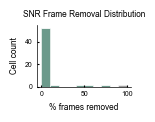

In [363]:
snr_dist_scope_place_cells_only = False

snr_dist = summarize_snr_removed_frames(
    config=config,
    by_place_cells_only=snr_dist_scope_place_cells_only,
    show_plot=True,
    bins=10,
)

display(snr_dist["overall"])
display(snr_dist["per_animal"])


### Spatial Heatmap Prep (Direct Core Functions)

In [364]:
figure_save_folder = os.path.join(str(config.figures_root), 'CKII_pooled')
os.makedirs(figure_save_folder, exist_ok=True)

spatial_data = classify_spatial_cells(
    data_folder=str(config.data_root),
    folders=config.animals,
    cb_num_threshold=config.pooled.cb_num_threshold,
    cs_peak_rate_threshold=config.pooled.cs_peak_rate_threshold,
    snr_threshold=config.analysis.snr_threshold,
)

all_cells_for_vlim = spatial_data.plcs_csplus + spatial_data.plcs_csminus + spatial_data.non_plcs
global_theta_vlim, global_slow_vlim = compute_global_theta_slow_vlims(all_cells_for_vlim)

# Keep style/limits consistent with your current pooled notebook
selected_theta_vlim = [0, 0.2] if global_theta_vlim is not None else None
selected_slow_vlim = [-0.15, 0.15] if global_slow_vlim is not None else None

print(f"CS+ PLCs: {len(spatial_data.plcs_csplus)}")
print(f"CS- PLCs: {len(spatial_data.plcs_csminus)}")
print(f"Non-PLCs: {len(spatial_data.non_plcs)}")
print(f"theta vlim (global): {global_theta_vlim}; using: {selected_theta_vlim}")
print(f"slow vlim (global): {global_slow_vlim}; using: {selected_slow_vlim}")


Loaded 9 cells from CKII_pAce21_PR_20250806
Loaded 9 cells from CKII_pAce38_PX_20251126
Loaded 15 cells from CKII_pAce45_PX_20260118
Loaded 5 cells from CKII_pAce47_PX_20260128
Loaded 9 cells from CKII_pAce46_PR_20260222
Loaded 9 cells from CKII_pAce50_PRL_20260317

Total: 56 cells loaded
CS+ PLCs: 12
CS- PLCs: 8
Non-PLCs: 36
theta vlim (global): (np.float64(0.03336107877369013), np.float64(0.19098845673185152)); using: [0, 0.2]
slow vlim (global): (np.float64(-0.28706341653888867), np.float64(0.28706341653888867)); using: [-0.15, 0.15]


### CellType_Distribution_PieChart

Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/CellType_Distribution_PieChart.svg


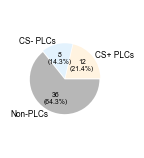

In [365]:
pie_path = os.path.join(figure_save_folder, 'CellType_Distribution_PieChart.svg')

plot_celltype_distribution_pie(
    spatial_data.plcs_csplus,
    spatial_data.plcs_csminus,
    spatial_data.non_plcs,
    save_path=pie_path,
)

print(f'Saved: {pie_path}')


### SpatialHeatmaps_All_PLCs_CSplus_then_CSminus_Combined

pAce21 Cell 3: removed_snr=0/299500 (0.00%), removed_total=0/299500 (0.00%)
pAce38 Cell 1: removed_snr=0/597670 (0.00%), removed_total=62/597670 (0.01%)
pAce38 Cell 4: removed_snr=0/597670 (0.00%), removed_total=62/597670 (0.01%)
pAce38 Cell 6: removed_snr=0/597670 (0.00%), removed_total=62/597670 (0.01%)
pAce38 Cell 7: removed_snr=0/597670 (0.00%), removed_total=62/597670 (0.01%)
pAce45 Cell 5: removed_snr=0/598609 (0.00%), removed_total=0/598609 (0.00%)
pAce45 Cell 12: removed_snr=0/598609 (0.00%), removed_total=0/598609 (0.00%)
pAce47 Cell 1: removed_snr=0/598461 (0.00%), removed_total=0/598461 (0.00%)
pAce47 Cell 3: removed_snr=0/598461 (0.00%), removed_total=0/598461 (0.00%)
pAce47 Cell 4: removed_snr=0/598461 (0.00%), removed_total=0/598461 (0.00%)
pAce50 Cell 3: removed_snr=0/599087 (0.00%), removed_total=0/599087 (0.00%)
pAce50 Cell 9: removed_snr=0/599087 (0.00%), removed_total=0/599087 (0.00%)
pAce21 Cell 1: removed_snr=0/299500 (0.00%), removed_total=0/299500 (0.00%)
pAce21 

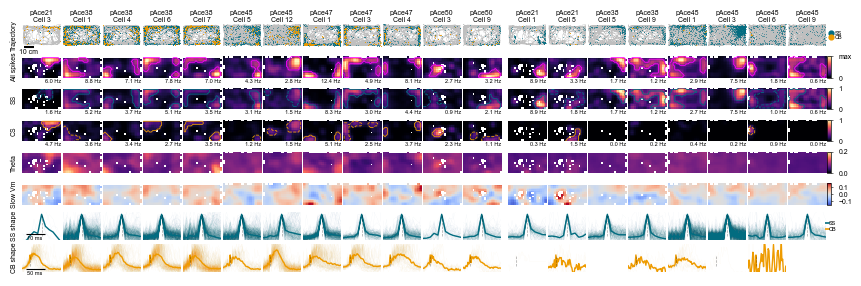

Generated: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/SpatialHeatmaps_All_PLCs_CSplus_then_CSminus_Combined.svg


In [366]:
csplus_all = list(spatial_data.plcs_csplus)
csminus_all = list(spatial_data.plcs_csminus)

out_path = os.path.join(figure_save_folder, "SpatialHeatmaps_All_PLCs_CSplus_then_CSminus_Combined.svg")
plot_selected_cells_figure(
    cell_groups=[csplus_all, csminus_all],
    group_names=['CS+ PLC', 'CS- PLC'],
    subplot_width=0.4,
    theta_vlim=selected_theta_vlim,
    slow_vlim=selected_slow_vlim,
    save_path=out_path,
    plot_putative_PF=True,
    show_place_cell_star=False,
    show_significance_marker=False,
    shape_ylim=(-0.5, 2.0),
)
print(f"Generated: {out_path}")


### SpatialHeatmaps_All_NonPLCs (may generate multiple part files)

Rendering SpatialHeatmaps_All_NonPLCs_part01.svg: cells=10
pAce21 Cell 2: removed_snr=0/299500 (0.00%), removed_total=0/299500 (0.00%)
pAce21 Cell 4: removed_snr=0/299500 (0.00%), removed_total=0/299500 (0.00%)
pAce21 Cell 4: CS PF mask is empty
pAce21 Cell 6: removed_snr=0/299500 (0.00%), removed_total=0/299500 (0.00%)
pAce21 Cell 6: All spikes PF mask is empty
pAce21 Cell 7: removed_snr=0/299500 (0.00%), removed_total=0/299500 (0.00%)
pAce21 Cell 7: SS PF mask is empty
pAce21 Cell 8: removed_snr=0/299500 (0.00%), removed_total=0/299500 (0.00%)
pAce21 Cell 8: CS PF mask is empty
pAce21 Cell 9: removed_snr=0/299500 (0.00%), removed_total=0/299500 (0.00%)
pAce38 Cell 2: removed_snr=0/597670 (0.00%), removed_total=62/597670 (0.01%)
pAce38 Cell 2: CS PF mask is empty
pAce38 Cell 3: removed_snr=0/597670 (0.00%), removed_total=62/597670 (0.01%)
pAce38 Cell 3: CS PF mask is empty
pAce38 Cell 8: removed_snr=0/597670 (0.00%), removed_total=62/597670 (0.01%)
pAce38 Cell 8: CS PF mask is empty
p

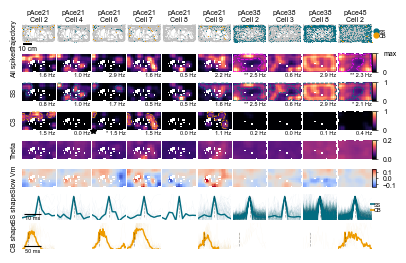

Rendering SpatialHeatmaps_All_NonPLCs_part02.svg: cells=10
pAce45 Cell 7: removed_snr=0/598609 (0.00%), removed_total=0/598609 (0.00%)
pAce45 Cell 7: CS PF mask is empty
pAce45 Cell 8: removed_snr=0/598609 (0.00%), removed_total=0/598609 (0.00%)
pAce45 Cell 8: All spikes PF mask is empty
pAce45 Cell 8: SS PF mask is empty
pAce45 Cell 8: CS PF mask is empty
pAce45 Cell 10: removed_snr=0/598609 (0.00%), removed_total=0/598609 (0.00%)
pAce45 Cell 10: CS PF mask is empty
pAce45 Cell 11: removed_snr=0/598609 (0.00%), removed_total=0/598609 (0.00%)
pAce45 Cell 11: All spikes PF mask is empty
pAce45 Cell 11: SS PF mask is empty
pAce45 Cell 11: CS PF mask is empty
pAce45 Cell 13: removed_snr=0/598609 (0.00%), removed_total=0/598609 (0.00%)
pAce45 Cell 13: CS PF mask is empty
pAce45 Cell 14: removed_snr=0/598609 (0.00%), removed_total=0/598609 (0.00%)
pAce45 Cell 14: All spikes PF mask is empty
pAce45 Cell 14: SS PF mask is empty
pAce45 Cell 14: CS PF mask is empty
pAce45 Cell 15: removed_snr=0

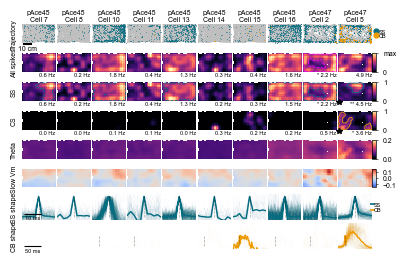

Rendering SpatialHeatmaps_All_NonPLCs_part03.svg: cells=10
pAce46 Cell 1: removed_snr=0/598579 (0.00%), removed_total=0/598579 (0.00%)
pAce46 Cell 1: CS PF mask is empty
pAce46 Cell 2: removed_snr=246895/598579 (41.25%), removed_total=246895/598579 (41.25%)
pAce46 Cell 2: CS PF mask is empty
pAce46 Cell 3: removed_snr=424887/598579 (70.98%), removed_total=424887/598579 (70.98%)
pAce46 Cell 4: removed_snr=12322/598579 (2.06%), removed_total=12322/598579 (2.06%)
pAce46 Cell 4: CS PF mask is empty
pAce46 Cell 5: removed_snr=0/598579 (0.00%), removed_total=0/598579 (0.00%)
pAce46 Cell 6: removed_snr=0/598579 (0.00%), removed_total=0/598579 (0.00%)
pAce46 Cell 6: All spikes PF mask is empty
pAce46 Cell 6: SS PF mask is empty
pAce46 Cell 6: CS PF mask is empty
pAce46 Cell 7: removed_snr=0/598579 (0.00%), removed_total=0/598579 (0.00%)
pAce46 Cell 7: All spikes PF mask is empty
pAce46 Cell 8: removed_snr=70616/598579 (11.80%), removed_total=70616/598579 (11.80%)
pAce46 Cell 9: removed_snr=0/5

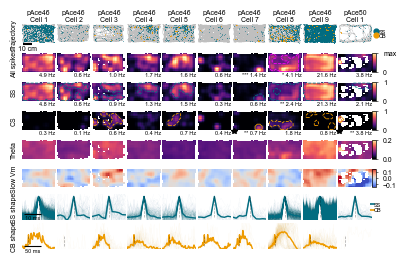

Rendering SpatialHeatmaps_All_NonPLCs_part04.svg: cells=6
pAce50 Cell 2: removed_snr=0/599087 (0.00%), removed_total=0/599087 (0.00%)
pAce50 Cell 4: removed_snr=0/599087 (0.00%), removed_total=0/599087 (0.00%)
pAce50 Cell 4: CS PF mask is empty
pAce50 Cell 5: removed_snr=0/599087 (0.00%), removed_total=0/599087 (0.00%)
pAce50 Cell 5: All spikes PF mask is empty
pAce50 Cell 5: SS PF mask is empty
pAce50 Cell 5: CS PF mask is empty
pAce50 Cell 6: removed_snr=0/599087 (0.00%), removed_total=0/599087 (0.00%)
pAce50 Cell 6: CS PF mask is empty
pAce50 Cell 7: removed_snr=0/599087 (0.00%), removed_total=0/599087 (0.00%)
pAce50 Cell 7: CS PF mask is empty
pAce50 Cell 8: removed_snr=0/599087 (0.00%), removed_total=0/599087 (0.00%)
pAce50 Cell 8: CS PF mask is empty
Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/SpatialHeatmaps_All_NonPLCs_part04.svg


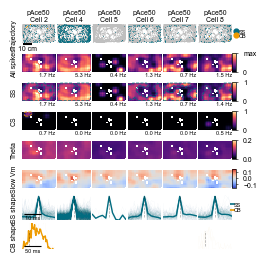

Generated files: 4
  /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/SpatialHeatmaps_All_NonPLCs_part01.svg
  /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/SpatialHeatmaps_All_NonPLCs_part02.svg
  /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/SpatialHeatmaps_All_NonPLCs_part03.svg
  /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/SpatialHeatmaps_All_NonPLCs_part04.svg


In [367]:
out_paths = render_spatial_heatmap_chunks(
    spatial_data.non_plcs,
    figure_save_folder=figure_save_folder,
    base_filename='SpatialHeatmaps_All_NonPLCs.svg',
    max_cells_per_figure=10,
    subplot_width=0.35,
    theta_vlim=selected_theta_vlim,
    slow_vlim=selected_slow_vlim,
    plot_putative_PF=True,
    show_place_cell_star=True,
    show_significance_marker=True,
    pf_only_place_cells=False,
)

print(f"Generated files: {len(out_paths)}")
for pth in out_paths:
    print(f"  {pth}")


### Pooled Stats Prep (Direct Core Functions)

In [368]:
pooled_stats = prepare_pooled_stats_tables(
    data_folder=str(config.data_root),
    folders=config.animals,
    cb_num_threshold=config.pooled.cb_num_threshold,
    cs_peak_rate_threshold=config.pooled.cs_peak_rate_threshold,
    snr_threshold=config.analysis.snr_threshold,
)

df_cs_plc = pooled_stats.df_cs_plc
df_non_cs_plc = pooled_stats.df_non_cs_plc

print(f"Total valid cells: {len(pooled_stats.df_all)}")
print(f"Place cells: {len(pooled_stats.df_pc)}")
print(f"CS+ PLCs: {len(df_cs_plc)}")
print(f"CS- PLCs: {len(df_non_cs_plc)}")


Total valid cells: 56
Place cells: 20
CS+ PLCs: 12
CS- PLCs: 8


### combined_cs_plus_minus_4panels

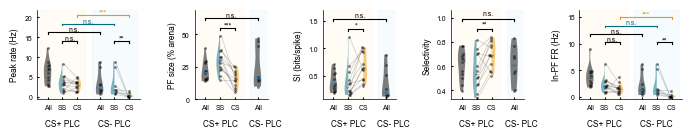

Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/combined_cs_plus_minus_4panels.svg


In [369]:
out_path = os.path.join(figure_save_folder, 'combined_cs_plus_minus_4panels.svg')
fig = plot_combined_cs_plus_minus_4panels(
    df_cs_plc=df_cs_plc,
    df_non_cs_plc=df_non_cs_plc,
    save_path=out_path,
    plot_cs_minus_ss=False,
)
plt.show()
print(f'Saved: {out_path}')


### cs_plus_plc_correlations_overlay_cs_ss

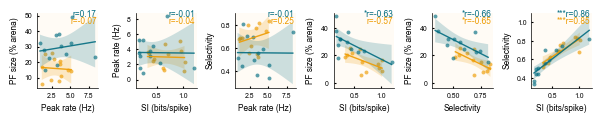

Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/cs_plus_plc_correlations_overlay_cs_ss.svg


In [370]:
out_path = os.path.join(figure_save_folder, 'cs_plus_plc_correlations_overlay_cs_ss.svg')
fig = plot_cs_plus_plc_correlations_overlay_cs_ss(
    df_cs_plc=df_cs_plc,
    save_path=out_path,
    overlay_ss_metrics=True,
)
plt.show()
print(f'Saved: {out_path}')


### ComplexBurstMetrics_CSplus_run

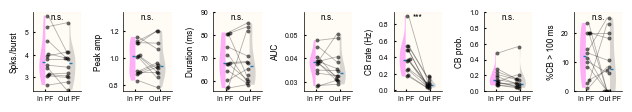

Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/ComplexBurstMetrics_CSplus_run.svg


In [371]:
out_path = os.path.join(figure_save_folder, 'ComplexBurstMetrics_CSplus_run.svg')
fig = plot_complex_burst_metrics_csplus(
    plcs_csplus=spatial_data.plcs_csplus,
    save_path=out_path,
    state_key='run',
)
plt.show()
print(f'Saved: {out_path}')


### CBrate_correlations_CSplus_InOut_alt

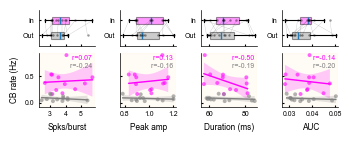

Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/CBrate_correlations_CSplus_InOut_alt.svg


In [372]:
out_path = os.path.join(figure_save_folder, 'CBrate_correlations_CSplus_InOut_alt.svg')
fig = plot_cbrate_correlations_csplus_inout_alt(
    plcs_csplus=spatial_data.plcs_csplus,
    save_path=out_path,
)
plt.show()
print(f'Saved: {out_path}')


### theta_inout_loco_csplus_vs_csminus

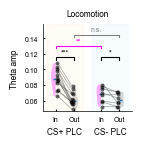

Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/theta_inout_loco_csplus_vs_csminus.svg


In [373]:
out_path = os.path.join(figure_save_folder, 'theta_inout_loco_csplus_vs_csminus.svg')
fig = plot_theta_inout_loco_csplus_vs_csminus(
    df_cs_plc=df_cs_plc,
    df_non_cs_plc=df_non_cs_plc,
    save_path=out_path,
)
plt.show()
print(f'Saved: {out_path}')


### slow_vm_inout_loco_csplus_vs_csminus

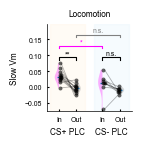

Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/slow_vm_inout_loco_csplus_vs_csminus.svg


In [374]:
out_path = os.path.join(figure_save_folder, 'slow_vm_inout_loco_csplus_vs_csminus.svg')
fig = plot_slow_vm_inout_loco_csplus_vs_csminus(
    df_cs_plc=df_cs_plc,
    df_non_cs_plc=df_non_cs_plc,
    save_path=out_path,
)
plt.show()
print(f'Saved: {out_path}')


# Trial by Trial Analysis, time based

### Trial-by-Trial Traversal Plots (CS+ PLCs / CS- PLCs, Per PF)

In [16]:
trial_plot_dilation_bins = 0 #place_cell_params.pf_reliability_dilation_bins  # set 0 for no dilation
trial_plot_dilation_shape = place_cell_params.pf_reliability_dilation_shape  # 'disk' | 'square' | 'manhattan'
trial_plot_slow_trace_gap = 1.0  # legacy vertical offset: slow Vm below trace
trial_plot_theta_slow_pad_factor = 0.05  # legacy theta-vs-slow padding factor
trial_plot_traversal_merge_gap_s = traversal_params.traversal_merge_gap_s  # gap threshold for merging nearby traversals in trial-by-trial plots (in seconds)

trial_plot_results = generate_trial_by_trial_plc_plots(
    config=config,
    spatial_data=spatial_data,
    figure_save_folder=figure_save_folder,
    clear_output=True,
    save_summary_csv=True,
    show_plots=False,
    show_rest_patches=False, 
    show_pf_prepost_patches=True,
    pf_prepost_patch_alpha=0.05,
    pf_reliability_dilation_bins=trial_plot_dilation_bins,
    pf_reliability_dilation_shape=trial_plot_dilation_shape,
    trace_slow_gap=trial_plot_slow_trace_gap,
    theta_slow_pad_factor=trial_plot_theta_slow_pad_factor,
    sharey=True,
    traversal_merge_gap_s=trial_plot_traversal_merge_gap_s,
)


print(f"Summary CSV: {trial_plot_results['summary_csv']}")
print(
    f"Dilation used: bins={trial_plot_results['dilation_bins']}, shape={trial_plot_results['dilation_shape']}"
)
print(
    f"Trace/slow/theta offsets: slow_trace_gap={trial_plot_results['trace_slow_gap']}, theta_slow_pad_factor={trial_plot_results['theta_slow_pad_factor']}"
)
print(f"Traversal merge gap (s): {trial_plot_results['traversal_merge_gap_s']}")
print('Counters:')
for k, v in trial_plot_results['counters'].items():
    print(f"  {k}: {v}")

summary_df = trial_plot_results['summary_df']
if len(summary_df) > 0:
    display(summary_df.head(20))

print(f"CS+ output folder: {trial_plot_results['csplus_dir']}")
print(f"CS- output folder: {trial_plot_results['csminus_dir']}")


CKII_pAce21_PR_20250806: SNR filter kept 9/9 cells (threshold=3.5, min_good_minutes=5.0).
Found 23 traversal epochs (min duration: 100.0 ms, min distance: 5.0 cm, max PF distance: 8.0 cm)
Place field has 58 bins, peak rate: 6.01 Hz


/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/utils/placecell_core.py:9369: RuntimeWarning: invalid value encountered in divide
  ss_pct = np.where(valid, 100.0 * ss_seg / denom, np.nan)
/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/utils/placecell_core.py:9370: RuntimeWarning: invalid value encountered in divide
  cs_pct = np.where(valid, 100.0 * cs_seg / denom, np.nan)
/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/utils/placecell_core.py:9380: RuntimeWarning: Mean of empty slice
  pf_ss_pct_mean = np.nanmean(ss_pct_stack, axis=0) if include_pf_pct else None
/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/utils/placecell_core.py:9381: RuntimeWarning: Mean of empty slice
  pf_cs_pct_mean = np.nanmean(cs_pct_stack, axis=0) if include_pf_pct else None
/opt/homebrew/Caskroom/miniforge/base/

Plotted 18 traversal trials (14 with spikes in PF, used for average)
CKII_pAce38_PX_20251126: SNR filter kept 8/9 cells (threshold=3.5, min_good_minutes=5.0).
Found 36 traversal epochs (min duration: 100.0 ms, min distance: 5.0 cm, max PF distance: 8.0 cm)
Place field has 80 bins, peak rate: 8.83 Hz
Plotted 35 traversal trials (35 with spikes in PF, used for average)
Found 60 traversal epochs (min duration: 100.0 ms, min distance: 5.0 cm, max PF distance: 8.0 cm)
Place field has 28 bins, peak rate: 3.98 Hz
Plotted 58 traversal trials (50 with spikes in PF, used for average)
Found 33 traversal epochs (min duration: 100.0 ms, min distance: 5.0 cm, max PF distance: 8.0 cm)
Place field has 35 bins, peak rate: 7.09 Hz
Plotted 32 traversal trials (31 with spikes in PF, used for average)
Found 47 traversal epochs (min duration: 100.0 ms, min distance: 5.0 cm, max PF distance: 8.0 cm)
Place field has 28 bins, peak rate: 3.32 Hz
Plotted 45 traversal trials (43 with spikes in PF, used for averag

,category,animal_id,cell_idx,cell_num,pf_rank,status,n_traversals,message
0,CSplus,CKII_pAce21_PR_20250806,2,3,1,saved,22,/Users/qixinyang/Documents/AdamLab/miniVI_Rena...
1,CSplus,CKII_pAce38_PX_20251126,0,1,1,saved,36,/Users/qixinyang/Documents/AdamLab/miniVI_Rena...
2,CSplus,CKII_pAce38_PX_20251126,0,1,2,saved,59,/Users/qixinyang/Documents/AdamLab/miniVI_Rena...
3,CSplus,CKII_pAce38_PX_20251126,3,4,1,saved,33,/Users/qixinyang/Documents/AdamLab/miniVI_Rena...
4,CSplus,CKII_pAce38_PX_20251126,3,4,2,saved,47,/Users/qixinyang/Documents/AdamLab/miniVI_Rena...
5,CSplus,CKII_pAce38_PX_20251126,5,6,1,saved,47,/Users/qixinyang/Documents/AdamLab/miniVI_Rena...
6,CSplus,CKII_pAce38_PX_20251126,5,6,2,saved,48,/Users/qixinyang/Documents/AdamLab/miniVI_Rena...
7,CSplus,CKII_pAce38_PX_20251126,6,7,1,saved,46,/Users/qixinyang/Documents/AdamLab/miniVI_Rena...
8,CSplus,CKII_pAce38_PX_20251126,6,7,2,saved,50,/Users/qixinyang/Documents/AdamLab/miniVI_Rena...
9,CSplus,CKII_pAce45_PX_20260118,4,5,1,saved,42,/Users/qixinyang/Documents/AdamLab/miniVI_Rena...


CS+ output folder: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/figures/CKII_pooled/PF_traversal_trials_CSplus_PLCs
CS- output folder: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/figures/CKII_pooled/PF_traversal_trials_CSminus_PLCs


### PF-Centered Dataset Prep (Primary + Secondary PF)

In [17]:
pf_centered_dataset = build_pf_centered_component_dataset(
    config=config,
    spatial_data=spatial_data,
    pf_ranks=(1, 2),
    pf_reliability_dilation_bins=trial_plot_dilation_bins,
    pf_reliability_dilation_shape=trial_plot_dilation_shape,
)

for cat in ('CSplus', 'CSminus'):
    cat_data = pf_centered_dataset.get(cat, {})
    p1 = cat_data.get(1, {})
    p2 = cat_data.get(2, {})
    print(f"{cat} PF1: {p1.get('n_entries', 0)} entries (skipped={p1.get('n_skipped', 0)})")
    print(f"{cat} PF2: {p2.get('n_entries', 0)} entries (skipped={p2.get('n_skipped', 0)})")


CKII_pAce21_PR_20250806: SNR filter kept 9/9 cells (threshold=3.5, min_good_minutes=5.0).
Found 26 traversal epochs (min duration: 100.0 ms, min distance: 5.0 cm, max PF distance: 8.0 cm)
Place field has 58 bins, peak rate: 6.01 Hz


/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/utils/placecell_pipeline.py:3282: RuntimeWarning: invalid value encountered in divide
  ss_pct_trial[write_start:write_end] = np.where(valid_denom, 100.0 * ss_seg / denom, np.nan)
/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/utils/placecell_pipeline.py:3283: RuntimeWarning: invalid value encountered in divide
  cs_pct_trial[write_start:write_end] = np.where(valid_denom, 100.0 * cs_seg / denom, np.nan)
/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/utils/placecell_pipeline.py:3365: RuntimeWarning: Mean of empty slice
  'ss_pct_mean': np.nanmean(ss_pct_arr, axis=0) if ss_pct_arr.size > 0 else np.full(avg_len, np.nan),
/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/utils/placecell_pipeline.py:3366: RuntimeWarning: Mean of empty slice
  'cs_pct_

CKII_pAce38_PX_20251126: SNR filter kept 8/9 cells (threshold=3.5, min_good_minutes=5.0).
Found 43 traversal epochs (min duration: 100.0 ms, min distance: 5.0 cm, max PF distance: 8.0 cm)
Place field has 80 bins, peak rate: 8.83 Hz
Found 36 traversal epochs (min duration: 100.0 ms, min distance: 5.0 cm, max PF distance: 8.0 cm)
Place field has 35 bins, peak rate: 7.09 Hz
Found 57 traversal epochs (min duration: 100.0 ms, min distance: 5.0 cm, max PF distance: 8.0 cm)
Place field has 66 bins, peak rate: 7.77 Hz
Found 52 traversal epochs (min duration: 100.0 ms, min distance: 5.0 cm, max PF distance: 8.0 cm)
Place field has 37 bins, peak rate: 7.01 Hz
CKII_pAce45_PX_20260118: SNR filter kept 14/16 cells (threshold=3.5, min_good_minutes=5.0).
Found 48 traversal epochs (min duration: 100.0 ms, min distance: 5.0 cm, max PF distance: 8.0 cm)
Place field has 44 bins, peak rate: 4.33 Hz
Found 84 traversal epochs (min duration: 100.0 ms, min distance: 5.0 cm, max PF distance: 8.0 cm)
Place fiel

### PF-Centered Individual Heatmaps (CS+ / CS-)

In [18]:
pf_heatmap_summary = generate_pf_centered_component_heatmaps(
    dataset=pf_centered_dataset,
    figure_save_folder=figure_save_folder,
    clear_output=True,
    smooth_window=300,
    fr_vmax_scale=0.6,
    theta_vlim=(0, 0.5),
    slow_vlim=(-0.5, 0.5),
    fig_width=3.8,
    trial_height=0.02,
    xlim=(-4, 4),
    merge_ss_cs=True,
    merge_plateau=True,
    plateau_vlim=0.01,
    avg_smooth_window=0,
    show_plot=False,
)

for cat, info in pf_heatmap_summary.items():
    print(f"{cat} folder: {info['output_dir']}")
    print(f"{cat} summary: {info}")


PF-centered heatmaps root folder: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/figures/CKII_pooled
[CSplus] output folder: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/figures/CKII_pooled/pf_centered_CSplus_heatmaps


/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/utils/placecell_pipeline.py:7191: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  tight_fn()


[CSplus] 1/10 saved: CKII_pAce21_PR_20250806_Cell3_heatmap.svg
[CSplus] 2/10 saved: CKII_pAce38_PX_20251126_Cell1_heatmap.svg
[CSplus] 3/10 saved: CKII_pAce38_PX_20251126_Cell4_heatmap.svg
[CSplus] 4/10 saved: CKII_pAce38_PX_20251126_Cell6_heatmap.svg
[CSplus] 5/10 saved: CKII_pAce38_PX_20251126_Cell7_heatmap.svg
[CSplus] 6/10 saved: CKII_pAce45_PX_20260118_Cell5_heatmap.svg
[CSplus] 7/10 saved: CKII_pAce45_PX_20260118_Cell12_heatmap.svg
[CSplus] 8/10 saved: CKII_pAce47_PX_20260128_Cell1_heatmap.svg
[CSplus] 9/10 saved: CKII_pAce47_PX_20260128_Cell3_heatmap.svg
[CSplus] 10/10 saved: CKII_pAce47_PX_20260128_Cell4_heatmap.svg
[CSminus] output folder: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/figures/CKII_pooled/pf_centered_CSminus_heatmaps
[CSminus] 1/5 saved: CKII_pAce21_PR_20250806_Cell1_heatmap.svg
[CSminus] 2/5 saved: CKII_pAce38_PX_20251126_Cell5_heatmap.svg
[CSminus] 3/5 saved: CKII_pAce38_PX_20251126_Cell9_heatmap.svg
[CSminus

### PF-Centered Average Plot (CS+; Primary + Secondary)

PF1 counts: All (n=10), Pref (n=10), Non-pref (n=10)
PF2 counts: All (n=8), Pref (n=8), Non-pref (n=8)


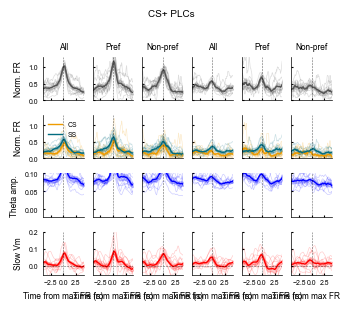

Generated: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/figures/CKII_pooled/pf_centered_CSplus_average_primary_secondary.svg


In [19]:
out_cs_plus_avg = os.path.join(figure_save_folder, 'pf_centered_CSplus_average_primary_secondary.svg')
pf_avg_fr_row_ylim_max = 1.3  # tune first-row (Norm. FR) ymax
min_traversals_per_type = 5  # minimum number of traversals required per PF type (primary/secondary) to be included in the average plot
plot_pf_centered_category_primary_secondary_from_dataset(
    dataset=pf_centered_dataset,
    category='CSplus',
    title='CS+ PLCs',
    out_path=out_cs_plus_avg,
    smooth_window=400,
    plot_trials=True,
    trial_alpha=0.2,
    trial_linewidth=0.5,
    theta_ylim=(-0.02, 0.1),
    slow_ylim=(-0.05, 0.2),
    fr_ylim_scale=1.2,
    ss_cs_ylim_scale=1.2,
    figsize_per_block=(3.4, 3.0),
    xlim=(-4, 4),
    fr_row_ylim_max=pf_avg_fr_row_ylim_max,
    show_plot=True,
    min_traversals_per_type=min_traversals_per_type,
)
print(f'Generated: {out_cs_plus_avg}')


### PF-Centered Average Plot (CS-; Primary + Secondary)

PF1 counts: All (n=5), Pref (n=5), Non-pref (n=5)
PF2 counts: All (n=1), Pref (n=1), Non-pref (n=1)


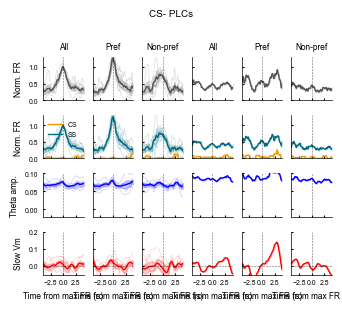

Generated: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/figures/CKII_pooled/pf_centered_CSminus_average_primary_secondary.svg


In [20]:
out_cs_minus_avg = os.path.join(figure_save_folder, 'pf_centered_CSminus_average_primary_secondary.svg')
pf_avg_fr_row_ylim_max = 1.3  # tune first-row (Norm. FR) ymax
plot_pf_centered_category_primary_secondary_from_dataset(
    dataset=pf_centered_dataset,
    category='CSminus',
    title='CS- PLCs',
    out_path=out_cs_minus_avg,
    smooth_window=400,
    plot_trials=True,
    trial_alpha=0.2,
    trial_linewidth=0.5,
    theta_ylim=(-0.02, 0.1),
    slow_ylim=(-0.05, 0.2),
    fr_ylim_scale=1.2,
    ss_cs_ylim_scale=1.2,
    figsize_per_block=(3.4, 3.0),
    xlim=(-4, 4),
    fr_row_ylim_max=pf_avg_fr_row_ylim_max,
    show_plot=True,
    min_traversals_per_type=min_traversals_per_type,  
)
print(f'Generated: {out_cs_minus_avg}')


### PF-Centered Selectivity Summary (5 Panels)

In [21]:
selectivity_timepoint_sec = 0.0
selectivity_min_traversals_per_type = 5  # tune this
selectivity_save_csv = True
selectivity_smooth_window = 400  # match PF-centered average plotting smoothing
selectivity_auc_window_sec = (-3.0, 3.0)  # used for theta/slow positive AUC


In [22]:
pf_selectivity_results = compute_pf_centered_selectivity_summary(
    pf_centered_dataset=pf_centered_dataset,
    timepoint_sec=selectivity_timepoint_sec,
    min_traversals_per_type=selectivity_min_traversals_per_type,
    smooth_window=selectivity_smooth_window,
    auc_window_sec=selectivity_auc_window_sec,
)

print("Skipped counts:", pf_selectivity_results.get("skipped_counts", {}))
print("Example group/metric counts (first 10):")
gmc = pf_selectivity_results.get("group_metric_counts", {})
for k in list(gmc.keys())[:10]:
    print(f"  {k}: {gmc[k]}")


Skipped counts: {'missing': 0, 'low_traversals': 0, 'no_preferred': 0}
Example group/metric counts (first 10):
  CSminus_PF1::all_spike: 4
  CSminus_PF1::cs: 1
  CSminus_PF1::slow_vm: 4
  CSminus_PF1::ss: 4
  CSminus_PF1::theta_amp: 4
  CSplus_PF1::all_spike: 7
  CSplus_PF1::cs: 7
  CSplus_PF1::slow_vm: 7
  CSplus_PF1::ss: 7
  CSplus_PF1::theta_amp: 7



All spike:
  CS+ PF1 vs PF2: n=8, test=paired t-test, shapiro_p=0.182, stat=-1.55, p=0.166, sig=n.s.
  CS+ PF1 vs CS- PF1: n=(10,5), test=mann-whitney (n<=6), stat=7, p=0.028, sig=*

SS:
  CS+ PF1 vs PF2: n=8, test=paired t-test, shapiro_p=0.34, stat=-2, p=0.0857, sig=n.s.
  CS+ PF1 vs CS- PF1: n=(10,5), test=mann-whitney (n<=6), stat=11, p=0.0992, sig=n.s.

CS:
  CS+ PF1 vs PF2: n=8, test=paired t-test, shapiro_p=0.958, stat=-0.636, p=0.545, sig=n.s.

Theta amp:
  CS+ PF1 vs PF2: n=8, test=paired t-test, shapiro_p=0.797, stat=0.222, p=0.831, sig=n.s.
  CS+ PF1 vs CS- PF1: n=(10,5), test=mann-whitney (n<=6), stat=43, p=0.028, sig=*

Slow Vm:
  CS+ PF1 vs PF2: n=8, test=paired t-test, shapiro_p=0.253, stat=0.497, p=0.634, sig=n.s.
  CS+ PF1 vs CS- PF1: n=(10,5), test=mann-whitney (n<=6), stat=32, p=0.44, sig=n.s.


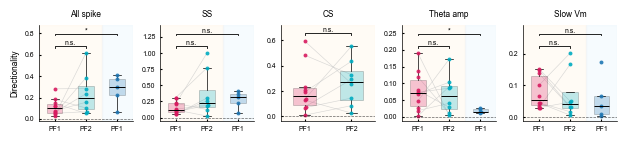

Generated:
  figure: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/figures/CKII_pooled/pf_centered_selectivity_summary_5panels.svg
  per_cell_csv: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/figures/CKII_pooled/pf_centered_selectivity_per_cell.csv
  stats_csv: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/figures/CKII_pooled/pf_centered_selectivity_stats.csv


In [23]:
pf_selectivity_paths = plot_pf_centered_selectivity_summary(
    selectivity_results=pf_selectivity_results,
    figure_save_folder=figure_save_folder,
    show_plot=True,
    save_csv=selectivity_save_csv,
)

print("Generated:")
for k, v in pf_selectivity_paths.items():
    print(f"  {k}: {v}")


### CS+ 2PF Session Delta (SS vs CS)

In [24]:
csplus_delta_results = compute_csplus_two_pf_session_delta(
    config=config,
    pf_centered_dataset=pf_centered_dataset,
    fr_estimator = "trial_mean", # "pooled" | "trial_mean"
    delta_formula="symmetric",   # 'symmetric' or "fr1"
    force_nonparametric=False,  # auto parametric/nonparametric
    min_total_traversals_per_pf=5,
)

csplus_delta_per_cell = csplus_delta_results['per_cell_pf']
csplus_delta_stats = csplus_delta_results['stats_summary']

print(f"Cells PF1 (eligible): {csplus_delta_results.get('n_cells_pf1', 'n/a')}")
print(f"Cells PF2 (eligible): {csplus_delta_results.get('n_cells_pf2', 'n/a')}")
print(f"Cells overlap PF1&PF2: {csplus_delta_results['n_cells_with_pf1_pf2']}")
print(f"Excluded PF1 entries by traversal gate (<= {csplus_delta_results.get('min_traversals_per_session_per_pf', csplus_delta_results['min_total_traversals_per_pf'])} in any session): {csplus_delta_results.get('n_entries_excluded_low_traversals_pf1', 'n/a')}")
print(f"Excluded PF2 entries by traversal gate (<= {csplus_delta_results.get('min_traversals_per_session_per_pf', csplus_delta_results['min_total_traversals_per_pf'])} in any session): {csplus_delta_results.get('n_entries_excluded_low_traversals_pf2', 'n/a')}")
print(f"Per-cell rows: {len(csplus_delta_per_cell)}")
print(f"Stats rows: {len(csplus_delta_stats)}")

if len(csplus_delta_per_cell) > 0:
    display(csplus_delta_per_cell.head(20))
if len(csplus_delta_stats) > 0:
    display(csplus_delta_stats)


CKII_pAce21_PR_20250806: SNR filter kept 9/9 cells (threshold=3.5, min_good_minutes=5.0).
CKII_pAce38_PX_20251126: SNR filter kept 8/9 cells (threshold=3.5, min_good_minutes=5.0).
CKII_pAce45_PX_20260118: SNR filter kept 14/16 cells (threshold=3.5, min_good_minutes=5.0).
CKII_pAce47_PX_20260128: SNR filter kept 4/5 cells (threshold=3.5, min_good_minutes=5.0).
Cells PF1 (eligible): 8
Cells PF2 (eligible): 7
Cells overlap PF1&PF2: 6
Excluded PF1 entries by traversal gate (<= 5 in any session): 1
Excluded PF2 entries by traversal gate (<= 5 in any session): 1
Per-cell rows: 43
Stats rows: 18


,animal_id,cell_idx,cell_num,pf_rank,direction,s1_start_sec,s1_end_sec,s2_start_sec,s2_end_sec,n_trials_s1,...,fr1_cs_pooled,fr2_cs_pooled,fr1_all_pooled,fr2_all_pooled,delta_ss,delta_cs,delta_all,abs_delta_ss,abs_delta_cs,abs_delta_all
0,CKII_pAce38_PX_20251126,0,1,1,all,0.0,597.788,597.788,1195.340,20,...,2.116577,1.481847,5.926417,3.817815,-0.239845,-0.284581,-0.254961,0.239845,0.284581,0.254961
1,CKII_pAce38_PX_20251126,0,1,1,preferred,0.0,597.788,597.788,1195.340,14,...,2.452808,1.755678,6.420584,4.417511,-0.204296,-0.299036,-0.237982,0.204296,0.299036,0.237982
2,CKII_pAce38_PX_20251126,0,1,1,nonpreferred,0.0,597.788,597.788,1195.340,6,...,1.019768,0.753352,4.314402,2.222390,-0.354163,-0.206492,-0.314124,0.354163,0.206492,0.314124
3,CKII_pAce38_PX_20251126,3,4,1,all,0.0,597.788,597.788,1195.340,17,...,3.754645,0.586265,7.279415,2.826633,-0.226950,-0.803006,-0.461747,0.226950,0.803006,0.461747
4,CKII_pAce38_PX_20251126,3,4,1,preferred,0.0,597.788,597.788,1195.340,9,...,3.808346,0.499282,7.323742,2.558822,-0.217307,-0.837346,-0.472001,0.217307,0.837346,0.472001
5,CKII_pAce38_PX_20251126,3,4,1,nonpreferred,0.0,597.788,597.788,1195.340,8,...,3.677840,0.763650,7.216015,3.372789,-0.291547,-0.696073,-0.462682,0.291547,0.696073,0.462682
6,CKII_pAce38_PX_20251126,5,6,1,all,0.0,597.788,597.788,1195.340,21,...,3.508606,0.395949,8.842634,2.146459,-0.546655,-0.816281,-0.648748,0.546655,0.816281,0.648748
7,CKII_pAce38_PX_20251126,5,6,1,preferred,0.0,597.788,597.788,1195.340,5,...,3.993115,0.462089,9.328744,2.380761,-0.446490,-0.735860,-0.557774,0.446490,0.735860,0.557774
8,CKII_pAce38_PX_20251126,5,6,1,nonpreferred,0.0,597.788,597.788,1195.340,16,...,3.254149,0.247692,8.587338,1.621256,-0.681152,-0.937477,-0.778461,0.681152,0.937477,0.778461
9,CKII_pAce38_PX_20251126,6,7,1,all,0.0,597.788,597.788,1195.340,40,...,2.760569,0.720530,5.521138,2.545874,-0.178190,-0.559088,-0.349670,0.178190,0.559088,0.349670


,direction,comparison,pf_rank,metric_left,metric_right,n,p_value,statistic,test,shapiro_p,left_mean,right_mean,force_nonparametric,fr_estimator,delta_formula
0,all,abs_delta_cs_vs_ss,1.0,abs_delta_cs,abs_delta_ss,8,0.082488,2.025255,paired t-test,0.673975,0.547018,0.370041,False,trial_mean,symmetric
1,all,signed_delta_cs_vs_ss,1.0,delta_cs,delta_ss,8,0.082488,-2.025255,paired t-test,0.673975,-0.547018,-0.370041,False,trial_mean,symmetric
2,all,abs_delta_cs_vs_ss,2.0,abs_delta_cs,abs_delta_ss,7,0.005960,4.157712,paired t-test,0.142098,0.743932,0.464758,False,trial_mean,symmetric
3,all,signed_delta_cs_vs_ss,2.0,delta_cs,delta_ss,7,0.319129,-1.086106,paired t-test,0.555116,-0.528781,-0.319695,False,trial_mean,symmetric
4,all,abs_delta_ss_pf2_vs_pf1,NaN,abs_delta_ss_pf2,abs_delta_ss_pf1,6,0.472429,0.776761,paired t-test,0.504853,0.464758,0.370041,False,trial_mean,symmetric
5,all,abs_delta_cs_pf2_vs_pf1,NaN,abs_delta_cs_pf2,abs_delta_cs_pf1,6,0.376253,0.970760,paired t-test,0.315136,0.743932,0.547018,False,trial_mean,symmetric
6,preferred,abs_delta_cs_vs_ss,1.0,abs_delta_cs,abs_delta_ss,8,0.181117,1.485026,paired t-test,0.889616,0.480006,0.330314,False,trial_mean,symmetric
7,preferred,signed_delta_cs_vs_ss,1.0,delta_cs,delta_ss,8,0.181117,-1.485026,paired t-test,0.889616,-0.480006,-0.330314,False,trial_mean,symmetric
8,preferred,abs_delta_cs_vs_ss,2.0,abs_delta_cs,abs_delta_ss,6,0.183617,1.542406,paired t-test,0.882225,0.701379,0.579744,False,trial_mean,symmetric
9,preferred,signed_delta_cs_vs_ss,2.0,delta_cs,delta_ss,6,0.870612,-0.171424,paired t-test,0.939708,-0.488916,-0.472141,False,trial_mean,symmetric



CS+ 2PF Session Delta: Absolute Change stats (direction=all) | fr_estimator=trial_mean, delta_formula=symmetric, force_nonparametric=False
  PF1 SS vs CS: n=8, test=paired t-test, shapiro_p=0.674 stat=-2.03, p=0.0825, sig=n.s.
  PF2 SS vs CS: n=7, test=paired t-test, shapiro_p=0.142 stat=-4.16, p=0.00596, sig=**
  SS PF1 vs PF2: n=6, test=paired t-test, shapiro_p=0.505 stat=-0.777, p=0.472, sig=n.s.
  CS PF1 vs PF2: n=6, test=paired t-test, shapiro_p=0.315 stat=-0.971, p=0.376, sig=n.s.


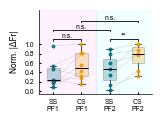


CS+ 2PF Session Delta: Signed Change stats (direction=all) | fr_estimator=trial_mean, delta_formula=symmetric, force_nonparametric=False
  PF1 SS vs CS: n=8, test=paired t-test, shapiro_p=0.674 stat=2.03, p=0.0825, sig=n.s.
  PF2 SS vs CS: n=7, test=paired t-test, shapiro_p=0.555 stat=1.09, p=0.319, sig=n.s.
  SS PF1 vs PF2: n=6, test=paired t-test, shapiro_p=0.276 stat=-0.0773, p=0.941, sig=n.s.
  CS PF1 vs PF2: n=6, test=paired t-test, shapiro_p=0.0641 stat=-0.114, p=0.913, sig=n.s.


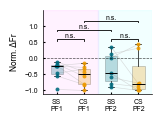

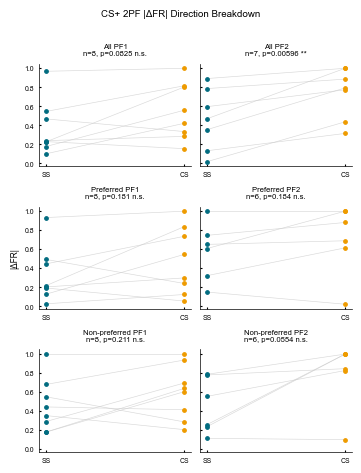

Generated figures:
  abs_paired: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/figures/CKII_pooled/csplus_2pf_abs_delta_ss_vs_cs_paired.svg
  signed_stripbox: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/figures/CKII_pooled/csplus_2pf_signed_delta_ss_vs_cs_stripbox.svg
  direction_breakdown: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/figures/CKII_pooled/csplus_2pf_abs_delta_direction_breakdown.svg


In [25]:
csplus_delta_fig_paths = plot_csplus_two_pf_session_delta(
    delta_results=csplus_delta_results,
    figure_save_folder=figure_save_folder,
    show_plot=True,
)

print('Generated figures:')
for k, v in csplus_delta_fig_paths.items():
    print(f"  {k}: {v}")


In [26]:
csplus_delta_per_cell_csv = os.path.join(figure_save_folder, 'csplus_2pf_session_delta_per_cell.csv')
csplus_delta_stats_csv = os.path.join(figure_save_folder, 'csplus_2pf_session_delta_stats.csv')

csplus_delta_per_cell.to_csv(csplus_delta_per_cell_csv, index=False)
csplus_delta_stats.to_csv(csplus_delta_stats_csv, index=False)

print(f"Saved: {csplus_delta_per_cell_csv}")
print(f"Saved: {csplus_delta_stats_csv}")


Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/figures/CKII_pooled/csplus_2pf_session_delta_per_cell.csv
Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/figures/CKII_pooled/csplus_2pf_session_delta_stats.csv


### CS+ vs CS- Primary PF Session Delta (Primary PF)


In [27]:
cs_category_delta_results = compute_csplus_vs_csminus_primary_pf_session_delta(
    config=config,
    pf_centered_dataset=pf_centered_dataset,
    fr_estimator="trial_mean",  # "pooled" | "trial_mean"
    delta_formula="symmetric",  # "symmetric" | "fr1"
    force_nonparametric=True,
    min_traversals_per_session_primary_pf=5,
)

cs_category_delta_per_cell = cs_category_delta_results["per_cell_pf"]
cs_category_delta_stats = cs_category_delta_results["stats_summary"]

print(f"CS+ cells: {cs_category_delta_results['n_cells_csplus']}")
print(f"CS- cells: {cs_category_delta_results['n_cells_csminus']}")
print(f"Per-cell rows: {len(cs_category_delta_per_cell)}")
print(f"Stats rows: {len(cs_category_delta_stats)}")
print(f"Excluded by traversal gate CS+: {cs_category_delta_results.get('n_excluded_by_traversal_gate_csplus', 'n/a')}")
print(f"Excluded by traversal gate CS-: {cs_category_delta_results.get('n_excluded_by_traversal_gate_csminus', 'n/a')}")
print(f"Traversal gate threshold (> per session): {cs_category_delta_results.get('min_traversals_per_session_primary_pf', 'n/a')}")

if len(cs_category_delta_per_cell) > 0:
    display(cs_category_delta_per_cell.head(20))
if len(cs_category_delta_stats) > 0:
    display(cs_category_delta_stats)


CKII_pAce21_PR_20250806: SNR filter kept 9/9 cells (threshold=3.5, min_good_minutes=5.0).
CKII_pAce38_PX_20251126: SNR filter kept 8/9 cells (threshold=3.5, min_good_minutes=5.0).
CKII_pAce45_PX_20260118: SNR filter kept 14/16 cells (threshold=3.5, min_good_minutes=5.0).
CKII_pAce47_PX_20260128: SNR filter kept 4/5 cells (threshold=3.5, min_good_minutes=5.0).
CS+ cells: 8
CS- cells: 4
Per-cell rows: 12
Stats rows: 4
Excluded by traversal gate CS+: 1
Excluded by traversal gate CS-: 0
Traversal gate threshold (> per session): 5


,category,animal_id,cell_idx,cell_num,pf_rank,direction,gate_n_trials_s1,gate_n_trials_s2,n_trials_s1,n_trials_s2,...,fr1_cs,fr2_cs,fr1_all,fr2_all,delta_ss,delta_cs,delta_all,abs_delta_ss,abs_delta_cs,abs_delta_all
0,CSplus,CKII_pAce38_PX_20251126,0,1,1,all,20,23,20,23,...,2.002833,1.115434,5.790823,3.437870,-0.239845,-0.284581,-0.254961,0.239845,0.284581,0.254961
1,CSplus,CKII_pAce38_PX_20251126,3,4,1,all,17,19,17,19,...,3.663488,0.400268,7.286880,2.683215,-0.226950,-0.803006,-0.461747,0.226950,0.803006,0.461747
2,CSplus,CKII_pAce38_PX_20251126,5,6,1,all,21,34,21,34,...,3.941645,0.398702,9.449582,2.013151,-0.546655,-0.816281,-0.648748,0.546655,0.816281,0.648748
3,CSplus,CKII_pAce38_PX_20251126,6,7,1,all,40,10,40,10,...,2.930867,0.828852,5.635705,2.715527,-0.178190,-0.559088,-0.349670,0.178190,0.559088,0.349670
4,CSplus,CKII_pAce45_PX_20260118,4,5,1,all,25,23,25,23,...,0.943839,0.383830,3.421071,2.403585,-0.101730,-0.421798,-0.174686,0.101730,0.421798,0.174686
5,CSplus,CKII_pAce45_PX_20260118,11,12,1,all,46,36,46,36,...,1.389654,0.691629,2.737549,1.179640,-0.468370,-0.335382,-0.397711,0.468370,0.335382,0.397711
6,CSplus,CKII_pAce47_PX_20260128,0,1,1,all,30,11,30,11,...,4.911912,3.586142,11.681827,7.825199,-0.229891,-0.156009,-0.197705,0.229891,0.156009,0.197705
7,CSplus,CKII_pAce47_PX_20260128,2,3,1,all,27,16,27,16,...,1.733396,0.000000,4.031217,0.036535,-0.968698,-1.000000,-0.982037,0.968698,1.000000,0.982037
8,CSminus,CKII_pAce38_PX_20251126,4,5,1,all,22,39,22,39,...,0.000000,0.000000,1.604932,0.605569,-0.452098,NaN,-0.452098,0.452098,NaN,0.452098
9,CSminus,CKII_pAce38_PX_20251126,8,9,1,all,41,39,41,39,...,0.000000,0.083533,0.732944,0.477974,-0.300254,1.000000,-0.210559,0.300254,1.000000,0.210559


,direction,comparison,metric_left,metric_right,n,n_left,n_right,p_value,statistic,test,shapiro_p,fr_estimator,delta_formula,force_nonparametric
0,all,abs_csplus_ss_vs_cs,abs_delta_ss_csplus,abs_delta_cs_csplus,8,8,8,0.082488,-2.025255,paired t-test,0.673975,trial_mean,symmetric,True
1,all,abs_ss_csplus_vs_csminus,abs_delta_ss_csplus,abs_delta_ss_csminus,4,8,4,0.367677,10.000000,mann-whitney (forced),NaN,trial_mean,symmetric,True
2,all,signed_csplus_ss_vs_cs,delta_ss_csplus,delta_cs_csplus,8,8,8,0.082488,2.025255,paired t-test,0.673975,trial_mean,symmetric,True
3,all,signed_ss_csplus_vs_csminus,delta_ss_csplus,delta_ss_csminus,4,8,4,0.367677,22.000000,mann-whitney (forced),NaN,trial_mean,symmetric,True



CS+ vs CS- Primary PF Session Delta: Absolute Change stats (direction=all) | fr_estimator=trial_mean, delta_formula=symmetric, force_nonparametric=True
  CS+ SS vs CS: n=8, test=paired t-test, p=0.0825, sig=n.s.
  SS CS+ vs CS-: n=(8,4), test=mann-whitney (forced), p=0.368, sig=n.s.


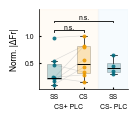


CS+ vs CS- Primary PF Session Delta: Signed Change stats (direction=all) | fr_estimator=trial_mean, delta_formula=symmetric, force_nonparametric=True
  CS+ SS vs CS: n=8, test=paired t-test, p=0.0825, sig=n.s.
  SS CS+ vs CS-: n=(8,4), test=mann-whitney (forced), p=0.368, sig=n.s.


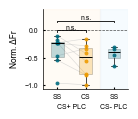

Generated figures:
  abs: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/figures/CKII_pooled/csplus_vs_csminus_primary_pf_abs_delta_ss_cs.svg
  signed: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/figures/CKII_pooled/csplus_vs_csminus_primary_pf_signed_delta_ss_cs.svg


In [28]:
cs_category_delta_fig_paths = plot_csplus_vs_csminus_primary_pf_session_delta(
    delta_results=cs_category_delta_results,
    figure_save_folder=figure_save_folder,
    show_plot=True,
)

print("Generated figures:")
for k, v in cs_category_delta_fig_paths.items():
    print(f"  {k}: {v}")


In [29]:
cs_category_delta_per_cell_csv = os.path.join(figure_save_folder, "csplus_vs_csminus_primary_pf_delta_per_cell.csv")
cs_category_delta_stats_csv = os.path.join(figure_save_folder, "csplus_vs_csminus_primary_pf_delta_stats.csv")

cs_category_delta_per_cell.to_csv(cs_category_delta_per_cell_csv, index=False)
cs_category_delta_stats.to_csv(cs_category_delta_stats_csv, index=False)

print(f"Saved: {cs_category_delta_per_cell_csv}")
print(f"Saved: {cs_category_delta_stats_csv}")


Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/figures/CKII_pooled/csplus_vs_csminus_primary_pf_delta_per_cell.csv
Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/figures/CKII_pooled/csplus_vs_csminus_primary_pf_delta_stats.csv


## Session Compare

### Session-Compare Parameters

In [30]:
session_compare_params = SessionCompareParams(
    panel_mode='s1_s2',  # 's1_s2' or 'combined_s1_s2'
    cache_version='v2',
    rebuild_cache=False,
    max_cells_per_figure=10,
    missing_s2_policy='na_panel',
    occupancy_spearman_threshold=-0.5,
    apply_occupancy_dataset_filter=True,
    enforce_s1s2_min_peak_rate_filter=True,
    s1s2_min_peak_rate_hz=0.5,
    clean_heatmap=True,
    heatmap_similarity_metric='weighted_pearson',
    plot_spike_shapes=True,
    plot_spike_shapes_overall=True,
    plot_spike_shapes_in_field=True,
    plot_spike_shapes_out_field=True,
    selected_theta_vlim=None,
    selected_slow_vlim=None,
)

print(session_compare_params)


SessionCompareParams(panel_mode='s1_s2', cache_version='v2', rebuild_cache=False, max_cells_per_figure=10, missing_s2_policy='na_panel', occupancy_spearman_threshold=-0.5, apply_occupancy_dataset_filter=True, enforce_s1s2_min_peak_rate_filter=True, s1s2_min_peak_rate_hz=0.5, clean_heatmap=True, heatmap_similarity_metric='weighted_pearson', plot_spike_shapes=True, plot_spike_shapes_overall=True, plot_spike_shapes_in_field=True, plot_spike_shapes_out_field=True, plot_PF_combined=True, selected_theta_vlim=None, selected_slow_vlim=None)


### Build/Load Payloads + Assemble Groups

In [31]:
session_compare_payloads = build_session_compare_payloads(config, session_compare_params)
session_compare_groups = assemble_session_compare_groups(config, session_compare_params, session_compare_payloads)

print(f"Datasets loaded: {len(session_compare_payloads['session_payload_by_dataset'])}")
print(f"Allowed datasets after occupancy filter: {len(session_compare_groups['allowed_dataset_ids'])}")
print(f"Excluded datasets: {len(session_compare_groups['excluded_dataset_ids'])}")
print(f"CS+ rows: {len(session_compare_groups['csplus_groups'])}")
print(f"CS- rows: {len(session_compare_groups['csminus_groups'])}")
print(f"Non-PLC rows: {len(session_compare_groups['nonpc_groups'])}")
print(f"Theta vlim: {session_compare_groups['selected_theta_vlim']}")
print(f"Slow vlim: {session_compare_groups['selected_slow_vlim']}")

display(session_compare_groups['occupancy_similarity_df'])


Loaded session-compare cache: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/data/CKII_pAce21_PR_20250806/spatial_session_cache_v2.pkl
Loaded session-compare cache: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/data/CKII_pAce38_PX_20251126/spatial_session_cache_v2.pkl
Loaded session-compare cache: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/data/CKII_pAce45_PX_20260118/spatial_session_cache_v2.pkl
Loaded session-compare cache: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/data/CKII_pAce47_PX_20260128/spatial_session_cache_v2.pkl
Loaded session-compare cache: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/data/CKII_pAce46_PR_20260222/spatial_session_cache_v2.pkl
Datasets loaded: 5
Allowed datasets after occupancy filter: 4
Excluded data

,dataset_id,occupancy_spearman,n_valid_bins
0,CKII_pAce21_PR_20250806,NaN,0
1,CKII_pAce38_PX_20251126,0.248219,336
2,CKII_pAce45_PX_20260118,0.719603,336
3,CKII_pAce47_PX_20260128,0.076024,336
4,CKII_pAce46_PR_20260222,0.653294,336


### Render Session-Compare Heatmaps

Plotting CS+ comparison (n=9, 2 conditions each)
  Rendering CS+ part 1/1: n=9 -> spatial_compare_csplus_s1_s2.svg
Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/figures/CKII_pooled/spatial_compare_csplus_s1_s2.svg


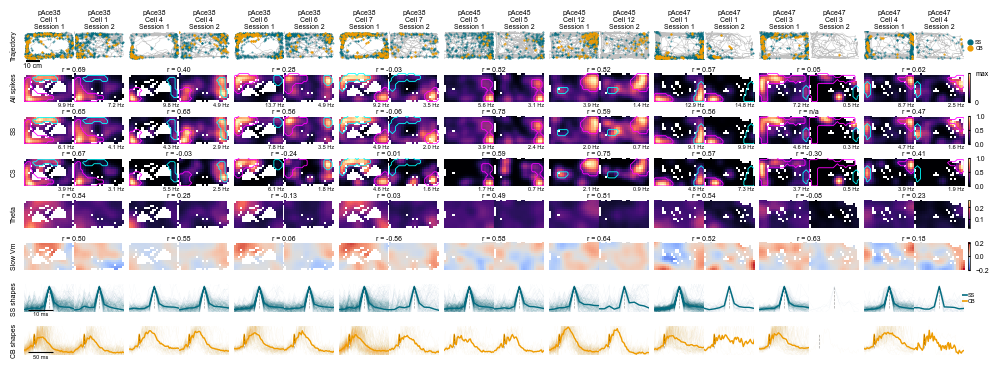

Plotting CS- comparison (n=4, 2 conditions each)
  Rendering CS- part 1/1: n=4 -> spatial_compare_csminus_s1_s2.svg
Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/figures/CKII_pooled/spatial_compare_csminus_s1_s2.svg


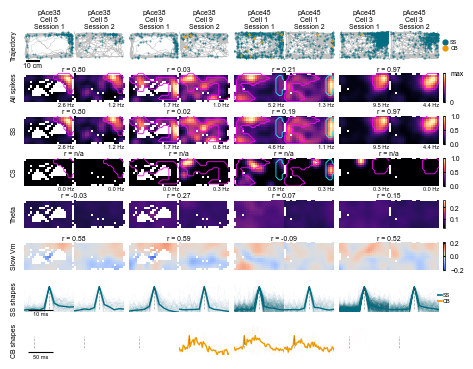

Plotting Non-PLC comparison (n=16, 2 conditions each)
  Rendering Non-PLC part 1/2: n=10 -> spatial_compare_nonplc_s1_s2_part01.svg
pAce45 Cell 6: All spikes PF mask is empty
pAce45 Cell 6: SS PF mask is empty
pAce45 Cell 6: CS PF mask is empty
pAce45 Cell 6: All spikes PF mask is empty
pAce45 Cell 6: SS PF mask is empty
pAce45 Cell 6: CS PF mask is empty
pAce45 Cell 7: All spikes PF mask is empty
pAce45 Cell 7: SS PF mask is empty
pAce45 Cell 7: CS PF mask is empty
pAce45 Cell 7: All spikes PF mask is empty
pAce45 Cell 7: SS PF mask is empty
pAce45 Cell 7: CS PF mask is empty
pAce45 Cell 8: All spikes PF mask is empty
pAce45 Cell 8: SS PF mask is empty
pAce45 Cell 8: CS PF mask is empty
pAce45 Cell 8: All spikes PF mask is empty
pAce45 Cell 8: SS PF mask is empty
pAce45 Cell 8: CS PF mask is empty
pAce45 Cell 9: All spikes PF mask is empty
pAce45 Cell 9: SS PF mask is empty
pAce45 Cell 9: CS PF mask is empty
pAce45 Cell 9: All spikes PF mask is empty
pAce45 Cell 9: SS PF mask is empty

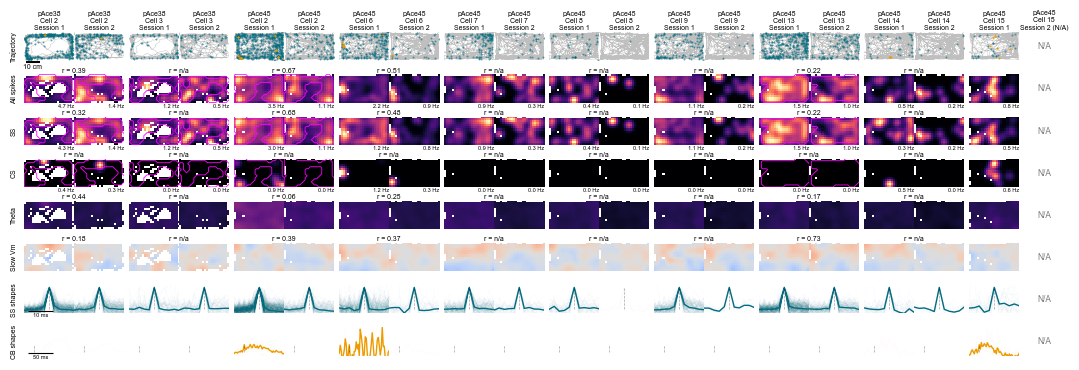

  Rendering Non-PLC part 2/2: n=6 -> spatial_compare_nonplc_s1_s2_part02.svg
pAce46 Cell 6: All spikes PF mask is empty
pAce46 Cell 6: SS PF mask is empty
pAce46 Cell 6: CS PF mask is empty
pAce46 Cell 6: All spikes PF mask is empty
pAce46 Cell 6: SS PF mask is empty
pAce46 Cell 6: CS PF mask is empty
pAce46 Cell 7: All spikes PF mask is empty
pAce46 Cell 7: SS PF mask is empty
pAce46 Cell 7: CS PF mask is empty
pAce46 Cell 7: All spikes PF mask is empty
pAce46 Cell 7: SS PF mask is empty
pAce46 Cell 7: CS PF mask is empty
Saved: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/figures/CKII_pooled/spatial_compare_nonplc_s1_s2_part02.svg


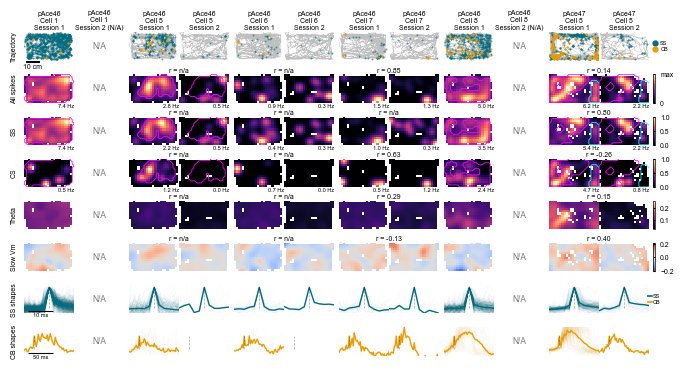

Figure folder: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/figures/CKII_pooled
Panel mode: s1_s2
Saved CS+ figures: 1
Saved CS- figures: 1
Saved Non-PLC figures: 2


In [32]:
session_compare_render = render_session_compare_heatmaps(
    config=config,
    params=session_compare_params,
    groups_payload=session_compare_groups,
)

print(f"Figure folder: {session_compare_render['figure_save_folder']}")
print(f"Panel mode: {session_compare_render['panel_mode']}")
print(f"Saved CS+ figures: {len(session_compare_render['saved_csplus'])}")
print(f"Saved CS- figures: {len(session_compare_render['saved_csminus'])}")
print(f"Saved Non-PLC figures: {len(session_compare_render['saved_nonplc'])}")


# Trial by Trial Analysis, Distance normalized

## Trial by trial plots with distance windowing

In [51]:
distance_centered_params = PFDistanceCenteredParams(
    distance_window_cm=15.0,
    detection_window_cm=10.0,
    distance_bin_cm=1.5,
    distance_mode='cumulative_path',
    center_by_pf_position=True,
    min_traversals=10,
    min_traversals_per_type=5,
    require_full_span=False,
    subtract_pre_traversal_baseline=traversal_params.subtract_pre_traversal_baseline,
    pf_component_selection=traversal_params.pf_component_selection,
    max_pf_distance_cm=traversal_params.max_pf_distance_cm,
    smooth_window=5.0, # cm
    exclude_trials_with_bad_frames=True,
    require_movement=True,
    include_long_cb_as_plateau=True,
    cb_plateau_min_duration_ms=100.0,
)



In [52]:
## Trial by Trial plots + unified distance dataset

distance_defined_distance_window_cm = 15.0 # default 15
distance_defined_detection_window_cm = 8.0
distance_defined_distance_bin_cm = 1.5 # default 1.5
distance_defined_distance_mode = 'euclidean_to_peak'  # alternative: 'euclidean_to_peak'
distance_defined_center_vicinity_min_cm = 1
distance_defined_center_vicinity_max_cm = 5
distance_defined_moving_speed_threshold = float(config.analysis.speed_threshold)
distance_defined_resting_speed_threshold = 0.5
distance_defined_trial_sharey = True
distance_defined_max_plot_trial_duration_s = 20.0

distance_defined_categories = ('CSplus', 'CSminus', 'non-PLC')  # e.g. ('non-PLC',) or ('CSplus','CSminus','non-PLC')

# Related to Plateaus
distance_defined_include_long_cb_as_plateau = False
distance_defined_cb_plateau_min_duration_ms = 100.0
distance_defined_include_resting_plateaus = True

trial_plot_dilation_bins = 0 #place_cell_params.pf_reliability_dilation_bins  # set 0 for no dilation
trial_plot_dilation_shape = place_cell_params.pf_reliability_dilation_shape  # 'disk' | 'square' | 'manhattan'

distance_defined_unified_result = generate_distance_defined_trials_and_dataset(
    config=config,
    spatial_data=spatial_data,
    distance_params=distance_centered_params,
    figure_save_folder=figure_save_folder,
    distance_window_cm=distance_defined_distance_window_cm,
    detection_window_cm=distance_defined_detection_window_cm,
    distance_bin_cm=distance_defined_distance_bin_cm,
    distance_mode=distance_defined_distance_mode,
    center_vicinity_min_cm=distance_defined_center_vicinity_min_cm,
    center_vicinity_max_cm=distance_defined_center_vicinity_max_cm,
    moving_speed_threshold=distance_defined_moving_speed_threshold,
    resting_speed_threshold=distance_defined_resting_speed_threshold,
    pf_ranks=(1, 2),
    categories=distance_defined_categories,
    clear_output=True,
    save_summary_csv=True,
    show_plots=False,
    show_rest_patches=True,
    pf_reliability_dilation_bins=trial_plot_dilation_bins,
    pf_reliability_dilation_shape=trial_plot_dilation_shape,
    trace_slow_gap=1.0,
    theta_slow_pad_factor=0.05,
    sharey=distance_defined_trial_sharey,
    max_plot_trial_duration_s=distance_defined_max_plot_trial_duration_s,
    include_long_cb_as_plateau=distance_defined_include_long_cb_as_plateau,
    cb_plateau_min_duration_ms=distance_defined_cb_plateau_min_duration_ms,
    include_resting_plateaus=distance_defined_include_resting_plateaus
)

distance_defined_trial_summary = distance_defined_unified_result['plot_summary']
distance_centered_dataset = distance_defined_unified_result['dataset']

print('Output folders:')
for cat, out_dir in distance_defined_trial_summary['output_dirs'].items():
    print(f"  {cat}: {out_dir}")
print(f"Summary CSV: {distance_defined_trial_summary['summary_csv']}")
print(distance_defined_trial_summary['counters'])

cats_for_print = tuple(distance_centered_dataset.get('metadata', {}).get('categories', ()))
if len(cats_for_print) == 0:
    cats_for_print = tuple(distance_defined_trial_summary.get('output_dirs', {}).keys())

for cat in cats_for_print:
    cat_data = distance_centered_dataset.get(cat, {})
    p1 = cat_data.get(1, {})
    p2 = cat_data.get(2, {})
    print(f"{cat} PF1: {p1.get('n_entries', 0)} entries (skipped={p1.get('n_skipped', 0)})")
    print(f"{cat} PF2: {p2.get('n_entries', 0)} entries (skipped={p2.get('n_skipped', 0)})")

print('Distance-centered metadata:')
print(distance_centered_dataset.get('metadata', {}))


CKII_pAce21_PR_20250806: SNR filter kept 9/9 cells (threshold=3.0, min_good_minutes=5.0).


/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/utils/placecell_pipeline.py:4464: RuntimeWarning: Mean of empty slice
  "ss_pct_mean": np.nanmean(ss_pct_arr, axis=0) if np.any(np.isfinite(ss_pct_arr)) else np.full(len(distance_rel), np.nan),
/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/utils/placecell_pipeline.py:4465: RuntimeWarning: Mean of empty slice
  "cs_pct_mean": np.nanmean(cs_pct_arr, axis=0) if np.any(np.isfinite(cs_pct_arr)) else np.full(len(distance_rel), np.nan),
/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/utils/placecell_core.py:11027: RuntimeWarning: invalid value encountered in divide
  ss_pct = np.where(valid, 100.0 * ss_seg / denom, np.nan)
/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/utils/placecell_core.py:11028: RuntimeWarning: invalid value encountered in divide
  cs_pct = np.where(valid, 100.0 * cs_s

Plotted 12 traversal trials (11 with spikes in PF, used for average)
CKII_pAce38_PX_20251126: SNR filter kept 9/9 cells (threshold=3.0, min_good_minutes=5.0).
Plotted 28 traversal trials (28 with spikes in PF, used for average)
Plotted 45 traversal trials (45 with spikes in PF, used for average)
Plotted 28 traversal trials (28 with spikes in PF, used for average)
Plotted 41 traversal trials (41 with spikes in PF, used for average)
Plotted 41 traversal trials (40 with spikes in PF, used for average)
Plotted 24 traversal trials (24 with spikes in PF, used for average)
Plotted 25 traversal trials (25 with spikes in PF, used for average)
Plotted 42 traversal trials (42 with spikes in PF, used for average)
CKII_pAce45_PX_20260118: SNR filter kept 15/16 cells (threshold=3.0, min_good_minutes=5.0).
Plotted 40 traversal trials (38 with spikes in PF, used for average)
Plotted 50 traversal trials (46 with spikes in PF, used for average)
CKII_pAce47_PX_20260128: SNR filter kept 5/5 cells (thresho

/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/utils/placecell_pipeline.py:4459: RuntimeWarning: Mean of empty slice
  "theta_mean": np.nanmean(theta_arr, axis=0),
/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/utils/placecell_pipeline.py:4460: RuntimeWarning: Mean of empty slice
  "slow_mean": np.nanmean(slow_arr, axis=0),
/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/utils/placecell_pipeline.py:4461: RuntimeWarning: Mean of empty slice
  "rate_mean": np.nanmean(rate_arr, axis=0),
/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/utils/placecell_pipeline.py:4462: RuntimeWarning: Mean of empty slice
  "ss_rate_mean": np.nanmean(ss_rate_arr, axis=0),
/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/utils/placecell_pipeline.py:4463: RuntimeWarning: Mean of empty slice
  "cs_rate_mean": np.nanmea

Plotted 7 traversal trials (7 with spikes in PF, used for average)
Plotted 10 traversal trials (9 with spikes in PF, used for average)
Plotted 7 traversal trials (7 with spikes in PF, used for average)
Plotted 5 traversal trials (5 with spikes in PF, used for average)
Plotted 43 traversal trials (42 with spikes in PF, used for average)
Plotted 32 traversal trials (31 with spikes in PF, used for average)
Plotted 45 traversal trials (37 with spikes in PF, used for average)
Plotted 34 traversal trials (33 with spikes in PF, used for average)
Plotted 34 traversal trials (32 with spikes in PF, used for average)
Plotted 51 traversal trials (50 with spikes in PF, used for average)
Plotted 24 traversal trials (22 with spikes in PF, used for average)
Plotted 34 traversal trials (20 with spikes in PF, used for average)
Plotted 34 traversal trials (21 with spikes in PF, used for average)
Plotted 30 traversal trials (30 with spikes in PF, used for average)
CKII_pAce46_PR_20260222: SNR filter kept 

In [53]:
if distance_centered_dataset is None:
    print("distance_centered_dataset is None. Run '# Trial by Trial Analysis, Distance normalized, new' first.")
else:
    print("Distance-centered trial counts by category and PF rank (per cell):")
    for cat in ["CSplus", "CSminus"]:
        cat_block = distance_centered_dataset.get(cat, {})
        pf1_entries = list(cat_block.get(1, {}).get("entries", []))
        pf2_entries = list(cat_block.get(2, {}).get("entries", []))

        pf1_by_key = {}
        for e in pf1_entries:
            key = (str(e.get("session", "")), int(e.get("cell_idx", -1)))
            n = e.get("data", {}).get("all", {}).get("n_trials", 0)
            try:
                pf1_by_key[key] = int(n)
            except Exception:
                pf1_by_key[key] = 0

        pf2_by_key = {}
        for e in pf2_entries:
            key = (str(e.get("session", "")), int(e.get("cell_idx", -1)))
            n = e.get("data", {}).get("all", {}).get("n_trials", 0)
            try:
                pf2_by_key[key] = int(n)
            except Exception:
                pf2_by_key[key] = 0

        all_keys = sorted(set(pf1_by_key.keys()) | set(pf2_by_key.keys()), key=lambda x: (x[0], x[1]))

        print(f"\n{cat}:")
        total_pf1 = 0
        total_pf2 = 0
        for session_name, cell_idx in all_keys:
            n1 = int(pf1_by_key.get((session_name, cell_idx), 0))
            n2 = int(pf2_by_key.get((session_name, cell_idx), 0))
            total_pf1 += n1
            total_pf2 += n2
            print(f"  {session_name} Cell{cell_idx + 1}: PF1 trials={n1}, PF2 trials={n2}")

        print(f"  Total: PF1 trials={total_pf1}, PF2 trials={total_pf2}")
        print(f"  n_cells listed={len(all_keys)}")


Distance-centered trial counts by category and PF rank (per cell):

CSplus:
  CKII_pAce21_PR_20250806 Cell3: PF1 trials=12, PF2 trials=0
  CKII_pAce38_PX_20251126 Cell1: PF1 trials=28, PF2 trials=45
  CKII_pAce38_PX_20251126 Cell4: PF1 trials=28, PF2 trials=41
  CKII_pAce38_PX_20251126 Cell6: PF1 trials=41, PF2 trials=24
  CKII_pAce38_PX_20251126 Cell7: PF1 trials=25, PF2 trials=42
  CKII_pAce45_PX_20260118 Cell5: PF1 trials=40, PF2 trials=0
  CKII_pAce45_PX_20260118 Cell12: PF1 trials=50, PF2 trials=0
  CKII_pAce47_PX_20260128 Cell1: PF1 trials=36, PF2 trials=30
  CKII_pAce47_PX_20260128 Cell3: PF1 trials=26, PF2 trials=29
  CKII_pAce47_PX_20260128 Cell4: PF1 trials=26, PF2 trials=23
  CKII_pAce50_PRL_20260317 Cell3: PF1 trials=7, PF2 trials=0
  CKII_pAce50_PRL_20260317 Cell9: PF1 trials=10, PF2 trials=0
  Total: PF1 trials=329, PF2 trials=234
  n_cells listed=12

CSminus:
  CKII_pAce21_PR_20250806 Cell1: PF1 trials=7, PF2 trials=0
  CKII_pAce21_PR_20250806 Cell5: PF1 trials=5, PF2 tr

## Compare Sessions

### Heatmaps comparing two sessions

In [54]:
smooth_window = 3.0 # cm
avg_smooth_window = 0.0 # cm
max_peak_adjust_cm_pf1 = 6.0 # cm
max_peak_adjust_cm_pf2 = 6.0 # cm
distance_centered_display_xlim = (-15.0, 15.0)

two_session_split_mode = 'time_windows'
two_session_split_window_minutes = 5.0  # set to 5.0 for first/second 5 min windows

In [55]:
if distance_centered_dataset is None:
    print("distance_centered_dataset is None. Run '# Trial by Trial Analysis, Distance normalized, new' first.")
else:
    distance_heatmap_summary_2sessions = generate_pf_distance_centered_component_heatmaps_2sessions(
        dataset=distance_centered_dataset,
        figure_save_folder=figure_save_folder,
        clear_output=True,
        smooth_window=smooth_window,
        fr_vmax_scale=0.2,
        theta_vlim=(0, 0.4),
        slow_vlim=(-0.4, 0.4),
        fig_width=1,
        trial_height=0.025,
        xlim=distance_centered_display_xlim,
        merge_ss_cs=True,
        merge_plateau=True,
        smooth_plateau=False,
        plateau_vlim=0.01,
        avg_smooth_window=avg_smooth_window,
        max_peak_adjust_cm_pf1=max_peak_adjust_cm_pf1,
        max_peak_adjust_cm_pf2=max_peak_adjust_cm_pf2,
        avg_ylim_focus_window=(-1.0, 1.0),
        disable_pf2_avg_ylim_sync=True,
        split_mode=two_session_split_mode,
        split_window_minutes=two_session_split_window_minutes,
        print_peak_shift_bins=True,
        show_plot=False,
    )

    for cat, info in distance_heatmap_summary_2sessions.items():
        print(f"{cat} folder (2 sessions): {info['output_dir']}")
        print(f"{cat} summary (2 sessions): {info}")


/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/utils/placecell_pipeline.py:9628: RuntimeWarning: Mean of empty slice
  sess = _session_idx_for_n(actual_trials)
/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/utils/placecell_pipeline.py:9634: RuntimeWarning: Mean of empty slice
  return float(int(changes[0]) + 1) + 0.5
/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/utils/placecell_pipeline.py:9617: RuntimeWarning: Mean of empty slice
  
/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/utils/placecell_pipeline.py:10423: RuntimeWarning: Mean of empty slice
  if out_path is not None:
/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/utils/placecell_pipeline.py:10116: RuntimeWarning: Mean of empty slice
  if np.isfinite(vmax) and vmax > 0:
/opt/homebrew/Caskroom/miniforge/base/envs/AdamLab/lib/python

[CSplus] per-cell peak shifts (distance bin = 1.5 cm):
  CKII_pAce21_PR_20250806 Cell 3: PF1=+1 bins (+1.50 cm), PF2=NA
  CKII_pAce38_PX_20251126 Cell 1: PF1=+0 bins (+0.00 cm), PF2=-1 bins (-1.50 cm)
  CKII_pAce38_PX_20251126 Cell 4: PF1=-1 bins (-1.50 cm), PF2=-1 bins (-1.50 cm)
  CKII_pAce38_PX_20251126 Cell 6: PF1=+2 bins (+3.00 cm), PF2=+1 bins (+1.50 cm)
  CKII_pAce38_PX_20251126 Cell 7: PF1=+0 bins (+0.00 cm), PF2=+1 bins (+1.50 cm)
  CKII_pAce45_PX_20260118 Cell 5: PF1=-1 bins (-1.50 cm), PF2=NA
  CKII_pAce45_PX_20260118 Cell 12: PF1=-1 bins (-1.50 cm), PF2=NA
  CKII_pAce47_PX_20260128 Cell 1: PF1=-1 bins (-1.50 cm), PF2=-2 bins (-3.00 cm)
  CKII_pAce47_PX_20260128 Cell 3: PF1=-3 bins (-4.50 cm), PF2=-1 bins (-1.50 cm)
  CKII_pAce47_PX_20260128 Cell 4: PF1=+0 bins (+0.00 cm), PF2=-1 bins (-1.50 cm)
  CKII_pAce50_PRL_20260317 Cell 3: PF1=+2 bins (+3.00 cm), PF2=NA
  CKII_pAce50_PRL_20260317 Cell 9: PF1=+0 bins (+0.00 cm), PF2=NA
[CSminus] per-cell peak shifts (distance bin = 1.5

/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/utils/placecell_pipeline.py:10510: RuntimeWarning: Mean of empty slice
  trial_height=trial_height,


[CSplus] 4/12 saved: CKII_pAce38_PX_20251126_Cell6_heatmap_2sessions.svg
[CSplus] 5/12 saved: CKII_pAce38_PX_20251126_Cell7_heatmap_2sessions.svg
[CSplus] 6/12 saved: CKII_pAce45_PX_20260118_Cell5_heatmap_2sessions.svg
[CSplus] 7/12 saved: CKII_pAce45_PX_20260118_Cell12_heatmap_2sessions.svg
[CSplus] 8/12 saved: CKII_pAce47_PX_20260128_Cell1_heatmap_2sessions.svg
[CSplus] 9/12 saved: CKII_pAce47_PX_20260128_Cell3_heatmap_2sessions.svg
[CSplus] 10/12 saved: CKII_pAce47_PX_20260128_Cell4_heatmap_2sessions.svg
[CSplus] 11/12 saved: CKII_pAce50_PRL_20260317_Cell3_heatmap_2sessions.svg
[CSplus] 12/12 saved: CKII_pAce50_PRL_20260317_Cell9_heatmap_2sessions.svg
[CSminus] output folder: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/pf_centered_2sessions_CSminus_heatmaps
[CSminus] 1/8 saved: CKII_pAce21_PR_20250806_Cell1_heatmap_2sessions.svg
[CSminus] 2/8 saved: CKII_pAce21_PR_20250806_Cell5_heatmap_2sessions.svg
[CSminus] 3/8 saved:

/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/utils/placecell_pipeline.py:133: RuntimeWarning: Mean of empty slice
  
/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/utils/placecell_pipeline.py:146: RuntimeWarning: Mean of empty slice
  subtract_pre_traversal_baseline: bool = True


In [56]:
# Trial-count diagnostics from 2-session average exports
import pandas as pd
from pathlib import Path

trial_count_threshold = 4
export_root_2sessions = Path(figure_save_folder) / 'pf_distance_centered_2sessions_average_exports'

if distance_centered_dataset is None:
    print("distance_centered_dataset is None. Run '# Trial by Trial Analysis, Distance normalized, new' first.")
else:
    for cat in ("CSplus", "CSminus"):
        index_csv = export_root_2sessions / cat / 'session_averages_pre_post_index.csv'
        print(f"\n[{cat}] export index: {index_csv}")
        if not index_csv.exists():
            print("  Missing export index CSV. Run generate_pf_distance_centered_component_heatmaps_2sessions first.")
            continue

        df = pd.read_csv(index_csv)
        required_cols = [
            'animal_id', 'cell_idx', 'cell_num',
            'n_trials_pf1_s1', 'n_trials_pf1_s2', 'n_trials_pf2_s1', 'n_trials_pf2_s2',
        ]
        missing = [c for c in required_cols if c not in set(df.columns)]
        if len(missing) > 0:
            print(f"  Missing columns in export CSV: {missing}")
            continue

        for c in ['n_trials_pf1_s1', 'n_trials_pf1_s2', 'n_trials_pf2_s1', 'n_trials_pf2_s2', 'cell_num', 'cell_idx']:
            df[c] = pd.to_numeric(df[c], errors='coerce')

        df = df.sort_values(['animal_id', 'cell_num', 'cell_idx'], na_position='last').reset_index(drop=True)

        print("  Per-cell trial counts:")
        for _, r in df.iterrows():
            cell_label = int(r['cell_num']) if pd.notna(r['cell_num']) else int(r['cell_idx']) + 1
            print(
                f"    {r['animal_id']}_Cell{cell_label}: "
                f"PF1 S1={int(r['n_trials_pf1_s1']) if pd.notna(r['n_trials_pf1_s1']) else 'NaN'}, "
                f"PF1 S2={int(r['n_trials_pf1_s2']) if pd.notna(r['n_trials_pf1_s2']) else 'NaN'}, "
                f"PF2 S1={int(r['n_trials_pf2_s1']) if pd.notna(r['n_trials_pf2_s1']) else 'NaN'}, "
                f"PF2 S2={int(r['n_trials_pf2_s2']) if pd.notna(r['n_trials_pf2_s2']) else 'NaN'}"
            )

        pf1_both = ((df['n_trials_pf1_s1'] >= trial_count_threshold) & (df['n_trials_pf1_s2'] >= trial_count_threshold)).sum()
        pf2_both = ((df['n_trials_pf2_s1'] >= trial_count_threshold) & (df['n_trials_pf2_s2'] >= trial_count_threshold)).sum()
        print(f"  Summary (>={trial_count_threshold} in both sessions): PF1={int(pf1_both)}, PF2={int(pf2_both)}")



[CSplus] export index: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/pf_distance_centered_2sessions_average_exports/CSplus/session_averages_pre_post_index.csv
  Per-cell trial counts:
    CKII_pAce21_PR_20250806_Cell3: PF1 S1=7, PF1 S2=5, PF2 S1=0, PF2 S2=0
    CKII_pAce38_PX_20251126_Cell1: PF1 S1=10, PF1 S2=5, PF2 S1=11, PF2 S2=8
    CKII_pAce38_PX_20251126_Cell4: PF1 S1=9, PF1 S2=5, PF2 S1=11, PF2 S2=6
    CKII_pAce38_PX_20251126_Cell6: PF1 S1=11, PF1 S2=6, PF2 S1=12, PF2 S2=6
    CKII_pAce38_PX_20251126_Cell7: PF1 S1=11, PF1 S2=6, PF2 S1=11, PF2 S2=6
    CKII_pAce45_PX_20260118_Cell5: PF1 S1=14, PF1 S2=7, PF2 S1=0, PF2 S2=0
    CKII_pAce45_PX_20260118_Cell12: PF1 S1=14, PF1 S2=12, PF2 S1=0, PF2 S2=0
    CKII_pAce47_PX_20260128_Cell1: PF1 S1=15, PF1 S2=11, PF2 S1=14, PF2 S2=11
    CKII_pAce47_PX_20260128_Cell3: PF1 S1=11, PF1 S2=9, PF2 S1=8, PF2 S2=13
    CKII_pAce47_PX_20260128_Cell4: PF1 S1=10, PF1 S2=12, PF2 S1=10, PF2

### Average Plot, comparing two sessisons

/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/utils/placecell_pipeline.py:91: RuntimeWarning: Mean of empty slice
  slow_freqs: float = 2.0
/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/utils/placecell_pipeline.py:12140: RuntimeWarning: Mean of empty slice
  min_trials_per_column=min_trials_per_column,


[CS+ PLCs] n (PF1): combined=10, S1=10, S2=10
[CS+ PLCs] n (PF2): combined=7, S1=7, S2=7


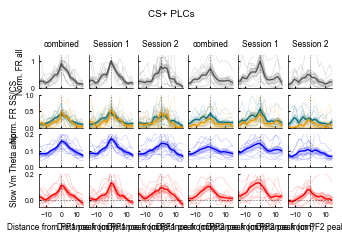

Generated: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/pf_distance_centered_CSplus_average_primary_secondary_2sessions.svg
[CS- PLCs] n (PF1): combined=6, S1=6, S2=6
[CS- PLCs] n (PF2): combined=3, S1=3, S2=3


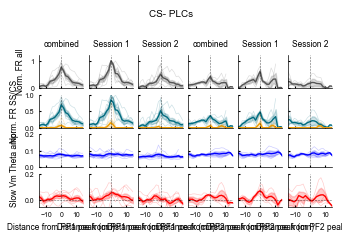

Generated: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/pf_distance_centered_CSminus_average_primary_secondary_2sessions.svg


In [57]:
if distance_centered_dataset is None:
    print("distance_centered_dataset is None. Run '# Trial by Trial Analysis, Distance normalized, new' first.")
else:
    # Shared parameters for both CS+ and CS- 2-session average plots
    pf_avg_fr_row_ylim_max = 1.2
    min_trials_per_column_2sessions = 4  # include only if n_trials >= this threshold in that column
    average_export_dir_2sessions = os.path.join(figure_save_folder, 'pf_distance_centered_2sessions_average_exports')

    common_plot_kwargs = dict(
        smooth_window=smooth_window,
        plot_trials=True,
        trial_alpha=0.2,
        trial_linewidth=0.5,
        theta_ylim=(0, 0.2),
        slow_ylim=(-0.05, 0.2),
        fr_ylim_scale=1.2,
        ss_cs_ylim_scale=1.2,
        figsize_per_block=(3.4, 1.8),
        xlim=distance_centered_display_xlim,
        fr_row_ylim_max=pf_avg_fr_row_ylim_max,
        show_plot=True,
        max_peak_adjust_cm_pf1=max_peak_adjust_cm_pf1,
        max_peak_adjust_cm_pf2=max_peak_adjust_cm_pf2,
        min_traversals_per_type=distance_centered_params.min_traversals_per_type,
        min_trials_per_column=min_trials_per_column_2sessions,
        use_saved_average_exports=True,
        average_export_dir=average_export_dir_2sessions,
        average_export_stage='post',
        enforce_min_traversals_on_saved_exports=False,
        fr_norm_reference_col='session1',
        split_mode=two_session_split_mode,
        split_window_minutes=two_session_split_window_minutes,
    )

    plot_specs_2sessions = [
        ('CSplus', 'CS+ PLCs', 'pf_distance_centered_CSplus_average_primary_secondary_2sessions.svg'),
        ('CSminus', 'CS- PLCs', 'pf_distance_centered_CSminus_average_primary_secondary_2sessions.svg'),
    ]

    for category_name, title_text, filename in plot_specs_2sessions:
        out_path = os.path.join(figure_save_folder, filename)
        plot_pf_distance_centered_category_primary_secondary_from_dataset_2sessions(
            dataset=distance_centered_dataset,
            category=category_name,
            title=title_text,
            out_path=out_path,
            **common_plot_kwargs,
        )
        print(f'Generated: {out_path}')


### Statistics

In [58]:
### Stability
stability_min_traversals_per_session = 0
stability_smooth_window_cm = 0.0
stability_auc_window_cm = None
stability_slow_auc_window_cm = (-10.0, 10.0)
stability_min_trials_per_column_2sessions = min_trials_per_column_2sessions
stability_average_export_dir_2sessions = average_export_dir_2sessions
stability_figsize = None  # e.g. (5.0, 6.5)
stability_row_height = 1.2
stability_figsize = (2.7, 2.3)  

if distance_centered_dataset is None:
    print("distance_centered_dataset is None. Run '# Trial by Trial Analysis, Distance normalized, new' first.")
else:
    stability_results = compute_pf_distance_centered_session_stability(
        distance_centered_dataset,
        min_traversals_per_session=stability_min_traversals_per_session,
        smooth_window_cm=stability_smooth_window_cm,
        auc_window_cm=stability_auc_window_cm,
        slow_auc_window_cm=stability_slow_auc_window_cm,
        min_trials_per_column_2sessions=stability_min_trials_per_column_2sessions,
        average_export_dir=stability_average_export_dir_2sessions,
        split_mode=two_session_split_mode,
        split_window_minutes=two_session_split_window_minutes,
        strict_follow_plot_inclusion=True,
        print_nan_diagnostics=True,
    )

    print(f"Skipped counts: {stability_results.get('skipped_counts', {})}")

    per_cell_stability = stability_results.get("per_cell_stability", None)
    if per_cell_stability is not None and len(per_cell_stability) > 0:
        print("\nDisplayed cell counts by metric/group:")
        count_cols = {
            "r": "r",
            "peak_shift": "delta_peak_x_cm",
            "auc_ratio": "auc_ratio",
        }
        for metric_name in ["all_spike", "ss", "cs", "theta", "slow"]:
            sub_metric = per_cell_stability[per_cell_stability["metric"] == metric_name].copy()
            if len(sub_metric) == 0:
                continue
            print(f"  {metric_name}:")
            for stat_label, stat_col in count_cols.items():
                if stat_col not in set(sub_metric.columns):
                    continue
                sub_stat = sub_metric.copy()
                if stat_col == "delta_peak_x_cm":
                    sub_stat[stat_col] = sub_stat[stat_col].abs()
                sub_stat = sub_stat[sub_stat[stat_col].notna()]
                # CS row is plotted without CS- PF1 in the current figure.
                if metric_name == "cs":
                    sub_stat = sub_stat[sub_stat["group"].isin(["CSplus_PF1", "CSplus_PF2"])]
                sub_stat["cell_key"] = (
                    sub_stat["animal_id"].astype(str) + "::" + sub_stat["cell_idx"].astype(int).astype(str)
                )
                counts = (
                    sub_stat.groupby("group")["cell_key"]
                    .nunique()
                    .reindex(["CSplus_PF1", "CSplus_PF2", "CSminus_PF1"])
                    .fillna(0)
                    .astype(int)
                )
                print(
                    f"    {stat_label}: "
                    f"CS+ PF1={counts.get('CSplus_PF1', 0)}, "
                    f"CS+ PF2={counts.get('CSplus_PF2', 0)}, "
                    f"CS- PF1={counts.get('CSminus_PF1', 0)}"
                )

    stability_plot_summary = plot_pf_distance_centered_session_stability(
        stability_results,
        figure_save_folder=figure_save_folder,
        figsize=stability_figsize,
        row_height=stability_row_height,
        show_plot=False,
        save_csv=True, 
    )

    print("Stability outputs:")
    print(f"  Per-cell CSV: {stability_plot_summary.get('per_cell_csv')}")
    print(f"  Stats CSV: {stability_plot_summary.get('stats_csv')}")
    for metric_name, fig_path in stability_plot_summary.get('figure_paths', {}).items():
        print(f"  {metric_name}: {fig_path}")


[session_stability] Cells/metrics with NaN values (flat/invalid traces):
  group=CSminus_PF1, metric=cs, cell=CKII_pAce38_PX_20251126_Cell5, n_s1=12, n_s2=7, overlap_bins=21, auc_bins=21, peak_bins=13, reasons=r:flat_trace_both_sessions; r_set_to_zero; auc_ratio:zero_or_invalid_auc_session1; peak_ratio:zero_or_invalid_peak_session1; peak_abs_sym_diff:zero_or_invalid_peak_sum
  group=CSminus_PF1, metric=cs, cell=CKII_pAce38_PX_20251126_Cell9, n_s1=12, n_s2=6, overlap_bins=19, auc_bins=19, peak_bins=13, reasons=r:flat_trace_both_sessions; r_set_to_zero; auc_ratio:zero_or_invalid_auc_session1; peak_ratio:zero_or_invalid_peak_session1; peak_abs_sym_diff:zero_or_invalid_peak_sum
  group=CSminus_PF1, metric=cs, cell=CKII_pAce45_PX_20260118_Cell3, n_s1=15, n_s2=10, overlap_bins=19, auc_bins=19, peak_bins=13, reasons=r:flat_trace_both_sessions; r_set_to_zero; auc_ratio:zero_or_invalid_auc_session1; peak_ratio:zero_or_invalid_peak_session1; peak_abs_sym_diff:zero_or_invalid_peak_sum
  group=CSm

In [59]:
# SS/CS PF1/PF2 summary for absolute normalized FR change
import importlib
import utils.placecell_pipeline as _pcp
importlib.reload(_pcp)

if 'stability_results' not in locals() or stability_results is None:
    print("stability_results not found. Run the Stability cell first.")
else:
    ss_cs_peak_change_summary = _pcp.plot_pf_distance_centered_abs_norm_fr_change_ss_cs(
        stability_results,
        figure_save_folder=figure_save_folder,
        out_name='pf_distance_centered_abs_norm_fr_change_ss_cs.svg',
        figsize=(0.9, 2.0),
        show_plot=False,
        save_csv=True,
    )
    print('Generated figure:', ss_cs_peak_change_summary.get('figure'))
    print('Stats CSV:', ss_cs_peak_change_summary.get('stats_csv'))
    print('n (SS PF1 vs CS PF1):', ss_cs_peak_change_summary.get('n_ss_pf1_vs_cs_pf1'))
    print('n (SS PF2 vs CS PF2):', ss_cs_peak_change_summary.get('n_ss_pf2_vs_cs_pf2'))
    print('n (SS PF1 vs SS PF2):', ss_cs_peak_change_summary.get('n_ss_pf1_vs_ss_pf2'))
    print('n (CS PF1 vs CS PF2):', ss_cs_peak_change_summary.get('n_cs_pf1_vs_cs_pf2'))
    print('n (ratio SS PF1 vs CS PF1):', ss_cs_peak_change_summary.get('n_ratio_ss_pf1_vs_cs_pf1'))
    print('n (ratio SS PF2 vs CS PF2):', ss_cs_peak_change_summary.get('n_ratio_ss_pf2_vs_cs_pf2'))
    print('n (ratio SS PF1 vs SS PF2):', ss_cs_peak_change_summary.get('n_ratio_ss_pf1_vs_ss_pf2'))
    print('n (ratio CS PF1 vs CS PF2):', ss_cs_peak_change_summary.get('n_ratio_cs_pf1_vs_cs_pf2'))


Generated figure: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/pf_distance_centered_abs_norm_fr_change_ss_cs.svg
Stats CSV: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/pf_distance_centered_abs_norm_fr_change_ss_cs_stats.csv
n (SS PF1 vs CS PF1): 10
n (SS PF2 vs CS PF2): 7
n (SS PF1 vs SS PF2): 7
n (CS PF1 vs CS PF2): 7
n (ratio SS PF1 vs CS PF1): 10
n (ratio SS PF2 vs CS PF2): 7
n (ratio SS PF1 vs SS PF2): 7
n (ratio CS PF1 vs CS PF2): 7


## Compare directions

In [60]:
# Compare directions: heatmaps
direction_avg_mode = "S1"  # combined, S1, or S2
direction_smooth_window = smooth_window  # cm
direction_avg_smooth_window = avg_smooth_window  # cm
direction_max_peak_adjust_cm_pf1 = max_peak_adjust_cm_pf1  # cm
direction_max_peak_adjust_cm_pf2 = max_peak_adjust_cm_pf2  # cm
direction_average_export_subdir = 'pf_distance_centered_2directions_average_exports'


### Heatmaps comparing CW and CCW

In [61]:
if distance_centered_dataset is None:
    print("distance_centered_dataset is None. Run '# Trial by Trial Analysis, Distance normalized, new' first.")
else:
    distance_heatmap_summary_2directions = generate_pf_distance_centered_component_heatmaps_2directions(
        dataset=distance_centered_dataset,
        figure_save_folder=figure_save_folder,
        clear_output=True,
        smooth_window=direction_smooth_window,
        fr_vmax_scale=0.2,
        theta_vlim=(0, 0.4),
        slow_vlim=(-0.4, 0.4),
        fig_width=3,
        trial_height=0.01,
        xlim=distance_centered_display_xlim,
        merge_ss_cs=True,
        merge_plateau=True,
        smooth_plateau=False,
        plateau_vlim=0.01,
        avg_smooth_window=direction_avg_smooth_window,
        max_peak_adjust_cm_pf1=direction_max_peak_adjust_cm_pf1,
        max_peak_adjust_cm_pf2=direction_max_peak_adjust_cm_pf2,
        avg_mode=direction_avg_mode,
        save_average_exports=True,
        average_export_subdir=direction_average_export_subdir,
        print_peak_shift_bins=True,
        show_plot=False,
    )

    for cat, info in distance_heatmap_summary_2directions.items():
        print(f"{cat} folder (2 directions): {info['output_dir']}")
        print(f"{cat} summary (2 directions): {info}")


[CSplus] per-cell peak shifts (distance bin = 1.5 cm):
  CKII_pAce21_PR_20250806 Cell 3: PF1=+1 bins (+1.50 cm), PF2=NA
  CKII_pAce38_PX_20251126 Cell 1: PF1=+0 bins (+0.00 cm), PF2=-1 bins (-1.50 cm)
  CKII_pAce38_PX_20251126 Cell 4: PF1=-1 bins (-1.50 cm), PF2=-1 bins (-1.50 cm)
  CKII_pAce38_PX_20251126 Cell 6: PF1=+2 bins (+3.00 cm), PF2=-2 bins (-3.00 cm)
  CKII_pAce38_PX_20251126 Cell 7: PF1=+0 bins (+0.00 cm), PF2=-1 bins (-1.50 cm)
  CKII_pAce45_PX_20260118 Cell 5: PF1=-1 bins (-1.50 cm), PF2=NA
  CKII_pAce45_PX_20260118 Cell 12: PF1=-4 bins (-6.00 cm), PF2=NA
  CKII_pAce47_PX_20260128 Cell 1: PF1=-2 bins (-3.00 cm), PF2=-2 bins (-3.00 cm)
  CKII_pAce47_PX_20260128 Cell 3: PF1=+0 bins (+0.00 cm), PF2=-1 bins (-1.50 cm)
  CKII_pAce47_PX_20260128 Cell 4: PF1=-1 bins (-1.50 cm), PF2=-1 bins (-1.50 cm)
  CKII_pAce50_PRL_20260317 Cell 3: PF1=+1 bins (+1.50 cm), PF2=NA
  CKII_pAce50_PRL_20260317 Cell 9: PF1=+0 bins (+0.00 cm), PF2=NA
[CSminus] per-cell peak shifts (distance bin = 1.5

/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/utils/placecell_pipeline.py:11500: RuntimeWarning: Mean of empty slice
  cat_dir.mkdir(parents=True, exist_ok=True)
/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/utils/placecell_pipeline.py:8180: RuntimeWarning: Mean of empty slice
  mean_trace = _smooth_avg(np.nanmean(stack, axis=0))
/opt/homebrew/Caskroom/miniforge/base/envs/AdamLab/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/utils/placecell_pipeline.py:8110: RuntimeWarning: Mean of empty slice
  ss_mean = _smooth_avg(np.nanmean(ss_stack, axis=0))
/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/utils/placecell_pipeline.py:8119: RuntimeWarning: Mean of

[CSplus] 1/12 saved: CKII_pAce21_PR_20250806_Cell3_heatmap_2directions.svg
[CSplus] 2/12 saved: CKII_pAce38_PX_20251126_Cell1_heatmap_2directions.svg
[CSplus] 3/12 saved: CKII_pAce38_PX_20251126_Cell4_heatmap_2directions.svg
[CSplus] 4/12 saved: CKII_pAce38_PX_20251126_Cell6_heatmap_2directions.svg
[CSplus] 5/12 saved: CKII_pAce38_PX_20251126_Cell7_heatmap_2directions.svg
[CSplus] 6/12 saved: CKII_pAce45_PX_20260118_Cell5_heatmap_2directions.svg
[CSplus] 7/12 saved: CKII_pAce45_PX_20260118_Cell12_heatmap_2directions.svg
[CSplus] 8/12 saved: CKII_pAce47_PX_20260128_Cell1_heatmap_2directions.svg
[CSplus] 9/12 saved: CKII_pAce47_PX_20260128_Cell3_heatmap_2directions.svg
[CSplus] 10/12 saved: CKII_pAce47_PX_20260128_Cell4_heatmap_2directions.svg
[CSplus] 11/12 saved: CKII_pAce50_PRL_20260317_Cell3_heatmap_2directions.svg
[CSplus] 12/12 saved: CKII_pAce50_PRL_20260317_Cell9_heatmap_2directions.svg
[CSminus] output folder: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_Plac

/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/utils/placecell_pipeline.py:11488: RuntimeWarning: Mean of empty slice
  tr = np.asarray(np.nanmean(sub, axis=0), dtype=float)


CSplus folder (2 directions): /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/pf_centered_2directions_CSplus_heatmaps
CSplus summary (2 directions): {'output_dir': '/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/pf_centered_2directions_CSplus_heatmaps', 'n_primary_entries': 12, 'n_secondary_entries': 7, 'n_union_entries': 12, 'n_pf2_only_entries': 0, 'n_saved_files': 12, 'n_dual_pf_files': 7, 'mode': 'direction_heatmap_with_avg_mode', 'avg_mode': 's1', 'average_export_dir': '/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/pf_distance_centered_2directions_average_exports/CSplus', 'average_export_index_csv': '/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/pf_distance_centered_2directions_average_exports/CSplus/session_averages_pre_post_index.csv', 'n_ave

### Grand Average, comparing directions


PF1 counts: All (n=12), Pref (n=12), Non-pref (n=12)

/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/utils/placecell_pipeline.py:12718: RuntimeWarning: Mean of empty slice
  dir_data["ss_pct_mean"] = np.nanmean(ss_pct, axis=0) if ss_pct.size > 0 else np.full(n_time, np.nan, dtype=float)
/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/utils/placecell_pipeline.py:12719: RuntimeWarning: Mean of empty slice
  dir_data["cs_pct_mean"] = np.nanmean(cs_pct, axis=0) if cs_pct.size > 0 else np.full(n_time, np.nan, dtype=float)
/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/utils/placecell_pipeline.py:8703: RuntimeWarning: Mean of empty slice
  trace = np.nanmean(stack, axis=0)



PF2 counts: All (n=12), Pref (n=7), Non-pref (n=7)


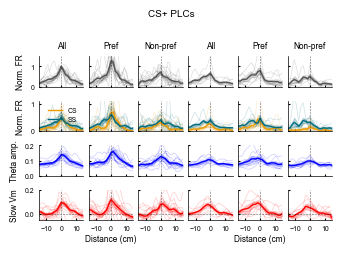

Generated: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/pf_distance_centered_CSplus_average_primary_secondary_2directions.svg
PF1 counts: All (n=8), Pref (n=8), Non-pref (n=8)
PF2 counts: All (n=8), Pref (n=3), Non-pref (n=3)


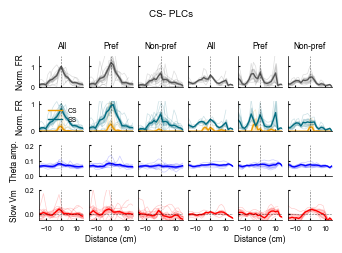

Generated: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/pf_distance_centered_CSminus_average_primary_secondary_2directions.svg


In [62]:
if distance_centered_dataset is None:
    print("distance_centered_dataset is None. Run '# Trial by Trial Analysis, Distance normalized, new' first.")
else:
    direction_avg_out_cs_plus = os.path.join(figure_save_folder, 'pf_distance_centered_CSplus_average_primary_secondary_2directions.svg')
    direction_avg_out_cs_minus = os.path.join(figure_save_folder, 'pf_distance_centered_CSminus_average_primary_secondary_2directions.svg')
    direction_average_export_dir = os.path.join(figure_save_folder, direction_average_export_subdir)
    direction_ss_cs_row_ylim_max = 1.1

    direction_common_plot_kwargs = dict(
        smooth_window=direction_smooth_window,
        avg_smooth_window=direction_avg_smooth_window,
        plot_trials=True,
        trial_alpha=0.2,
        trial_linewidth=0.5,
        theta_ylim=(0, 0.2),
        slow_ylim=(-0.05, 0.2),
        fr_ylim_scale=1.2,
        ss_cs_ylim_scale=1.2,
        figsize_per_block=(3.4, 2.4),
        xlim=distance_centered_display_xlim,
        fr_row_ylim_max=1.5,
        ss_cs_row_ylim_max=direction_ss_cs_row_ylim_max,
        max_peak_adjust_cm_pf1=direction_max_peak_adjust_cm_pf1,
        max_peak_adjust_cm_pf2=direction_max_peak_adjust_cm_pf2,
        min_traversals_per_type=distance_centered_params.min_traversals_per_type,
        use_saved_average_exports=True,
        average_export_dir=direction_average_export_dir,
        average_export_stage='post',
        avg_mode=direction_avg_mode,
        enforce_min_traversals_on_saved_exports=False,
        show_plot=True,
    )

    plot_pf_distance_centered_category_primary_secondary_from_dataset_2directions(
        dataset=distance_centered_dataset,
        category='CSplus',
        title='CS+ PLCs',
        out_path=direction_avg_out_cs_plus,
        **direction_common_plot_kwargs,
    )
    print(f'Generated: {direction_avg_out_cs_plus}')

    plot_pf_distance_centered_category_primary_secondary_from_dataset_2directions(
        dataset=distance_centered_dataset,
        category='CSminus',
        title='CS- PLCs',
        out_path=direction_avg_out_cs_minus,
        **direction_common_plot_kwargs,
    )
    print(f'Generated: {direction_avg_out_cs_minus}')



### Statistics, Pref vs Non-pref


In [ ]:
### Directionality (Pref vs Non-pref) | Stability-style metrics
# Uses the same metric family as compare-sessions: r, peak shift, AUC ratio, peak ratio, abs normalized change.
directionality_min_traversals_per_type = distance_centered_params.min_traversals_per_type
directionality_smooth_window_cm = 0.0
directionality_auc_window_cm = None
directionality_slow_auc_window_cm = (-10.0, 10.0)
directionality_peak_window_cm = (-10.0, 10.0)
directionality_five_panel_figsize = (2.7, 2.3)
directionality_two_subplot_figsize = (1, 2.3)    # tune 2-subplot figure size
directionality_average_export_dir_2directions = os.path.join(figure_save_folder, direction_average_export_subdir)

if distance_centered_dataset is None:
    print("distance_centered_dataset is None. Run '# Trial by Trial Analysis, Distance normalized, new' first.")
else:
    directionality_results = compute_pf_distance_centered_pref_nonpref_stats(
        distance_centered_dataset,
        min_traversals_per_type=directionality_min_traversals_per_type,
        smooth_window_cm=directionality_smooth_window_cm,
        auc_window_cm=directionality_auc_window_cm,
        slow_auc_window_cm=directionality_slow_auc_window_cm,
        peak_window_cm=directionality_peak_window_cm,
        use_saved_average_exports=True,
        average_export_dir=directionality_average_export_dir_2directions,
        average_export_stage='post',
        avg_mode=direction_avg_mode,
        print_nan_diagnostics=True,
        set_nan_r_to_zero=True,
    )

    print(f"Skipped counts: {directionality_results.get('skipped_counts', {})}")

    per_cell_directionality = directionality_results.get("per_cell_stability", None)
    if per_cell_directionality is not None and len(per_cell_directionality) > 0:
        print("\nDisplayed cell counts by metric/group:")
        count_cols = {
            "r": "r",
            "peak_shift": "delta_peak_x_cm",
            "auc_ratio": "auc_ratio",
            "peak_ratio": "peak_ratio_s2_s1",
            "abs_norm_change": "peak_abs_sym_diff",
        }
        for metric_name in ["all_spike", "ss", "cs", "theta", "slow"]:
            sub_metric = per_cell_directionality[per_cell_directionality["metric"] == metric_name].copy()
            if len(sub_metric) == 0:
                continue
            print(f"  {metric_name}:")
            for stat_label, stat_col in count_cols.items():
                if stat_col not in set(sub_metric.columns):
                    continue
                sub_stat = sub_metric.copy()
                if stat_col == "delta_peak_x_cm":
                    sub_stat[stat_col] = sub_stat[stat_col].abs()
                sub_stat = sub_stat[sub_stat[stat_col].notna()]
                if metric_name == "cs":
                    sub_stat = sub_stat[sub_stat["group"].isin(["CSplus_PF1", "CSplus_PF2"])]
                sub_stat["cell_key"] = (
                    sub_stat["animal_id"].astype(str) + "::" + sub_stat["cell_idx"].astype(int).astype(str)
                )
                counts = (
                    sub_stat.groupby("group")["cell_key"]
                    .nunique()
                    .reindex(["CSplus_PF1", "CSplus_PF2", "CSminus_PF1"])
                    .fillna(0)
                    .astype(int)
                )
                print(
                    f"    {stat_label}: "
                    f"CS+ PF1={counts.get('CSplus_PF1', 0)}, "
                    f"CS+ PF2={counts.get('CSplus_PF2', 0)}, "
                    f"CS- PF1={counts.get('CSminus_PF1', 0)}"
                )

    directionality_plot_summary = plot_pf_distance_centered_pref_nonpref_stats(
        directionality_results,
        figure_save_folder=figure_save_folder,
        five_panel_figsize=directionality_five_panel_figsize,
        two_subplot_figsize=directionality_two_subplot_figsize,
        show_plot=False,
        save_csv=True,
    )

    print('Directionality outputs:')
    print(f"  Figure (5 columns): {directionality_plot_summary.get('figure')}")
    print(f"  Per-cell CSV: {directionality_plot_summary.get('per_cell_csv')}")
    print(f"  Stats CSV: {directionality_plot_summary.get('stats_csv')}")
    print(f"  Figure (2 subplots): {directionality_plot_summary.get('figure_2subplots')}")
    print(f"  Stats CSV (2 subplots): {directionality_plot_summary.get('stats_csv_2subplots')}")





[pref_nonpref_stability] Cells/metrics with NaN values (flat/invalid traces):
  group=CSplus_PF2, metric=slow, cell=CKII_pAce45_PX_20260118_Cell12, n_pref=11, n_nonpref=9, overlap_bins=28, auc_bins=13, peak_bins=13, reasons=auc_ratio:zero_or_invalid_auc_preferred
  group=CSplus_PF2, metric=cs, cell=CKII_pAce47_PX_20260128_Cell4, n_pref=16, n_nonpref=7, overlap_bins=29, auc_bins=29, peak_bins=13, reasons=r:flat_trace_nonpreferred; r_set_to_zero
  group=CSminus_PF1, metric=cs, cell=CKII_pAce38_PX_20251126_Cell5, n_pref=20, n_nonpref=15, overlap_bins=29, auc_bins=29, peak_bins=13, reasons=r:flat_trace_both_directions; r_set_to_zero; auc_ratio:zero_or_invalid_auc_preferred; peak_ratio:zero_or_invalid_peak_preferred; peak_abs_sym_diff:zero_or_invalid_peak_sum
  group=CSminus_PF1, metric=cs, cell=CKII_pAce38_PX_20251126_Cell9, n_pref=16, n_nonpref=11, overlap_bins=26, auc_bins=26, peak_bins=13, reasons=r:flat_trace_both_directions; r_set_to_zero; auc_ratio:zero_or_invalid_auc_preferred; peak

# Trial by Trial Analysis, DRZ based (Diretional rate zone)

## Trial by trial plots with DRZ windowing

In [432]:
import importlib
import utils.placecell_core as _pcc
import utils.placecell_pipeline as _pcp
importlib.reload(_pcc)
importlib.reload(_pcp)

PFDRZParams = _pcp.PFDRZParams
generate_drz_trials_and_dataset = _pcp.generate_drz_trials_and_dataset
generate_pf_drz_component_heatmaps_2sessions = _pcp.generate_pf_drz_component_heatmaps_2sessions
plot_pf_drz_category_primary_secondary_from_dataset_2sessions = _pcp.plot_pf_drz_category_primary_secondary_from_dataset_2sessions
compute_pf_drz_session_stability = _pcp.compute_pf_drz_session_stability
plot_pf_drz_session_stability = _pcp.plot_pf_drz_session_stability
plot_pf_drz_abs_norm_fr_change_ss_cs = _pcp.plot_pf_drz_abs_norm_fr_change_ss_cs
generate_pf_drz_component_heatmaps_2directions = _pcp.generate_pf_drz_component_heatmaps_2directions
plot_pf_drz_category_primary_secondary_from_dataset_2directions = _pcp.plot_pf_drz_category_primary_secondary_from_dataset_2directions
compute_pf_drz_pref_nonpref_stats = _pcp.compute_pf_drz_pref_nonpref_stats
plot_pf_drz_pref_nonpref_stats = _pcp.plot_pf_drz_pref_nonpref_stats
import os

drz_trial_clip_mode = 'pf_entry_exit'  # 'pf_entry_exit' | 'distance_window'

drz_params = PFDRZParams(
    trial_distance_window_cm=20.0,
    trial_detection_window_cm=6.0,
    trial_clip_mode=drz_trial_clip_mode,
    drz_window=1.0,
    drz_bin=0.1,
    distance_mode='euclidean_to_peak',
    min_traversals=10,
    min_traversals_per_type=5,
    subtract_pre_traversal_baseline=traversal_params.subtract_pre_traversal_baseline,
    exclude_trials_with_bad_frames=True,
    pf_component_selection=traversal_params.pf_component_selection,
    max_pf_distance_cm=traversal_params.max_pf_distance_cm,
    smooth_window=0.0,
    center_vicinity_min_cm=1,
    center_vicinity_max_cm=5,
    moving_speed_threshold=float(config.analysis.speed_threshold),
    resting_speed_threshold=0.5,
    include_long_cb_as_plateau=True,
    include_resting_plateaus=True,
    cb_plateau_min_duration_ms=150.0,
)

drz_categories = ('CSplus', 'CSminus', 'non-PLC')
drz_plot_figures = True  # False -> build DRZ dataset/summary only, skip traversal SVG generation
drz_trial_plot_dilation_bins = 4  # set 0 for no PF dilation in DRZ trial plots/dataset
drz_trial_plot_dilation_shape = place_cell_params.pf_reliability_dilation_shape  # 'disk' | 'square' | 'manhattan'
drz_debug_mode = False  # True -> only plot CKII_pAce38_PX_20251126 Cell6 PF1


In [433]:
## Trial by Trial plots + unified DRZ dataset

drz_result = generate_drz_trials_and_dataset(
    config=config,
    spatial_data=spatial_data,
    drz_params=drz_params,
    figure_save_folder=figure_save_folder,
    categories=drz_categories,
    plot_figures=drz_plot_figures,
    pf_reliability_dilation_bins=drz_trial_plot_dilation_bins,
    pf_reliability_dilation_shape=drz_trial_plot_dilation_shape,
    debug_mode=drz_debug_mode,
)
drz_dataset = drz_result['dataset']

print('DRZ dataset metadata:')
print(drz_dataset.get('metadata', {}))


CKII_pAce21_PR_20250806: SNR filter kept 9/9 cells (threshold=3.0, min_good_minutes=5.0).


/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/utils/placecell_pipeline.py:4628: RuntimeWarning: Mean of empty slice
  "cs_pct_mean": np.nanmean(cs_pct_arr, axis=0) if np.any(np.isfinite(cs_pct_arr)) else np.full(len(distance_rel), np.nan),
/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/utils/placecell_pipeline.py:4629: RuntimeWarning: Mean of empty slice
  }
/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/utils/placecell_pipeline.py:4623: RuntimeWarning: Mean of empty slice
  "slow_mean": np.nanmean(slow_arr, axis=0),
/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/utils/placecell_pipeline.py:4624: RuntimeWarning: Mean of empty slice
  "rate_mean": np.nanmean(rate_arr, axis=0),
/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/utils/placecell_pipeline.py:4625: RuntimeWarning: Mean of empty sli

Plotted 7 traversal trials (6 with spikes in PF, used for average)


/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/utils/placecell_pipeline.py:20119: RuntimeWarning: Mean of empty slice
  return np.full(rel.size, np.nan, dtype=float)


Saved DRZ traversal figure: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/PF_drz_trials_CSplus_PLCs/CKII_pAce21_PR_20250806_Cell3_PF1_drz_traversal.svg
CKII_pAce38_PX_20251126: SNR filter kept 9/9 cells (threshold=3.0, min_good_minutes=5.0).
Plotted 27 traversal trials (27 with spikes in PF, used for average)
Saved DRZ traversal figure: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/PF_drz_trials_CSplus_PLCs/CKII_pAce38_PX_20251126_Cell1_PF1_drz_traversal.svg
Plotted 27 traversal trials (27 with spikes in PF, used for average)
Saved DRZ traversal figure: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/PF_drz_trials_CSplus_PLCs/CKII_pAce38_PX_20251126_Cell4_PF1_drz_traversal.svg
Plotted 36 traversal trials (35 with spikes in PF, used for average)
Saved DRZ traversal figure: /Users/qixinyang/Documents/AdamLab/m

In [434]:
if drz_dataset is None:
    print("drz_dataset is None. DRZ dataset build failed.")
else:
    print("DRZ trial counts by category and PF rank (per cell):")
    for cat in drz_dataset.get('metadata', {}).get('categories', ()):
        cat_block = drz_dataset.get(cat, {})
        for pf_rank in (1, 2):
            entries = list(cat_block.get(pf_rank, {}).get('entries', []))
            counts = [int(e.get('data', {}).get('all', {}).get('n_trials', 0)) for e in entries]
            print(f'  {cat} PF{pf_rank}: n_cells={len(entries)}, n_trials={counts}')


DRZ trial counts by category and PF rank (per cell):
  CSplus PF1: n_cells=12, n_trials=[7, 27, 27, 36, 24, 29, 39, 30, 25, 24, 5, 8]
  CSplus PF2: n_cells=7, n_trials=[34, 38, 22, 36, 27, 18, 25]
  CSminus PF1: n_cells=8, n_trials=[5, 4, 40, 30, 27, 37, 23, 30]
  CSminus PF2: n_cells=3, n_trials=[37, 18, 29]
  nonPLC PF1: n_cells=1, n_trials=[28]
  nonPLC PF2: n_cells=0, n_trials=[]


## Compare Sessions

### Heatmaps comparing two sessions

In [435]:
drz_two_session_split_mode = 'time_windows'
drz_two_session_split_window_minutes = 10.0
drz_min_trials_per_column_2sessions = 4
drz_average_export_subdir_2sessions = 'pf_drz_2sessions_average_exports'

drz_display_xlim = (-1, 1)
drz_smooth_window = 0.3
drz_avg_smooth_window = 0.0


In [436]:
if drz_dataset is None:
    print("drz_dataset is None. DRZ dataset build failed.")
else:
    drz_heatmap_summary_2sessions = generate_pf_drz_component_heatmaps_2sessions(
        dataset=drz_dataset,
        figure_save_folder=figure_save_folder,
        clear_output=True,
        smooth_window=drz_smooth_window,
        fr_vmax_scale=0.2,
        theta_vlim=(0, 0.4),
        slow_vlim=(-0.4, 0.4),
        fig_width=1,
        trial_height=0.025,
        xlim=drz_display_xlim,
        merge_ss_cs=True,
        merge_plateau=True,
        smooth_plateau=False,
        plateau_vlim=0.01,
        avg_smooth_window=drz_avg_smooth_window,
        avg_ylim_focus_window=(-0.25, 0.25),
        disable_pf2_avg_ylim_sync=True,
        average_export_subdir=drz_average_export_subdir_2sessions,
        split_mode=drz_two_session_split_mode,
        split_window_minutes=drz_two_session_split_window_minutes,
        show_plot=False,
    )
    for cat, info in drz_heatmap_summary_2sessions.items():
        print(f'{cat} summary (2 sessions): {info}')


PF-centered (2 sessions) heatmaps root folder: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled
[CSplus] output folder: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/pf_centered_2sessions_CSplus_heatmaps


/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/utils/placecell_pipeline.py:9897: RuntimeWarning: Mean of empty slice
  if ss_pct_stack.shape[0] > 0
/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/utils/placecell_pipeline.py:9903: RuntimeWarning: Mean of empty slice
  if cs_pct_stack.shape[0] > 0
/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/utils/placecell_pipeline.py:9886: RuntimeWarning: Mean of empty slice
  else:
/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/utils/placecell_pipeline.py:10637: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  except Exception:


[CSplus] 1/12 saved: CKII_pAce21_PR_20250806_Cell3_heatmap_2sessions.svg


/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/utils/placecell_pipeline.py:10698: RuntimeWarning: Mean of empty slice
  mean_trace = _smooth_trace(np.asarray(mean_trace, dtype=float))
/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/utils/placecell_pipeline.py:10785: RuntimeWarning: Mean of empty slice
  n_valid = np.sum(np.isfinite(sub), axis=0)
/opt/homebrew/Caskroom/miniforge/base/envs/AdamLab/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/utils/placecell_pipeline.py:12450: RuntimeWarning: Mean of empty slice
  n_valid = np.sum(np.isfinite(stack), axis=0)


[CSplus] 2/12 saved: CKII_pAce38_PX_20251126_Cell1_heatmap_2sessions.svg
[CSplus] 3/12 saved: CKII_pAce38_PX_20251126_Cell4_heatmap_2sessions.svg
[CSplus] 4/12 saved: CKII_pAce38_PX_20251126_Cell6_heatmap_2sessions.svg
[CSplus] 5/12 saved: CKII_pAce38_PX_20251126_Cell7_heatmap_2sessions.svg
[CSplus] 6/12 saved: CKII_pAce45_PX_20260118_Cell5_heatmap_2sessions.svg
[CSplus] 7/12 saved: CKII_pAce45_PX_20260118_Cell12_heatmap_2sessions.svg
[CSplus] 8/12 saved: CKII_pAce47_PX_20260128_Cell1_heatmap_2sessions.svg
[CSplus] 9/12 saved: CKII_pAce47_PX_20260128_Cell3_heatmap_2sessions.svg
[CSplus] 10/12 saved: CKII_pAce47_PX_20260128_Cell4_heatmap_2sessions.svg
[CSplus] 11/12 saved: CKII_pAce50_PRL_20260317_Cell3_heatmap_2sessions.svg
[CSplus] 12/12 saved: CKII_pAce50_PRL_20260317_Cell9_heatmap_2sessions.svg
[CSminus] output folder: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/pf_centered_2sessions_CSminus_heatmaps
[CSminus] 1/8 saved:

### Average Plot, comparing two sessisons

In [437]:
if drz_dataset is None:
    print("drz_dataset is None. DRZ dataset build failed.")
else:
    drz_average_export_dir_2sessions = os.path.join(figure_save_folder, drz_average_export_subdir_2sessions)
    for cat, title, filename in [
        ('CSplus', 'CS+ PLCs', 'pf_drz_CSplus_average_primary_secondary_2sessions.svg'),
        ('CSminus', 'CS- PLCs', 'pf_drz_CSminus_average_primary_secondary_2sessions.svg'),
    ]:
        out_path = os.path.join(figure_save_folder, filename)
        plot_pf_drz_category_primary_secondary_from_dataset_2sessions(
            dataset=drz_dataset,
            category=cat,
            title=title,
            out_path=out_path,
            smooth_window=drz_smooth_window,
            avg_smooth_window=drz_avg_smooth_window,
            plot_trials=True,
            trial_alpha=0.2,
            trial_linewidth=0.5,
            theta_ylim=(0, 0.2),
            slow_ylim=(-0.05, 0.2),
            fr_ylim_scale=1.2,
            ss_cs_ylim_scale=1.2,
            figsize_per_block=(3.4, 1.8),
            xlim=drz_display_xlim,
            fr_row_ylim_max=1.2,
            min_traversals_per_type=drz_params.min_traversals_per_type,
            min_trials_per_column=drz_min_trials_per_column_2sessions,
            use_saved_average_exports=True,
            average_export_dir=drz_average_export_dir_2sessions,
            enforce_min_traversals_on_saved_exports=False,
            merge_ss_cs_subplots=True,
            require_both_sessions_for_pf=True,
            fr_norm_reference_col='session1',
            split_mode=drz_two_session_split_mode,
            split_window_minutes=drz_two_session_split_window_minutes,
            show_plot=True,
        )
        print(f'Generated: {out_path}')


/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/utils/placecell_pipeline.py:20897: RuntimeWarning: Mean of empty slice
  return np.full(n_time, np.nan, dtype=float)


[CS+ PLCs] n (PF1): combined=9, S1=9, S2=9
[CS+ PLCs] n (PF2): combined=7, S1=7, S2=7
Generated: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/pf_drz_CSplus_average_primary_secondary_2sessions.svg
[CS- PLCs] n (PF1): combined=6, S1=6, S2=6
[CS- PLCs] n (PF2): combined=3, S1=3, S2=3
Generated: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/pf_drz_CSminus_average_primary_secondary_2sessions.svg


### Statistics

[session_stability] Cells/metrics with NaN values (flat/invalid traces):
  group=CSplus_PF1, metric=cs, cell=CKII_pAce47_PX_20260128_Cell3, n_s1=18, n_s2=7, overlap_bins=21, auc_bins=21, peak_bins=11, reasons=r:flat_trace_session2; r_set_to_zero
  group=CSplus_PF2, metric=cs, cell=CKII_pAce47_PX_20260128_Cell1, n_s1=22, n_s2=5, overlap_bins=21, auc_bins=21, peak_bins=11, reasons=r:flat_trace_session2; r_set_to_zero
  group=CSplus_PF2, metric=cs, cell=CKII_pAce47_PX_20260128_Cell3, n_s1=13, n_s2=5, overlap_bins=21, auc_bins=21, peak_bins=11, reasons=r:flat_trace_session2; r_set_to_zero
  group=CSplus_PF2, metric=cs, cell=CKII_pAce47_PX_20260128_Cell4, n_s1=17, n_s2=8, overlap_bins=21, auc_bins=21, peak_bins=11, reasons=r:flat_trace_session2; r_set_to_zero
  group=CSminus_PF1, metric=cs, cell=CKII_pAce38_PX_20251126_Cell5, n_s1=17, n_s2=23, overlap_bins=21, auc_bins=21, peak_bins=11, reasons=r:flat_trace_both_sessions; r_set_to_zero; auc_ratio:zero_or_invalid_auc_session1; peak_ratio:zer

/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/utils/placecell_pipeline.py:15142: RuntimeWarning: Mean of empty slice
  tr2 = np.nanmean(stack[m2], axis=0)
/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/utils/placecell_pipeline.py:15143: RuntimeWarning: Mean of empty slice
  tr1 = np.asarray(tr1, dtype=float)


,group,category,pf_rank,animal_id,cell_idx,cell_num,metric,session1_idx,session2_idx,n_trials_s1,n_trials_s2,r,delta_peak_x_cm,auc_ratio,peak_s1,peak_s2,peak_ratio_s2_s1,peak_abs_sym_diff
0,CSplus_PF1,CSplus,1,CKII_pAce38_PX_20251126,0,1,all_spike,0,1,14,13,0.851174,-0.3,0.602880,8.095154,6.839719,0.844915,0.084061
1,CSplus_PF1,CSplus,1,CKII_pAce38_PX_20251126,0,1,ss,0,1,14,13,0.818146,0.0,0.594386,6.214145,3.956434,0.636682,0.221985
2,CSplus_PF1,CSplus,1,CKII_pAce38_PX_20251126,0,1,cs,0,1,14,13,0.637788,-0.1,0.619839,3.687420,2.883285,0.781925,0.122382
3,CSplus_PF1,CSplus,1,CKII_pAce38_PX_20251126,0,1,theta,0,1,14,13,0.890036,0.2,0.664816,0.206913,0.128356,0.620337,0.234311
4,CSplus_PF1,CSplus,1,CKII_pAce38_PX_20251126,0,1,slow,0,1,14,13,0.515062,0.9,1.289674,0.057112,0.079869,1.398472,0.166136


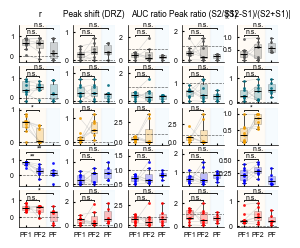

DRZ stability outputs:
  Per-cell CSV: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/pf_drz_stability_per_cell.csv
  Stats CSV: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/pf_drz_stability_stats.csv
  combined: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/pf_drz_stability_combined.svg
Generated figure: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/pf_drz_abs_norm_fr_change_ss_cs.svg
Stats CSV: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/pf_drz_abs_norm_fr_change_ss_cs_stats.csv
n (SS PF1 vs CS PF1): 9
n (SS PF2 vs CS PF2): 7
n (SS PF1 vs SS PF2): 7
n (CS PF1 vs CS PF2): 7
n (ratio SS PF1 vs CS PF1): 9
n (ratio SS PF2 vs CS PF2): 7
n (ratio SS PF1 vs SS PF2): 7
n (ratio CS PF1 vs CS

In [438]:
if drz_dataset is None:
    print("drz_dataset is None. DRZ dataset build failed.")
else:
    drz_average_export_dir_2sessions = os.path.join(figure_save_folder, drz_average_export_subdir_2sessions)
    drz_stability_results = compute_pf_drz_session_stability(
        drz_dataset,
        min_traversals_per_session=0,
        smooth_window_cm=0.0,
        auc_window_cm=None,
        slow_auc_window_cm=(-0.5, 0.5),
        min_trials_per_column_2sessions=drz_min_trials_per_column_2sessions,
        average_export_dir=drz_average_export_dir_2sessions,
        split_mode=drz_two_session_split_mode,
        split_window_minutes=drz_two_session_split_window_minutes,
        strict_follow_plot_inclusion=True,
        print_nan_diagnostics=True,
        set_nan_r_to_zero=True,
    )
    print(f"Skipped counts: {drz_stability_results.get('skipped_counts', {})}")
    per_cell_stability = drz_stability_results.get('per_cell_stability', None)
    if per_cell_stability is not None:
        print(f'Per-cell stability rows: {len(per_cell_stability)}')
        display(per_cell_stability.head())

    drz_stability_plot_summary = plot_pf_drz_session_stability(
        drz_stability_results,
        figure_save_folder=figure_save_folder,
        figsize=(2.7, 2.3),
        row_height=1.2,
        show_plot=True,
        save_csv=True,
    )
    print('DRZ stability outputs:')
    print(f"  Per-cell CSV: {drz_stability_plot_summary.get('per_cell_csv')}")
    print(f"  Stats CSV: {drz_stability_plot_summary.get('stats_csv')}")
    for metric_name, fig_path in drz_stability_plot_summary.get('figure_paths', {}).items():
        print(f"  {metric_name}: {fig_path}")

    drz_ss_cs_peak_change_summary = plot_pf_drz_abs_norm_fr_change_ss_cs(
        drz_stability_results,
        figure_save_folder=figure_save_folder,
        out_name='pf_drz_abs_norm_fr_change_ss_cs.svg',
        figsize=(0.9, 2.0),
        show_plot=False,
        save_csv=True,
    )
    print('Generated figure:', drz_ss_cs_peak_change_summary.get('figure'))
    print('Stats CSV:', drz_ss_cs_peak_change_summary.get('stats_csv'))
    print('n (SS PF1 vs CS PF1):', drz_ss_cs_peak_change_summary.get('n_ss_pf1_vs_cs_pf1'))
    print('n (SS PF2 vs CS PF2):', drz_ss_cs_peak_change_summary.get('n_ss_pf2_vs_cs_pf2'))
    print('n (SS PF1 vs SS PF2):', drz_ss_cs_peak_change_summary.get('n_ss_pf1_vs_ss_pf2'))
    print('n (CS PF1 vs CS PF2):', drz_ss_cs_peak_change_summary.get('n_cs_pf1_vs_cs_pf2'))
    print('n (ratio SS PF1 vs CS PF1):', drz_ss_cs_peak_change_summary.get('n_ratio_ss_pf1_vs_cs_pf1'))
    print('n (ratio SS PF2 vs CS PF2):', drz_ss_cs_peak_change_summary.get('n_ratio_ss_pf2_vs_cs_pf2'))
    print('n (ratio SS PF1 vs SS PF2):', drz_ss_cs_peak_change_summary.get('n_ratio_ss_pf1_vs_ss_pf2'))
    print('n (ratio CS PF1 vs CS PF2):', drz_ss_cs_peak_change_summary.get('n_ratio_cs_pf1_vs_cs_pf2'))


## Compare directions

In [439]:
drz_direction_avg_mode = 'S1'
drz_direction_average_export_subdir = 'pf_drz_2directions_average_exports'


### Heatmaps comparing CW and CCW

In [440]:
if drz_dataset is None:
    print("drz_dataset is None. DRZ dataset build failed.")
else:
    drz_heatmap_summary_2directions = generate_pf_drz_component_heatmaps_2directions(
        dataset=drz_dataset,
        figure_save_folder=figure_save_folder,
        clear_output=True,
        smooth_window=drz_smooth_window,
        fr_vmax_scale=0.2,
        theta_vlim=(0, 0.4),
        slow_vlim=(-0.4, 0.4),
        fig_width=3,
        trial_height=0.01,
        xlim=drz_display_xlim,
        merge_ss_cs=True,
        merge_plateau=True,
        smooth_plateau=False,
        plateau_vlim=0.01,
        avg_smooth_window=drz_avg_smooth_window,
        avg_mode=drz_direction_avg_mode,
        average_export_subdir=drz_direction_average_export_subdir,
        show_plot=False,
    )
    for cat, info in drz_heatmap_summary_2directions.items():
        print(f'{cat} summary (2 directions): {info}')


/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/utils/placecell_pipeline.py:8555: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  except Exception:


[CSplus] 1/12 saved: file:///Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/pf_drz_2directions_CSplus_heatmaps/CKII_pAce21_PR_20250806_Cell3_heatmap_2directions.svg


/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/utils/placecell_pipeline.py:8449: RuntimeWarning: Mean of empty slice
  n_valid = np.sum(~np.isnan(stack), axis=0)
/opt/homebrew/Caskroom/miniforge/base/envs/AdamLab/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/utils/placecell_pipeline.py:8379: RuntimeWarning: Mean of empty slice
  ss_n = np.sum(~np.isnan(ss_stack), axis=0)
/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/utils/placecell_pipeline.py:8388: RuntimeWarning: Mean of empty slice
  cs_n = np.sum(~np.isnan(cs_stack), axis=0)


[CSplus] 2/12 saved: file:///Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/pf_drz_2directions_CSplus_heatmaps/CKII_pAce38_PX_20251126_Cell1_heatmap_2directions.svg
[CSplus] 3/12 saved: file:///Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/pf_drz_2directions_CSplus_heatmaps/CKII_pAce38_PX_20251126_Cell4_heatmap_2directions.svg
[CSplus] 4/12 saved: file:///Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/pf_drz_2directions_CSplus_heatmaps/CKII_pAce38_PX_20251126_Cell6_heatmap_2directions.svg
[CSplus] 5/12 saved: file:///Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/pf_drz_2directions_CSplus_heatmaps/CKII_pAce38_PX_20251126_Cell7_heatmap_2directions.svg
[CSplus] 6/12 saved: file:///Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_a

/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/utils/placecell_pipeline.py:21879: RuntimeWarning: Mean of empty slice
  sem = _smooth_trace_for_export(np.asarray(np.nanstd(sub, axis=0) / np.sqrt(np.maximum(np.sum(np.isfinite(sub), axis=0), 1)), dtype=float))


CSplus summary (2 directions): {'output_dir': '/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/pf_drz_2directions_CSplus_heatmaps', 'output_dir_uri': 'file:///Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/pf_drz_2directions_CSplus_heatmaps', 'n_primary_entries': 12, 'n_secondary_entries': 7, 'n_union_entries': 12, 'n_pf2_only_entries': 0, 'n_saved_files': 12, 'n_dual_pf_files': 7, 'mode': 'direction_heatmap_with_avg_mode', 'avg_mode': 's1', 'average_export_dir': '/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/pf_drz_2directions_average_exports/CSplus', 'average_export_dir_uri': 'file:///Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/pf_drz_2directions_average_exports/CSplus', 'average_export_index_csv': '/Users/qixinyang/Documents/AdamLab/miniVI_Renana

### Grand Average, comparing directions

In [441]:
if drz_dataset is None:
    print("drz_dataset is None. DRZ dataset build failed.")
else:
    drz_direction_average_export_dir = os.path.join(figure_save_folder, drz_direction_average_export_subdir)
    for cat, title, filename in [
        ('CSplus', 'CS+ PLCs', 'pf_drz_CSplus_average_primary_secondary_2directions.svg'),
        ('CSminus', 'CS- PLCs', 'pf_drz_CSminus_average_primary_secondary_2directions.svg'),
    ]:
        out_path = os.path.join(figure_save_folder, filename)
        plot_pf_drz_category_primary_secondary_from_dataset_2directions(
            dataset=drz_dataset,
            category=cat,
            title=title,
            out_path=out_path,
            smooth_window=drz_smooth_window,
            avg_smooth_window=drz_avg_smooth_window,
            plot_trials=True,
            trial_alpha=0.2,
            trial_linewidth=0.5,
            theta_ylim=(0, 0.2),
            slow_ylim=(-0.05, 0.2),
            fr_ylim_scale=1.2,
            ss_cs_ylim_scale=1.2,
            figsize_per_block=(3.4, 2.4),
            xlim=drz_display_xlim,
            fr_row_ylim_max=1.5,
            ss_cs_row_ylim_max=1.1,
            min_traversals_per_type=drz_params.min_traversals_per_type,
            use_saved_average_exports=True,
            average_export_dir=drz_direction_average_export_dir,
            avg_mode=drz_direction_avg_mode,
            enforce_min_traversals_on_saved_exports=False,
            show_plot=True,
        )
        print(f'Generated: {out_path}')


/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/utils/placecell_pipeline.py:21058: RuntimeWarning: Mean of empty slice
  dir_data["cs_pct_mean"] = np.nanmean(cs_pct, axis=0) if cs_pct.size > 0 else np.full(n_time, np.nan, dtype=float)
/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/utils/placecell_pipeline.py:21059: RuntimeWarning: Mean of empty slice
  data_out[direction] = dir_data


PF1 counts: All (n=12), Pref (n=12), Non-pref (n=12)
PF2 counts: All (n=12), Pref (n=7), Non-pref (n=7)


/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/utils/placecell_pipeline.py:8972: RuntimeWarning: Mean of empty slice
  elif arr.ndim == 1:


Generated: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/pf_drz_CSplus_average_primary_secondary_2directions.svg
PF1 counts: All (n=8), Pref (n=8), Non-pref (n=8)
PF2 counts: All (n=8), Pref (n=3), Non-pref (n=3)
Generated: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/pf_drz_CSminus_average_primary_secondary_2directions.svg


### Statistics, Pref vs Non-pref

[pref_nonpref_stability] Cells/metrics with NaN values (flat/invalid traces):
  group=CSplus_PF2, metric=cs, cell=CKII_pAce38_PX_20251126_Cell4, n_pref=10, n_nonpref=5, overlap_bins=18, auc_bins=18, peak_bins=11, reasons=r:flat_trace_nonpreferred; r_set_to_zero
  group=CSminus_PF1, metric=cs, cell=CKII_pAce38_PX_20251126_Cell5, n_pref=8, n_nonpref=9, overlap_bins=21, auc_bins=21, peak_bins=11, reasons=r:flat_trace_both_directions; r_set_to_zero; auc_ratio:zero_or_invalid_auc_preferred; peak_ratio:zero_or_invalid_peak_preferred; peak_abs_sym_diff:zero_or_invalid_peak_sum
  group=CSminus_PF1, metric=cs, cell=CKII_pAce38_PX_20251126_Cell9, n_pref=7, n_nonpref=9, overlap_bins=19, auc_bins=19, peak_bins=11, reasons=r:flat_trace_both_directions; r_set_to_zero; auc_ratio:zero_or_invalid_auc_preferred; peak_ratio:zero_or_invalid_peak_preferred; peak_abs_sym_diff:zero_or_invalid_peak_sum
  group=CSminus_PF1, metric=cs, cell=CKII_pAce45_PX_20260118_Cell3, n_pref=10, n_nonpref=11, overlap_bins=21

,group,category,pf_rank,animal_id,cell_idx,cell_num,metric,direction_pref,direction_nonpref,avg_mode,...,n_trials_pref,n_trials_nonpref,r,delta_peak_x_cm,auc_ratio,peak_pref,peak_nonpref,peak_ratio_s2_s1,peak_ratio_nonpref_pref,peak_abs_sym_diff
0,CSplus_PF1,CSplus,1,CKII_pAce38_PX_20251126,0,1,all_spike,cw,ccw,s1,...,8,6,0.843862,-0.5,0.750045,10.145636,7.915996,0.780237,0.780237,0.123446
1,CSplus_PF1,CSplus,1,CKII_pAce38_PX_20251126,0,1,ss,cw,ccw,s1,...,8,6,0.879830,0.0,0.716234,6.783434,5.644857,0.832153,0.832153,0.091612
2,CSplus_PF1,CSplus,1,CKII_pAce38_PX_20251126,0,1,cs,cw,ccw,s1,...,8,6,0.435314,-0.7,0.821189,4.619340,3.312306,0.717052,0.717052,0.164787
3,CSplus_PF1,CSplus,1,CKII_pAce38_PX_20251126,0,1,theta,cw,ccw,s1,...,8,6,0.767156,0.0,0.863041,0.213819,0.198857,0.930027,0.930027,0.036255
4,CSplus_PF1,CSplus,1,CKII_pAce38_PX_20251126,0,1,slow,cw,ccw,s1,...,8,6,0.228338,1.1,0.596827,0.086120,0.069389,0.805716,0.805716,0.107594


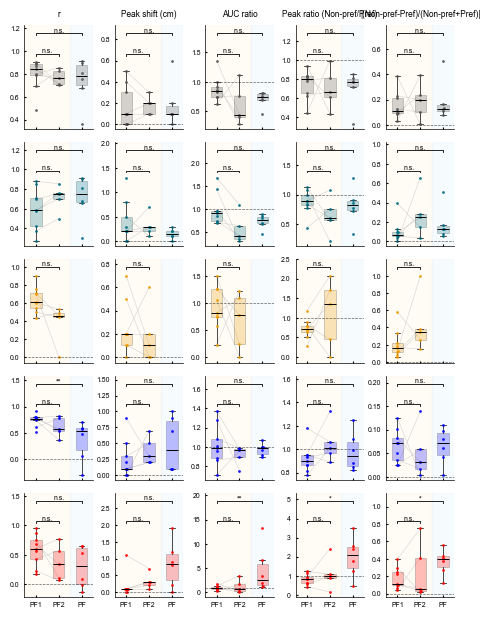

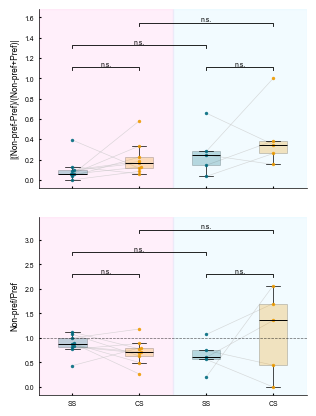

DRZ directionality outputs:
  figure: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/pf_drz_pref_nonpref_summary_5panels.svg
  per_cell_csv: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/pf_drz_pref_nonpref_per_cell.csv
  stats_csv: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/pf_drz_pref_nonpref_stats.csv
  figure_2subplots: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/pf_drz_pref_nonpref_summary_ss_cs_2subplots.svg
  stats_csv_2subplots: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/pf_drz_abs_norm_fr_change_ss_cs_stats.csv


In [442]:
if drz_dataset is None:
    print("drz_dataset is None. DRZ dataset build failed.")
else:
    drz_direction_average_export_dir = os.path.join(figure_save_folder, drz_direction_average_export_subdir)
    drz_directionality_results = compute_pf_drz_pref_nonpref_stats(
        drz_dataset,
        timepoint_cm=0.0,
        min_traversals_per_type=drz_params.min_traversals_per_type,
        smooth_window_cm=0.0,
        auc_window_cm=None,
        slow_auc_window_cm=(-0.5, 0.5),
        peak_window_cm=(-0.5, 0.5),
        average_export_dir=drz_direction_average_export_dir,
        avg_mode=drz_direction_avg_mode,
    )
    print(f"Skipped counts: {drz_directionality_results.get('skipped_counts', {})}")
    per_cell_directionality = drz_directionality_results.get('per_cell_stability', None)
    if per_cell_directionality is not None:
        print(f'Per-cell directionality rows: {len(per_cell_directionality)}')
        display(per_cell_directionality.head())

    drz_directionality_plot_summary = plot_pf_drz_pref_nonpref_stats(
        drz_directionality_results,
        figure_save_folder=figure_save_folder,
        show_plot=True,
        save_csv=True,
    )
    print('DRZ directionality outputs:')
    for key, value in drz_directionality_plot_summary.items():
        print(f'  {key}: {value}')


# Directionality

In [144]:
# Directionality (bin-by-bin vector + polar), category-based
directionality_categories = ('CSplus', 'CSminus', 'non-PLC')
directionality_mode = 'head'  # 'head' or 'travel'
directionality_clear_output = True
directionality_first_n_minutes = 10.0  # set to None to use the full session

# Spatial/vector settings
directionality_width_real = 35.5
directionality_height_real = 20.0
directionality_vector_bin_size = 4.0 
directionality_hd_bin_size_deg = 15

# Movement epoch settings
directionality_speed_threshold = float(config.analysis.speed_threshold)
directionality_min_duration_s = float(config.analysis.min_duration_s)
directionality_merge_gap_s = float(config.analysis.merge_gap_s)
directionality_kernel_size = int(config.analysis.kernel_size)

# Bin-level inclusion thresholds
directionality_min_spikes_per_bin = 10
directionality_min_visited_angle_bins = 2
directionality_min_visited_angle_separation_deg = 45.0
directionality_min_occ_frames_per_angle = 100
directionality_hd_count_smooth_sigma = 0.0
directionality_min_pref_vector_strength = 0.0
directionality_preferred_angle_mode = 'peak_cluster_mean'
directionality_pref_angle_std_threshold = 0.0

# Shuffle significance settings
directionality_hd_info_null_mode = 'multinomial'  # 'timeshift' or 'multinomial'; timeshift is moving-only
directionality_hd_time_shift_min_s = 10.0
directionality_hd_time_shift_sessionwise = True

# Display settings
directionality_show_trajectory = True
directionality_use_normalized_rate = False
directionality_max_arrow_length = 'pf_peak'
directionality_max_arrow_std_factor = None
directionality_polar_smooth_sigma = 1.0
directionality_pf_bg_alpha = 0.05
directionality_tuning_curve_color = 'red'
directionality_mini_pref_arrow_length_mode = 'vector_strength'
directionality_mini_pref_arrow_length_min = 0.15
directionality_mini_pref_arrow_length_max = 0.95
directionality_occupancy_style = 'fan'
directionality_tuning_style = 'fan'
directionality_right_panel_width_mode = 'auto'
directionality_figsize_base = (6.5, 5.0)

# Travel-direction parameters (used only when directionality_mode='travel')
directionality_travel_smooth_window = 5
directionality_travel_min_step = 0.0

# Save/export controls
directionality_save_ext = 'svg'
directionality_close_figures = True
directionality_return_data = False



In [145]:
if spatial_data is None:
    print('spatial_data is None. Run the spatial classification cell first.')
else:
    directionality_batch_summary = generate_bin_by_bin_directionality_plots(
        config=config,
        spatial_data=spatial_data,
        figure_save_folder=figure_save_folder,
        categories=directionality_categories,
        first_n_minutes=directionality_first_n_minutes,
        direction_mode=directionality_mode,
        clear_output=directionality_clear_output,
        width_real=directionality_width_real,
        height_real=directionality_height_real,
        bin_size=directionality_vector_bin_size,
        kernel_size=directionality_kernel_size,
        filter_type='boxcar',
        speed_threshold=directionality_speed_threshold,
        min_duration_s=directionality_min_duration_s,
        merge_gap_s=directionality_merge_gap_s,
        min_spikes_per_bin=directionality_min_spikes_per_bin,
        min_visited_angle_bins=directionality_min_visited_angle_bins,
        min_visited_angle_separation_deg=directionality_min_visited_angle_separation_deg,
        min_occ_frames_per_angle=directionality_min_occ_frames_per_angle,
        hd_count_smooth_sigma=directionality_hd_count_smooth_sigma,
        min_pref_vector_strength=directionality_min_pref_vector_strength,
        preferred_angle_mode=directionality_preferred_angle_mode,
        pref_angle_std_threshold=directionality_pref_angle_std_threshold,
        hd_bin_size_deg=directionality_hd_bin_size_deg,
        travel_smooth_window=directionality_travel_smooth_window,
        travel_min_step=directionality_travel_min_step,
        show_trajectory=directionality_show_trajectory,
        use_normalized_rate=directionality_use_normalized_rate,
        max_arrow_length=directionality_max_arrow_length,
        max_arrow_std_factor=directionality_max_arrow_std_factor,
        polar_smooth_sigma=directionality_polar_smooth_sigma,
        pf_bg_alpha=directionality_pf_bg_alpha,
        tuning_curve_color=directionality_tuning_curve_color,
        mini_pref_arrow_length_mode=directionality_mini_pref_arrow_length_mode,
        mini_pref_arrow_length_min=directionality_mini_pref_arrow_length_min,
        mini_pref_arrow_length_max=directionality_mini_pref_arrow_length_max,
        occupancy_style=directionality_occupancy_style,
        tuning_style=directionality_tuning_style,
        hd_info_null_mode=directionality_hd_info_null_mode,
        hd_time_shift_min_s=directionality_hd_time_shift_min_s,
        hd_time_shift_sessionwise=directionality_hd_time_shift_sessionwise,
        right_panel_width_mode=directionality_right_panel_width_mode,
        figsize_base=directionality_figsize_base,
        save_ext=directionality_save_ext,
        close_figures=directionality_close_figures,
        return_data=directionality_return_data,
    )

    print(f"Directionality root output: {directionality_batch_summary.get('root_output_dir')}")
    print(f"Directionality mode: {directionality_batch_summary.get('direction_mode')}")
    print(f"Directionality null mode: {directionality_batch_summary.get('hd_info_null_mode')}")
    print(f"Directionality time-shift min (s): {directionality_batch_summary.get('hd_time_shift_min_s')}")
    print("Directionality time-shift scope: moving-only within each session")

    cat_summary = directionality_batch_summary.get('categories', {})
    for cat, info in cat_summary.items():
        print(f"\n[{cat}] output: {info.get('output_dir')}")
        print(
            f"  attempted={int(info.get('attempted', 0))}, "
            f"saved={int(info.get('saved', 0))}, "
            f"skipped={int(info.get('skipped', 0))}"
        )
        skip_reasons = info.get('skip_reasons', {}) or {}
        if len(skip_reasons) > 0:
            print(f"  skip_reasons: {skip_reasons}")

        animals = info.get('animals', {}) or {}
        for animal_id in sorted(animals.keys()):
            a = animals[animal_id]
            print(
                f"    {animal_id}: attempted={int(a.get('attempted', 0))}, "
                f"saved={int(a.get('saved', 0))}, skipped={int(a.get('skipped', 0))}"
            )
            if a.get('skip_reasons'):
                print(f"      reasons: {a.get('skip_reasons')}")
            print(f"      folder: {a.get('output_dir')}")



CKII_pAce21_PR_20250806: SNR filter kept 9/9 cells (threshold=3.0, min_good_minutes=5.0).
CKII_pAce38_PX_20251126: SNR filter kept 9/9 cells (threshold=3.0, min_good_minutes=5.0).
CKII_pAce45_PX_20260118: SNR filter kept 15/16 cells (threshold=3.0, min_good_minutes=5.0).
CKII_pAce47_PX_20260128: SNR filter kept 5/5 cells (threshold=3.0, min_good_minutes=5.0).
CKII_pAce50_PRL_20260317: SNR filter kept 9/9 cells (threshold=3.0, min_good_minutes=5.0).
CKII_pAce46_PR_20260222: SNR filter kept 9/9 cells (threshold=3.0, min_good_minutes=5.0).
Directionality root output: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/bin_by_bin_directionality_head
Directionality mode: head
Directionality null mode: multinomial
Directionality time-shift min (s): 10.0
Directionality time-shift scope: moving-only within each session

[CSplus] output: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pool

# Egocentric Tuning (Carpenter et al.)

In [447]:
directionality_categories = ('CSplus', 'CSminus') #,'all-nonPLC')
egocentric_n_jobs = max(1, (os.cpu_count() or 2) - 1)
egocentric_surrogate_chunk_size = 20
egocentric_params = EgocentricTuningParams(
    categories=tuple(directionality_categories),
    first_n_minutes=10.0,
    direction_mode='head',  # 'head' | 'travel'
    time_bin_s=0.1,
    arena_size_cm=(35.5, 20.0),
    local_spatial_bin_cm=5.0, 
    coarse_spatial_bin_cm=2.0, # used for generating SPCUs spatial firing maps 
    n_angle_bins=10,
    speed_min_cm_s=3.0,
    speed_max_cm_s=60.0,
    occupancy_threshold_s=0.2,
    min_occupied_angle_bins=3, 
    min_mean_rate_hz=0.5,
    min_valid_spatial_bins_for_fit=5,
    n_restarts=100,
    optimizer_method='Nelder-Mead',
    n_surrogates=1000,
    n_jobs=egocentric_n_jobs,
    surrogate_chunk_size=egocentric_surrogate_chunk_size,
    random_seed=42,
    clear_output=True,
    save_null_distributions=True,
)

In [448]:
# Diagnostic plots for valid spatial bins (before RH fitting)
egocentric_diagnostic_summary = generate_egocentric_valid_spatial_bin_diagnostic_plots(
    config=config,
    spatial_data=spatial_data,
    egocentric_params=egocentric_params,
    figure_save_folder=figure_save_folder,
    clear_output=True,
    dpi=180,
    save_formats=("svg",),
)

print(f"Diagnostic folder: {egocentric_diagnostic_summary['diagnostic_root']}")
print('Attempted cells by category:')
for category, n_cells in egocentric_diagnostic_summary['attempted_cells_by_category'].items():
    print(f"  {category}: {n_cells}")
print('Analyzed cells by category:')
for category, n_cells in egocentric_diagnostic_summary['analyzed_cells_by_category'].items():
    print(f"  {category}: {n_cells}")
print('Plotted cells by category:')
for category, n_cells in egocentric_diagnostic_summary['plotted_cells_by_category'].items():
    print(f"  {category}: {n_cells}")
print('Will-fit cells by category:')
for category, n_cells in egocentric_diagnostic_summary['would_fit_cells_by_category'].items():
    print(f"  {category}: {n_cells}")
print('Skipped cells by category:')
for category, n_cells in egocentric_diagnostic_summary['skipped_cells_by_category'].items():
    print(f"  {category}: {n_cells}")
print('Saved files:')
for key, out_path in egocentric_diagnostic_summary['saved_files'].items():
    print(f"  {key}: {out_path}")

diag_manifest_df = egocentric_diagnostic_summary.get('manifest_df')
if diag_manifest_df is None or len(diag_manifest_df) == 0:
    print('No diagnostic plots generated.')
else:
    display(diag_manifest_df.head(20))


Diagnostic folder: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/egocentric_tuning_carpenter/valid_spatial_bin_diagnostics
Attempted cells by category:
  CSplus: 12
  CSminus: 8
Analyzed cells by category:
  CSplus: 12
  CSminus: 8
Plotted cells by category:
  CSplus: 12
  CSminus: 8
Will-fit cells by category:
  CSplus: 12
  CSminus: 8
Skipped cells by category:
  CSplus: 0
  CSminus: 0
Saved files:
  manifest_csv: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/egocentric_tuning_carpenter/valid_spatial_bin_diagnostics/egocentric_valid_bin_diagnostic_manifest.csv
  skip_csv: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/egocentric_tuning_carpenter/valid_spatial_bin_diagnostics/egocentric_valid_bin_diagnostic_skipped.csv
  diagnostic_root: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_Plac

,category,animal_id,cell_idx,cell_num,n_valid_spatial_bins,min_valid_spatial_bins_for_fit,will_fit,saved_paths
0,CSplus,CKII_pAce21_PR_20250806,2,3,15,5,True,/Users/qixinyang/Documents/AdamLab/miniVI_Rena...
1,CSplus,CKII_pAce38_PX_20251126,0,1,19,5,True,/Users/qixinyang/Documents/AdamLab/miniVI_Rena...
2,CSplus,CKII_pAce38_PX_20251126,3,4,10,5,True,/Users/qixinyang/Documents/AdamLab/miniVI_Rena...
3,CSplus,CKII_pAce38_PX_20251126,5,6,18,5,True,/Users/qixinyang/Documents/AdamLab/miniVI_Rena...
4,CSplus,CKII_pAce38_PX_20251126,6,7,19,5,True,/Users/qixinyang/Documents/AdamLab/miniVI_Rena...
5,CSplus,CKII_pAce45_PX_20260118,4,5,23,5,True,/Users/qixinyang/Documents/AdamLab/miniVI_Rena...
6,CSplus,CKII_pAce45_PX_20260118,11,12,19,5,True,/Users/qixinyang/Documents/AdamLab/miniVI_Rena...
7,CSplus,CKII_pAce47_PX_20260128,0,1,19,5,True,/Users/qixinyang/Documents/AdamLab/miniVI_Rena...
8,CSplus,CKII_pAce47_PX_20260128,2,3,17,5,True,/Users/qixinyang/Documents/AdamLab/miniVI_Rena...
9,CSplus,CKII_pAce47_PX_20260128,3,4,17,5,True,/Users/qixinyang/Documents/AdamLab/miniVI_Rena...


In [400]:
egocentric_summary = run_pooled_egocentric_tuning_analysis(
    config=config,
    spatial_data=spatial_data,
    egocentric_params=egocentric_params,
    figure_save_folder=figure_save_folder,
)

print(f"Egocentric output folder: {egocentric_summary['figure_root']}")
print(f"Direction mode: {egocentric_summary['direction_mode']}")
print(f"Time bin (s): {egocentric_summary['time_bin_s']}")
print(f"First N minutes: {egocentric_summary['first_n_minutes']}")
print(f"Parallel jobs: {egocentric_summary['n_jobs']}")
print(f"Surrogate chunk size: {egocentric_summary['surrogate_chunk_size']}")
print('Attempted cells by category:')
for category, n_cells in egocentric_summary['attempted_cells_by_category'].items():
    print(f"  {category}: {n_cells}")
print('Successful cells by category:')
for category, n_cells in egocentric_summary['successful_cells_by_category'].items():
    print(f"  {category}: {n_cells}")
print('Skipped cells by category:')
for category, n_cells in egocentric_summary['skipped_cells_by_category'].items():
    print(f"  {category}: {n_cells}")
print('Saved files:')
for key, out_path in egocentric_summary['saved_files'].items():
    print(f"  {key}: {out_path}")

egocentric_df = egocentric_summary.get('summary_df')
if egocentric_df is None or len(egocentric_df) == 0:
    print('No successful egocentric fits.')
else:
    display(egocentric_df.head(20))



Egocentric RH fitting:   0%|          | 0/20 [00:00<?, ?cell/s]

Egocentric output folder: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/egocentric_tuning_carpenter
Direction mode: head
Time bin (s): 0.1
First N minutes: 10.0
Parallel jobs: 11
Surrogate chunk size: 20
Attempted cells by category:
  CSplus: 12
  CSminus: 8
Successful cells by category:
  CSplus: 12
  CSminus: 8
Skipped cells by category:
  CSplus: 0
  CSminus: 0
Saved files:
  summary_csv: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/egocentric_tuning_carpenter/egocentric_tuning_summary.csv
  skip_csv: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/egocentric_tuning_carpenter/egocentric_tuning_skipped.csv
  null_distribution_dir: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/egocentric_tuning_carpenter/null_distributions


,category,animal_id,cell_idx,cell_num,real_mrl,best_g,best_theta,best_x_ref,best_y_ref,best_loss,n_valid_spatial_bins,null_p95,null_p99,null_max,empirical_p,pass_95,pass_99,pass_100
0,CSplus,CKII_pAce21_PR_20250806,2,3,0.482951,-0.872809,0.390704,7.499998,12.499997,240.925055,15,0.351599,0.406034,0.470498,0.000999,True,True,True
1,CSplus,CKII_pAce38_PX_20251126,0,1,0.172814,0.359196,-1.198393,12.499998,2.499998,68.184147,19,0.191927,0.219222,0.262348,0.123876,False,False,False
2,CSplus,CKII_pAce38_PX_20251126,3,4,0.321824,0.566015,2.207284,6.480939,3.353548,61.011863,10,0.280386,0.339231,0.481034,0.021978,True,False,False
3,CSplus,CKII_pAce38_PX_20251126,5,6,0.290618,0.522019,2.187165,26.798124,6.298266,65.689626,18,0.206921,0.256415,0.312863,0.001998,True,True,False
4,CSplus,CKII_pAce38_PX_20251126,6,7,0.205919,0.434879,0.526573,23.883793,19.999783,87.762370,19,0.194188,0.216944,0.241562,0.021978,True,False,False
5,CSplus,CKII_pAce45_PX_20260118,4,5,0.202801,0.388371,-2.771637,27.499995,7.499998,174.828084,23,0.232992,0.274100,0.323400,0.140859,False,False,False
6,CSplus,CKII_pAce45_PX_20260118,11,12,0.199438,0.420367,-0.278929,22.500006,7.499999,181.225943,19,0.245359,0.286798,0.339248,0.186813,False,False,False
7,CSplus,CKII_pAce47_PX_20260128,0,1,0.450492,0.813334,2.016921,3.947646,14.581065,171.223661,19,0.203256,0.228469,0.272660,0.000999,True,True,True
8,CSplus,CKII_pAce47_PX_20260128,2,3,0.329233,0.690882,0.395636,12.584278,16.122907,165.110661,17,0.249913,0.283688,0.344865,0.001998,True,True,False
9,CSplus,CKII_pAce47_PX_20260128,3,4,0.534257,0.930890,2.908889,22.500005,7.499996,175.701668,17,0.243408,0.292539,0.348051,0.000999,True,True,True


## Plot results

In [416]:
# Ensure latest plotting dataclass/function are bound in this kernel
import importlib
import utils.placecell_pipeline as _pcp
importlib.reload(_pcp)
EgocentricSummaryPlotParams = _pcp.EgocentricSummaryPlotParams
generate_egocentric_per_cell_summary_plots = _pcp.generate_egocentric_per_cell_summary_plots

# Per-cell trajectory summary figures
plot_spikes_only_in_valid_spatial_bins = False
show_empirical_fit_curve = True
show_spatial_map_with_fitted_arrows = True

# New col5/6 split-map mode (default=True):
# True  -> place-cell-style map pipeline (moving filter + smoothing + occupancy mask)
# False -> legacy egocentric split implementation
split_maps_placecell_style = True

# Place-cell-style split-map settings (used when split_maps_placecell_style=True)
# split_map_bin_size_cm controls col5/6 preferred vs non-preferred maps only.
# Set to None to use cached place-cell bin size; set a float (e.g., 2.5 or 3.0) to override.
split_map_bin_size_cm = None
pc_bin_size_cm = 3.0 # default 1.5cm
pc_smooth_sigma = float(config.place_cell.smooth_sigma)
pc_occ_smooth_sigma = float(config.place_cell.occ_smooth_sigma)
pc_min_occupancy_s = float(config.place_cell.min_occupancy_s)
pc_use_smoothed_occ_mask = False
pc_kernel_size = int(config.analysis.kernel_size)
pc_filter_type = "boxcar"
pc_speed_threshold_cm_s = float(config.analysis.speed_threshold)
pc_min_duration_s = float(config.analysis.min_duration_s)
pc_merge_gap_s = float(config.analysis.merge_gap_s)

plot_params = EgocentricSummaryPlotParams(
    categories=tuple(egocentric_params.categories),
    first_n_minutes=egocentric_params.first_n_minutes,
    direction_mode=egocentric_params.direction_mode,
    time_bin_s=egocentric_params.time_bin_s,
    local_spatial_bin_cm=egocentric_params.local_spatial_bin_cm,
    n_angle_bins=egocentric_params.n_angle_bins,
    occupancy_threshold_s=egocentric_params.occupancy_threshold_s,
    min_occupied_angle_bins=egocentric_params.min_occupied_angle_bins,
    min_mean_rate_hz=egocentric_params.min_mean_rate_hz,
    only_plot_spikes_in_valid_spatial_bins=plot_spikes_only_in_valid_spatial_bins,
    show_empirical_fit_curve=show_empirical_fit_curve,
    show_spatial_map_with_fitted_arrows=show_spatial_map_with_fitted_arrows,
    arena_size_cm=egocentric_params.arena_size_cm,
    speed_min_cm_s=egocentric_params.speed_min_cm_s,
    speed_max_cm_s=egocentric_params.speed_max_cm_s,
    split_maps_placecell_style=split_maps_placecell_style,
    split_map_bin_size_cm=split_map_bin_size_cm,
    pc_bin_size_cm=pc_bin_size_cm,
    pc_smooth_sigma=pc_smooth_sigma,
    pc_occ_smooth_sigma=pc_occ_smooth_sigma,
    pc_min_occupancy_s=pc_min_occupancy_s,
    pc_use_smoothed_occ_mask=pc_use_smoothed_occ_mask,
    pc_kernel_size=pc_kernel_size,
    pc_filter_type=pc_filter_type,
    pc_speed_threshold_cm_s=pc_speed_threshold_cm_s,
    pc_min_duration_s=pc_min_duration_s,
    pc_merge_gap_s=pc_merge_gap_s,
    clear_output=True,
    save_formats=("svg",),
    summary_df=egocentric_df,
)

egocentric_plot_summary = generate_egocentric_per_cell_summary_plots(
    config=config,
    spatial_data=spatial_data,
    egocentric_params=egocentric_params,
    figure_save_folder=figure_save_folder,
    plot_params=plot_params,
)

print(f"Per-cell summary folder: {egocentric_plot_summary['per_cell_root']}")
print('Analyzed cells by category:')
for category, n_cells in egocentric_plot_summary['analyzed_cells_by_category'].items():
    print(f"  {category}: {n_cells}")
print('Two-panel cells by category:')
for category, n_cells in egocentric_plot_summary['two_panel_cells_by_category'].items():
    print(f"  {category}: {n_cells}")
print('One-panel cells by category:')
for category, n_cells in egocentric_plot_summary['one_panel_cells_by_category'].items():
    print(f"  {category}: {n_cells}")
print('Skipped plot cells by category:')
for category, n_cells in egocentric_plot_summary['skipped_cells_by_category'].items():
    print(f"  {category}: {n_cells}")
print('Saved files:')
for key, out_path in egocentric_plot_summary['saved_files'].items():
    print(f"  {key}: {out_path}")

plot_skip_df = egocentric_plot_summary.get('skip_df')
if plot_skip_df is not None and len(plot_skip_df) > 0:
    print('Plot skip reasons:')
    print(plot_skip_df['reason'].value_counts())

plot_manifest_df = egocentric_plot_summary.get('manifest_df')
if plot_manifest_df is None or len(plot_manifest_df) == 0:
    print('No per-cell summary plots generated.')
else:
    display(plot_manifest_df.head(20))


Per-cell summary folder: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/egocentric_tuning_carpenter/per_cell_summary
Analyzed cells by category:
  CSplus: 12
  CSminus: 8
Two-panel cells by category:
  CSplus: 12
  CSminus: 8
One-panel cells by category:
  CSplus: 0
  CSminus: 0
Skipped plot cells by category:
  CSplus: 0
  CSminus: 0
Saved files:
  per_cell_root: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/egocentric_tuning_carpenter/per_cell_summary
  manifest_csv: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/egocentric_tuning_carpenter/per_cell_summary/egocentric_per_cell_plot_manifest.csv
  skip_csv: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/egocentric_tuning_carpenter/per_cell_summary/egocentric_per_cell_plot_skipped.csv


,category,animal_id,cell_idx,cell_num,has_best_reference,n_subplots,real_mrl,pass_95,pass_99,pass_100,n_valid_frames,n_valid_spikes_before_spatial_filter,n_valid_spikes,n_valid_spatial_bins_for_plot,saved_paths
0,CSplus,CKII_pAce21_PR_20250806,2,3,True,18,0.482951,True,True,True,90432,294,294,16,/Users/qixinyang/Documents/AdamLab/miniVI_Rena...
1,CSplus,CKII_pAce38_PX_20251126,0,1,True,18,0.172814,False,False,False,123889,1106,1106,18,/Users/qixinyang/Documents/AdamLab/miniVI_Rena...
2,CSplus,CKII_pAce38_PX_20251126,3,4,True,18,0.321824,True,False,False,123889,447,447,10,/Users/qixinyang/Documents/AdamLab/miniVI_Rena...
3,CSplus,CKII_pAce38_PX_20251126,5,6,True,18,0.290618,True,True,False,123889,1036,1036,17,/Users/qixinyang/Documents/AdamLab/miniVI_Rena...
4,CSplus,CKII_pAce38_PX_20251126,6,7,True,18,0.205919,True,False,False,123889,1068,1068,18,/Users/qixinyang/Documents/AdamLab/miniVI_Rena...
5,CSplus,CKII_pAce45_PX_20260118,4,5,True,18,0.202801,False,False,False,186222,503,503,22,/Users/qixinyang/Documents/AdamLab/miniVI_Rena...
6,CSplus,CKII_pAce45_PX_20260118,11,12,True,18,0.199438,False,False,False,186222,561,561,21,/Users/qixinyang/Documents/AdamLab/miniVI_Rena...
7,CSplus,CKII_pAce47_PX_20260128,0,1,True,18,0.450492,True,True,True,138637,1294,1294,18,/Users/qixinyang/Documents/AdamLab/miniVI_Rena...
8,CSplus,CKII_pAce47_PX_20260128,2,3,True,18,0.329233,True,True,False,138637,719,719,18,/Users/qixinyang/Documents/AdamLab/miniVI_Rena...
9,CSplus,CKII_pAce47_PX_20260128,3,4,True,18,0.534257,True,True,True,138637,694,694,15,/Users/qixinyang/Documents/AdamLab/miniVI_Rena...


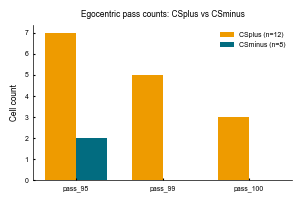

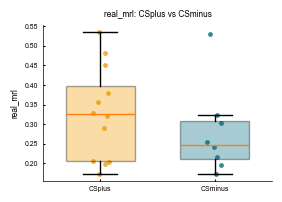

,pass_95,pass_99,pass_100,n_cells
category,,,,
CSplus,7,5,3,12
CSminus,2,0,0,8


,count,mean,median,std
category,,,,
CSplus,12,0.327185,0.325528,0.119722
CSminus,8,0.279972,0.248101,0.112959


Mann-Whitney U: U=60.000, p=0.3837
Saved files:
  pass_counts_svg: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/egocentric_tuning_carpenter/summary_stats/egocentric_pass_counts_CSplus_vs_CSminus.svg
  real_mrl_svg: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/egocentric_tuning_carpenter/summary_stats/egocentric_real_mrl_CSplus_vs_CSminus.svg


In [431]:
# Egocentric summary statistics (CS+ vs CS- PLCs)
import importlib
import numpy as np
import utils.placecell_pipeline as _pcp
importlib.reload(_pcp)
summarize_egocentric_csplus_csminus_stats = _pcp.summarize_egocentric_csplus_csminus_stats

# Style/size controls (match pooled style; tune as needed)
stats_fig_pass_size = (3.0, 2.0)
stats_fig_mrl_size = (2.8, 2.0)
stats_font_family = 'Arial'
stats_font_size = 6.0
stats_axes_labelsize = 6.0
stats_axes_titlesize = 6.0
stats_tick_labelsize = 5.0
stats_legend_fontsize = 5.0
stats_axes_linewidth = 0.5
stats_remove_top_right_spines = True
stats_csplus_color = '#EE9B00'
stats_csminus_color = '#026C80'

egocentric_stats = summarize_egocentric_csplus_csminus_stats(
    egocentric_summary,
    categories=('CSplus', 'CSminus'),
    make_plots=True,
    random_seed=42,
    save_formats=('svg',),
    fig_pass_size=stats_fig_pass_size,
    fig_mrl_size=stats_fig_mrl_size,
    font_family=stats_font_family,
    font_size=stats_font_size,
    axes_labelsize=stats_axes_labelsize,
    axes_titlesize=stats_axes_titlesize,
    tick_labelsize=stats_tick_labelsize,
    legend_fontsize=stats_legend_fontsize,
    axes_linewidth=stats_axes_linewidth,
    remove_top_right_spines=stats_remove_top_right_spines,
    category_colors={'CSplus': stats_csplus_color, 'CSminus': stats_csminus_color},
)

if not bool(egocentric_stats.get('ok', False)):
    print(f"Summary stats unavailable: {egocentric_stats.get('reason', 'unknown')}")
else:
    display(egocentric_stats['pass_counts'])
    mrl_stats_df = egocentric_stats.get('mrl_stats', None)
    if mrl_stats_df is not None and len(mrl_stats_df) > 0:
        display(mrl_stats_df)
    u = egocentric_stats.get('mannwhitney_u', np.nan)
    p = egocentric_stats.get('mannwhitney_p', np.nan)
    if np.isfinite(u) and np.isfinite(p):
        print(f"Mann-Whitney U: U={u:.3f}, p={p:.4g}")

if egocentric_stats.get('saved_files'):
    print('Saved files:')
    for key, val in egocentric_stats['saved_files'].items():
        print(f'  {key}: {val}')



# GLM

In [ ]:
glm_session_mode = "session1"  # "session1" | "combined_s1_s2"
glm_direction_predictor = "head"  # "head" | "travel" | "both"
glm_temporal_smooth_bins = 3.0  # set to 0 to disable temporal smoothing
glm_require_full_valid_bin = True  # keep only full-duration bins with no invalid frames
glm_use_regularization = True  # ridge-style regularization when reg_l1_wt = 0
glm_reg_alpha = 0.1  # ridge strength; larger values shrink coefficients more
glm_reg_l1_wt = 0.0  # 0 = pure ridge, 1 = lasso
glm_rbf_sigma_cm = 6.0  # spatial smoothness of the position basis
glm_predicted_map_min_occupancy_bins = 0.0  # hide predicted-map bins visited fewer times than this

glm_params = GLMParams(
    categories=("CSplus", "CSminus"),
    response_kinds=("all_spike", "simple_spike", "complex_spike"),
    time_bin_s=0.3,
    temporal_smooth_bins=glm_temporal_smooth_bins,
    require_full_valid_bin=glm_require_full_valid_bin,
    moving_speed_threshold=float(config.analysis.speed_threshold),
    direction_predictor=glm_direction_predictor,
    session_mode=glm_session_mode,
    min_total_spikes=20,
    standardize=True,
    include_accel=False,
    include_session_covariate=False,
    use_regularization=glm_use_regularization,
    reg_alpha=glm_reg_alpha,
    reg_l1_wt=glm_reg_l1_wt,
    rbf_sigma_cm=glm_rbf_sigma_cm,
    predicted_map_min_occupancy_bins=glm_predicted_map_min_occupancy_bins,
)

glm_summary = run_pooled_placecell_glm_analysis(
    config=config,
    spatial_data=spatial_data,
    glm_params=glm_params,
    figure_save_folder=figure_save_folder,
)

print(f"GLM output folder: {glm_summary['figure_root']}")
print(f"Session mode: {glm_summary['session_mode']}")
print(f"Direction predictor: {glm_summary['direction_predictor']}")
print(f"Temporal smoothing (bins): {glm_temporal_smooth_bins}")
print(f"Require full valid bin: {glm_require_full_valid_bin}")
print(f"Use regularization: {glm_summary['use_regularization']}")
print(f"Ridge alpha: {glm_summary['reg_alpha']}")
print(f"RBF sigma (cm): {glm_summary['rbf_sigma_cm']}")
print(f"Predicted-map min occupancy bins: {glm_summary['predicted_map_min_occupancy_bins']}")

print("Attempted cells by category:")
for category, n_cells in glm_summary["attempted_cells_by_category"].items():
    print(f"  {category}: {n_cells}")

print("Successful models by category/response:")
for category, counts in glm_summary["successful_models_by_category_response"].items():
    print(f"  {category}:")
    for response_kind, count in counts.items():
        print(f"    {response_kind}: {count}")

print("Skipped models by category/response:")
for category, counts in glm_summary["skipped_models_by_category_response"].items():
    print(f"  {category}:")
    for response_kind, count in counts.items():
        print(f"    {response_kind}: {count}")

print("Saved files:")
for key, out_path in glm_summary["saved_files"].items():
    print(f"  {key}: {out_path}")

for category in ("CSplus", "CSminus"):
    cat_df = glm_summary["group_summary_by_category"].get(category)
    print(f"\n{category} group summary:")
    if cat_df is None or len(cat_df) == 0:
        print("  No fitted models.")
    else:
        display(cat_df.head(20))


GLM output folder: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/figures/CKII_pooled/GLM_placecells/combined_s1_s2
Session mode: combined_s1_s2
Direction predictor: head
Temporal smoothing (bins): 3.0
Require full valid bin: True
Use regularization: True
Ridge alpha: 0.1
RBF sigma (cm): 6.0
Predicted-map min occupancy bins: 0.0
Attempted cells by category:
  CSplus: 10
  CSminus: 6
Successful models by category/response:
  CSplus:
    all_spike: 10
    simple_spike: 10
    complex_spike: 10
  CSminus:
    all_spike: 6
    simple_spike: 6
    complex_spike: 1
Skipped models by category/response:
  CSplus:
    all_spike: 0
    simple_spike: 0
    complex_spike: 0
  CSminus:
    all_spike: 0
    simple_spike: 0
    complex_spike: 5
Saved files:
  model_summary_csv: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4_2sessions/figures/CKII_pooled/GLM_placecells/combined_s1_s2/glm_placecells_model_summary.

,category,animal_id,cell_idx,cell_num,response_kind,session_mode,direction_predictor,selected_session_indices,n_valid_bins,n_spikes_total,...,head_beta_sin,head_beta_cos,head_beta_magnitude,head_beta_angle_deg,travel_beta_sin,travel_beta_cos,travel_beta_magnitude,travel_beta_angle_deg,position_coef_l2,position_coef_mean_abs
0,CSplus,CKII_pAce21_PR_20250806,2,3,all_spike,combined_s1_s2,head,0,292,156,...,-0.344896,0.459447,0.574496,323.105326,NaN,NaN,NaN,NaN,0.736936,0.119955
1,CSplus,CKII_pAce21_PR_20250806,2,3,simple_spike,combined_s1_s2,head,0,292,35,...,-0.053067,0.198362,0.205338,345.022692,NaN,NaN,NaN,NaN,0.371551,0.058747
2,CSplus,CKII_pAce21_PR_20250806,2,3,complex_spike,combined_s1_s2,head,0,292,121,...,-0.403697,0.442964,0.599323,317.655382,NaN,NaN,NaN,NaN,0.702749,0.112982
3,CSplus,CKII_pAce38_PX_20251126,0,1,all_spike,combined_s1_s2,head,"0,1",1109,1139,...,0.112083,-0.054382,0.124580,115.882465,NaN,NaN,NaN,NaN,0.516173,0.077373
4,CSplus,CKII_pAce38_PX_20251126,0,1,simple_spike,combined_s1_s2,head,"0,1",1109,783,...,0.095594,-0.132538,0.163415,144.198617,NaN,NaN,NaN,NaN,0.415763,0.062540
5,CSplus,CKII_pAce38_PX_20251126,0,1,complex_spike,combined_s1_s2,head,"0,1",1109,356,...,0.085607,0.097919,0.130064,41.162173,NaN,NaN,NaN,NaN,0.394706,0.060423
6,CSplus,CKII_pAce38_PX_20251126,3,4,all_spike,combined_s1_s2,head,"0,1",1109,486,...,0.100777,-0.032398,0.105856,107.821868,NaN,NaN,NaN,NaN,0.593615,0.097454
7,CSplus,CKII_pAce38_PX_20251126,3,4,simple_spike,combined_s1_s2,head,"0,1",1109,321,...,0.066544,0.077279,0.101981,40.731538,NaN,NaN,NaN,NaN,0.451374,0.074706
8,CSplus,CKII_pAce38_PX_20251126,3,4,complex_spike,combined_s1_s2,head,"0,1",1109,165,...,0.066652,-0.158604,0.172040,157.205779,NaN,NaN,NaN,NaN,0.427681,0.063703
9,CSplus,CKII_pAce38_PX_20251126,5,6,all_spike,combined_s1_s2,head,"0,1",1109,931,...,0.310458,-0.262334,0.406452,130.197416,NaN,NaN,NaN,NaN,0.452041,0.071231



CSminus group summary:


,category,animal_id,cell_idx,cell_num,response_kind,session_mode,direction_predictor,selected_session_indices,n_valid_bins,n_spikes_total,...,head_beta_sin,head_beta_cos,head_beta_magnitude,head_beta_angle_deg,travel_beta_sin,travel_beta_cos,travel_beta_magnitude,travel_beta_angle_deg,position_coef_l2,position_coef_mean_abs
30,CSminus,CKII_pAce21_PR_20250806,0,1,all_spike,combined_s1_s2,head,0,292,103,...,-0.048343,-0.063365,0.079701,217.341269,NaN,NaN,NaN,NaN,0.520995,0.068321
31,CSminus,CKII_pAce21_PR_20250806,0,1,simple_spike,combined_s1_s2,head,0,292,100,...,-0.063269,-0.037550,0.073573,239.310949,NaN,NaN,NaN,NaN,0.510398,0.064699
32,CSminus,CKII_pAce21_PR_20250806,4,5,all_spike,combined_s1_s2,head,0,292,56,...,-0.158798,-0.072036,0.174373,245.599272,NaN,NaN,NaN,NaN,0.306980,0.045418
33,CSminus,CKII_pAce21_PR_20250806,4,5,simple_spike,combined_s1_s2,head,0,292,48,...,-0.093183,-0.029174,0.097643,252.615506,NaN,NaN,NaN,NaN,0.305162,0.046512
34,CSminus,CKII_pAce38_PX_20251126,4,5,all_spike,combined_s1_s2,head,"0,1",1109,147,...,0.055850,0.132484,0.143775,22.858154,NaN,NaN,NaN,NaN,0.239700,0.036129
35,CSminus,CKII_pAce38_PX_20251126,4,5,simple_spike,combined_s1_s2,head,"0,1",1109,147,...,0.055850,0.132484,0.143775,22.858154,NaN,NaN,NaN,NaN,0.239700,0.036129
36,CSminus,CKII_pAce38_PX_20251126,8,9,all_spike,combined_s1_s2,head,"0,1",1109,158,...,0.125701,-0.085325,0.151924,124.168288,NaN,NaN,NaN,NaN,0.267820,0.038112
37,CSminus,CKII_pAce38_PX_20251126,8,9,simple_spike,combined_s1_s2,head,"0,1",1109,154,...,0.145122,-0.080633,0.166018,119.057595,NaN,NaN,NaN,NaN,0.259165,0.036481
38,CSminus,CKII_pAce45_PX_20260118,0,1,all_spike,combined_s1_s2,head,"0,1",1073,412,...,0.024047,0.044508,0.050588,28.381474,NaN,NaN,NaN,NaN,0.438684,0.070832
39,CSminus,CKII_pAce45_PX_20260118,0,1,simple_spike,combined_s1_s2,head,"0,1",1073,381,...,0.025698,0.039444,0.047077,33.084161,NaN,NaN,NaN,NaN,0.421759,0.068010


# LN model

In [146]:
# Hardcastle-style LN model (P/H/S only; theta omitted for this dataset)
ln_session_mode = "session1"  # "session1" | "combined_s1_s2"
ln_direction_predictor = "head"  # "head" | "travel"
ln_time_bin_s = 0.4
ln_moving_only = False
ln_require_full_valid_bin = True
ln_position_n_bins = (18, 10)
ln_min_position_bin_occupancy_s = ln_time_bin_s   # only keep LN time bins whose position bin was occupied for at least this long
ln_n_direction_bins = 12
ln_n_speed_bins = 10
ln_max_speed_cm_s = 30.0
ln_roughness_position = 8.0
ln_roughness_direction = 50.0
ln_roughness_speed = 50.0
ln_cv_num_folds = 10
ln_cv_section_repeats = 3
ln_selection_alpha = 0.05
ln_baseline_alpha = 0.2  # relax this to reduce the "None" group
ln_smoothing_sigma_bins = 1.0 #1D Gaussian kernel over time bins.
ln_smoothing_radius_bins = 3 # half-width of the temporal Gaussian kernel.
ln_position_smooth_sigma = 1 #2D spatial Gaussian smoothing sigma applied only to the empirical position tuning map.
ln_min_total_spikes = 20
ln_optimizer_maxiter = 400
ln_travel_smooth_window = 5
ln_travel_min_step = 0.0

ln_params = LNModelParams(
    categories=("CSplus", "CSminus"),
    response_kinds=("all_spike", "simple_spike", "complex_spike"),
    session_mode=ln_session_mode,
    time_bin_s=ln_time_bin_s,
    moving_only=ln_moving_only,
    require_full_valid_bin=ln_require_full_valid_bin,
    moving_speed_threshold=float(config.analysis.speed_threshold),
    direction_predictor=ln_direction_predictor,
    min_total_spikes=ln_min_total_spikes,
    position_n_bins=ln_position_n_bins,
    min_position_bin_occupancy_s=ln_min_position_bin_occupancy_s,
    n_direction_bins=ln_n_direction_bins,
    n_speed_bins=ln_n_speed_bins,
    max_speed_cm_s=ln_max_speed_cm_s,
    roughness_position=ln_roughness_position,
    roughness_direction=ln_roughness_direction,
    roughness_speed=ln_roughness_speed,
    cv_num_folds=ln_cv_num_folds,
    cv_section_repeats=ln_cv_section_repeats,
    selection_alpha=ln_selection_alpha,
    baseline_alpha=ln_baseline_alpha,
    smoothing_sigma_bins=ln_smoothing_sigma_bins,
    smoothing_radius_bins=ln_smoothing_radius_bins,
    position_smooth_sigma=ln_position_smooth_sigma,
    travel_smooth_window=ln_travel_smooth_window,
    travel_min_step=ln_travel_min_step,
    optimizer_maxiter=ln_optimizer_maxiter,
)


In [147]:
ln_summary = run_pooled_placecell_ln_model_analysis(
    config=config,
    spatial_data=spatial_data,
    ln_params=ln_params,
    figure_save_folder=figure_save_folder,
)

print(f"LN output folder: {ln_summary['figure_root']}")
print(f"Session mode: {ln_summary['session_mode']}")
print(f"Direction predictor: {ln_summary['direction_predictor']}")
print(f"Time bin (s): {ln_time_bin_s}")
print(f"Moving only: {ln_moving_only}")
print(f"Require full valid bin: {ln_require_full_valid_bin}")
print(f"CV folds: {ln_cv_num_folds}")
print(f"CV section repeats: {ln_cv_section_repeats}")
print(f"Min position-bin occupancy (s): {ln_summary['min_position_bin_occupancy_s']}")
print(f"Forward alpha: {ln_summary['forward_alpha']}")
print(f"Baseline alpha: {ln_summary['baseline_alpha']}")

print("Attempted cells by category:")
for category, n_cells in ln_summary['attempted_cells_by_category'].items():
    print(f"  {category}: {n_cells}")

print("Successful models by category/response:")
for category, counts in ln_summary['successful_models_by_category_response'].items():
    print(f"  {category}:")
    for response_kind, count in counts.items():
        print(f"    {response_kind}: {count}")

print("Skipped models by category/response:")
for category, counts in ln_summary['skipped_models_by_category_response'].items():
    print(f"  {category}:")
    for response_kind, count in counts.items():
        print(f"    {response_kind}: {count}")

print("Saved files:")
for key, out_path in ln_summary['saved_files'].items():
    print(f"  {key}: {out_path}")

for category in ("CSplus", "CSminus"):
    cat_df = ln_summary['summary_by_category'].get(category)
    print(f"\n{category} LN summary:")
    if cat_df is None or len(cat_df) == 0:
        print("  No fitted models.")
    else:
        display(cat_df.head(20))


LN output folder: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/LN_placecells/session1
Session mode: session1
Direction predictor: head
Time bin (s): 0.4
Moving only: False
Require full valid bin: True
CV folds: 10
CV section repeats: 3
Min position-bin occupancy (s): 0.4
Forward alpha: 0.05
Baseline alpha: 0.2
Attempted cells by category:
  CSplus: 12
  CSminus: 8
Successful models by category/response:
  CSplus:
    all_spike: 12
    simple_spike: 12
    complex_spike: 12
  CSminus:
    all_spike: 8
    simple_spike: 8
    complex_spike: 6
Skipped models by category/response:
  CSplus:
    all_spike: 0
    simple_spike: 0
    complex_spike: 0
  CSminus:
    all_spike: 0
    simple_spike: 0
    complex_spike: 2
Saved files:
  model_summary_csv: /Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/miniVI_PlaceCell_analysis_V4/figures/CKII_pooled/LN_placecells/session1/ln_placecells_model_summary.csv
  model_performance_c

,category,animal_id,cell_idx,cell_num,response_kind,session_mode,direction_predictor,selected_session_indices,selected_model,best_single_model,...,n_spikes_total,dt_s,position_occupancy_filter_applied,n_bins_before_position_occupancy_filter,n_bins_after_position_occupancy_filter,n_position_bins_kept,n_position_bins_total,full_model_mean_test_llh_bits_spike,full_model_mean_test_var_explained,full_model_mean_test_correlation
0,CSplus,CKII_pAce21_PR_20250806,2,3,all_spike,session1,head,0,PS,P,...,1785,0.4,True,1481,1481,160,180,0.128791,0.075869,0.375860
1,CSplus,CKII_pAce21_PR_20250806,2,3,simple_spike,session1,head,0,None,H,...,175,0.4,True,1481,1481,160,180,-0.124062,-0.019726,0.094785
2,CSplus,CKII_pAce21_PR_20250806,2,3,complex_spike,session1,head,0,S,S,...,1610,0.4,True,1481,1481,160,180,0.107206,0.027102,0.333673
3,CSplus,CKII_pAce38_PX_20251126,0,1,all_spike,session1,head,0,P,P,...,1737,0.4,True,1249,1249,135,180,0.240814,0.283714,0.546211
4,CSplus,CKII_pAce38_PX_20251126,0,1,simple_spike,session1,head,0,P,P,...,1179,0.4,True,1249,1249,135,180,0.217695,0.247268,0.498179
5,CSplus,CKII_pAce38_PX_20251126,0,1,complex_spike,session1,head,0,None,P,...,558,0.4,True,1249,1249,135,180,0.065338,-0.029638,0.290301
6,CSplus,CKII_pAce38_PX_20251126,3,4,all_spike,session1,head,0,P,P,...,1221,0.4,True,1249,1249,135,180,0.437710,0.377156,0.676372
7,CSplus,CKII_pAce38_PX_20251126,3,4,simple_spike,session1,head,0,P,P,...,620,0.4,True,1249,1249,135,180,0.248840,0.158951,0.530122
8,CSplus,CKII_pAce38_PX_20251126,3,4,complex_spike,session1,head,0,PS,P,...,601,0.4,True,1249,1249,135,180,0.482601,0.079613,0.501698
9,CSplus,CKII_pAce38_PX_20251126,5,6,all_spike,session1,head,0,P,P,...,2185,0.4,True,1249,1249,135,180,0.170444,0.183016,0.541611



CSminus LN summary:


,category,animal_id,cell_idx,cell_num,response_kind,session_mode,direction_predictor,selected_session_indices,selected_model,best_single_model,...,n_spikes_total,dt_s,position_occupancy_filter_applied,n_bins_before_position_occupancy_filter,n_bins_after_position_occupancy_filter,n_position_bins_kept,n_position_bins_total,full_model_mean_test_llh_bits_spike,full_model_mean_test_var_explained,full_model_mean_test_correlation
36,CSminus,CKII_pAce21_PR_20250806,0,1,all_spike,session1,head,0,None,P,...,1136,0.4,True,1481,1481,160,180,0.004013,-0.053312,0.297797
37,CSminus,CKII_pAce21_PR_20250806,0,1,simple_spike,session1,head,0,P,P,...,876,0.4,True,1481,1481,160,180,0.098267,-0.039836,0.329297
38,CSminus,CKII_pAce21_PR_20250806,0,1,complex_spike,session1,head,0,None,P,...,260,0.4,True,1481,1481,160,180,-0.798020,-0.190729,0.179996
39,CSminus,CKII_pAce21_PR_20250806,4,5,all_spike,session1,head,0,None,P,...,411,0.4,True,1481,1481,160,180,-0.036076,-0.053302,0.194310
40,CSminus,CKII_pAce21_PR_20250806,4,5,simple_spike,session1,head,0,None,S,...,287,0.4,True,1481,1481,160,180,-0.016458,-0.006190,0.093136
41,CSminus,CKII_pAce21_PR_20250806,4,5,complex_spike,session1,head,0,None,P,...,124,0.4,True,1481,1481,160,180,-0.198664,-0.037288,0.231963
42,CSminus,CKII_pAce38_PX_20251126,4,5,all_spike,session1,head,0,PH,P,...,388,0.4,True,1249,1249,135,180,0.196315,0.136498,0.446650
43,CSminus,CKII_pAce38_PX_20251126,4,5,simple_spike,session1,head,0,PH,P,...,351,0.4,True,1249,1249,135,180,0.271000,0.186744,0.502335
44,CSminus,CKII_pAce38_PX_20251126,4,5,complex_spike,session1,head,0,None,P,...,37,0.4,True,1249,1249,135,180,-0.152644,-0.019678,0.154938
45,CSminus,CKII_pAce38_PX_20251126,8,9,all_spike,session1,head,0,None,P,...,269,0.4,True,1249,1249,135,180,0.081812,0.024615,0.421752
